<a href="https://colab.research.google.com/github/FatemehNMT/Modern-C-for-Robotics-and-Visual-SLAM/blob/main/Modern_C%2B%2B_for_Robotics_and_Visual_SLAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
📖 Theory (very short)

↓

🧠 Visual explanation

↓

💻 Tiny code

↓

🎯 SLAM example

↓

✍ Exercise

↓

✅ Solution

↓

⭐ Real code from our SLAM project

# **Modern C++ Foundations**

## **Pointer & Reference Cheat Sheet (C++)**

In [ ]:
int a = 5;
int* p = &a;
int** q = &p;
int& r = a;

### **1. Variables, Addresses and Values**

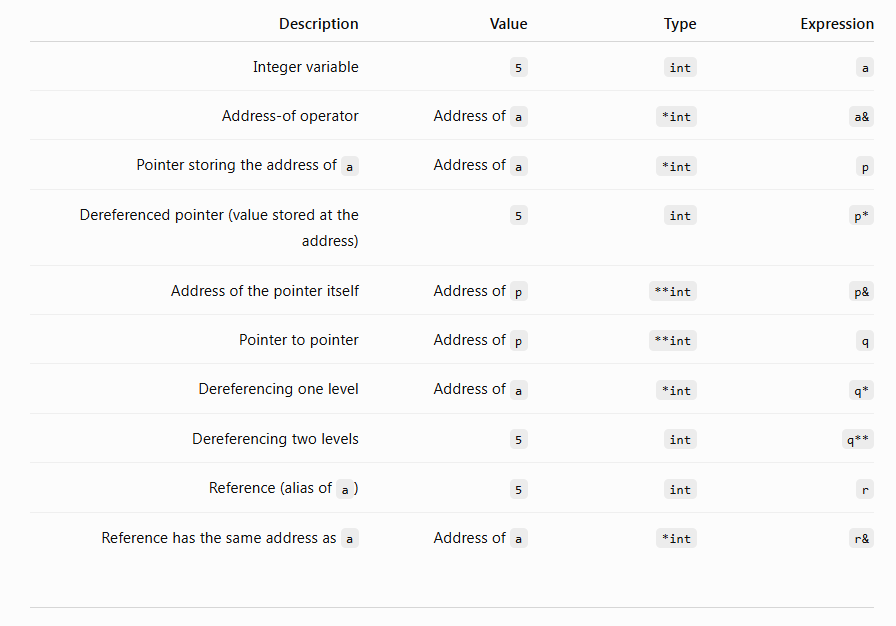

### **2. Symbols Summary**

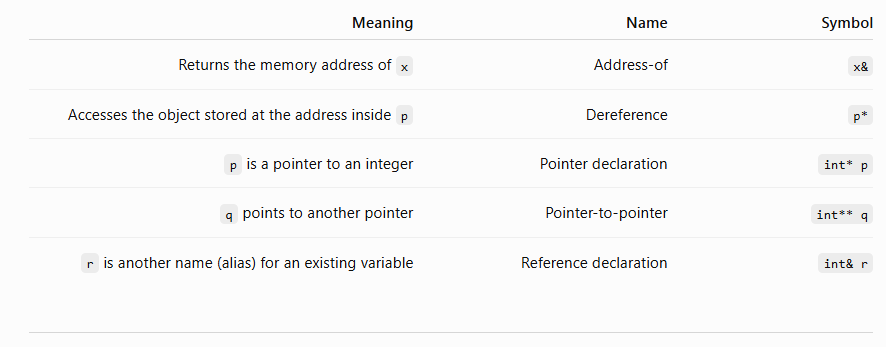

### **3. Pointer vs Reference**

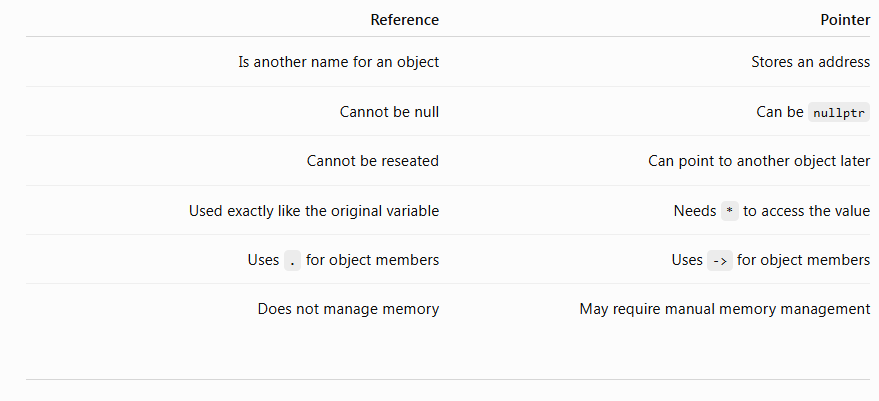

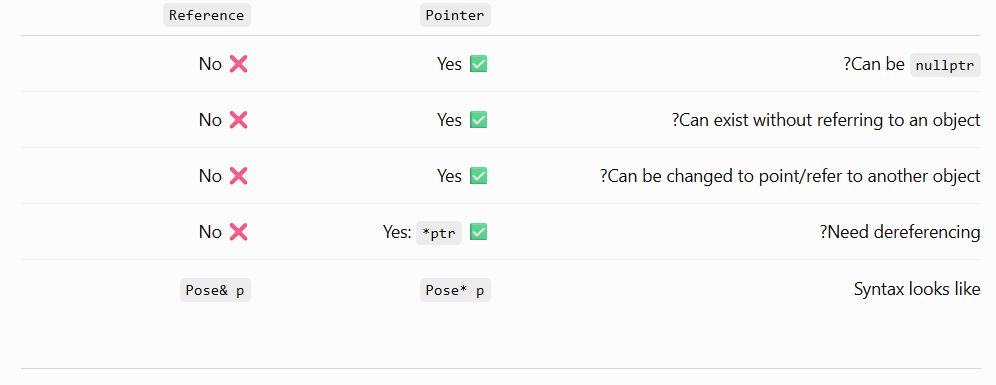

#### **1. Pointer can be nullptr ✅**
Pose* pose = nullptr;

This is completely valid.

Why?

Because a pointer is a variable that stores an address.

For example:

In [ ]:
Pose pose;
Pose* ptr = &pose;

In [ ]:
ptr
 ↓
address of pose

But a pointer can also contain no valid object address:

In [ ]:
Pose* ptr = nullptr;
# so,
ptr
 ↓
nothing

nullptr basically means:

This pointer currently does not point to an object.

#### **2. Reference cannot be nullptr ❌**

A reference must refer to an existing object when it is created.

You can think of a reference as another name for the same object.

So this is valid:

In [ ]:
Pose robot;
Pose& ref = robot;

But this is not:

In [ ]:
Pose& ref = nullptr;  // ❌

Because nullptr is not a Pose object.

A reference says:

"I am referring to a real object."

Therefore, it must have an object.

**The easiest way to remember it 🧠**

**Pointer** = Address holder 📍

The pointer stores an address.

**Reference** = Alias 🤝

A reference is like saying:

"ref is another name for robot."

Can an alternative name refer to nothing?

No.

### **4. Memory Illustration**

In [ ]:
Stack

a = 5
│
│ Address: 0x100
▼
+---------+
|    5    |
+---------+

p
│
│ Value: 0x100
▼
(Address of a)

q
│
│ Value: address of p
▼
(Address of p)

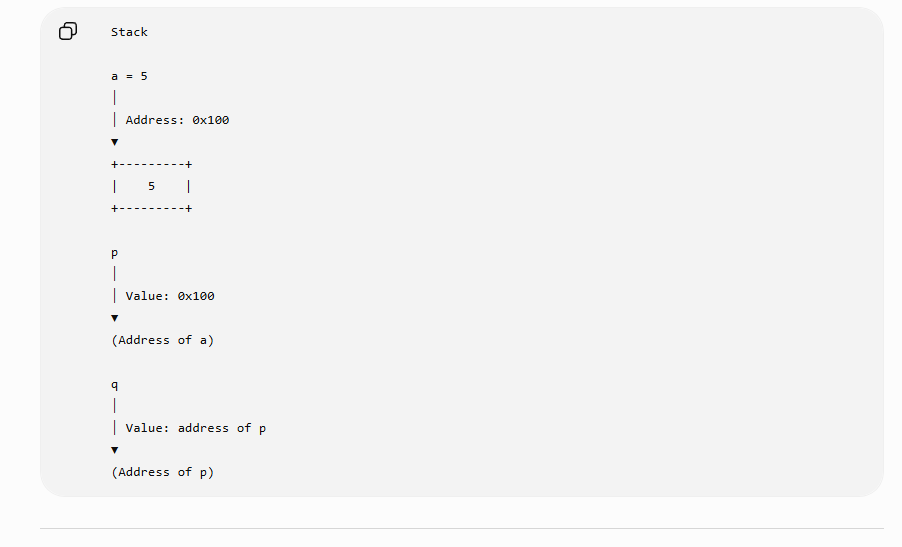

### **5. Operators**

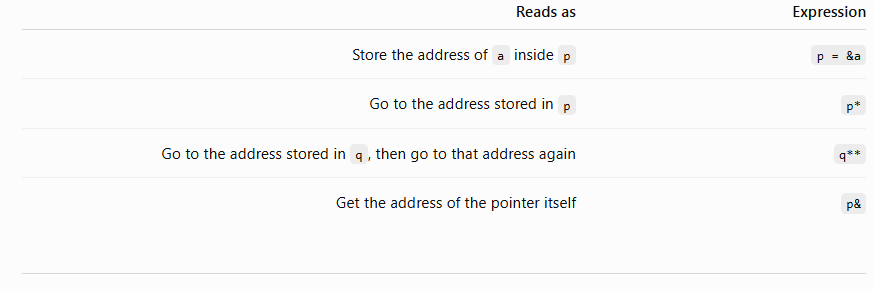

### **6. Function Arguments**

#### **Pass by Value**

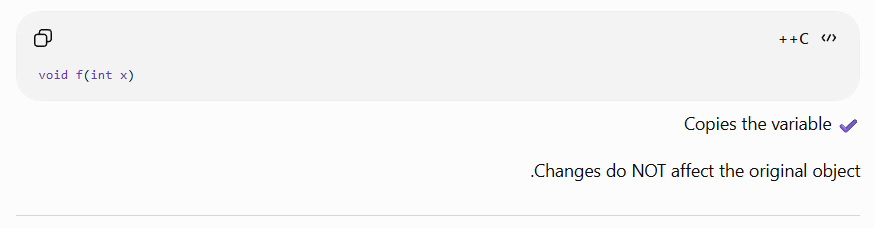

#### **Pass by Reference**

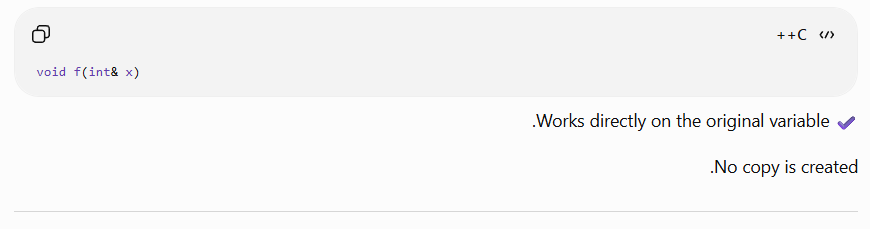

#### **Pass by Pointer**

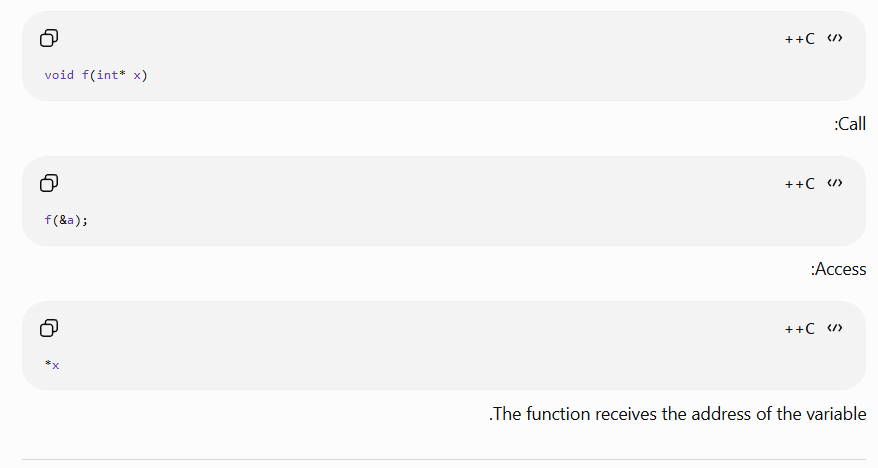

### **7. Objects**

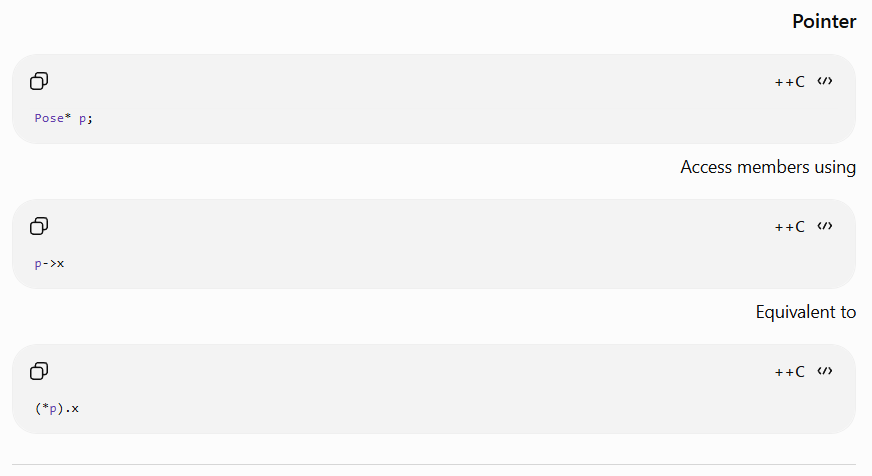

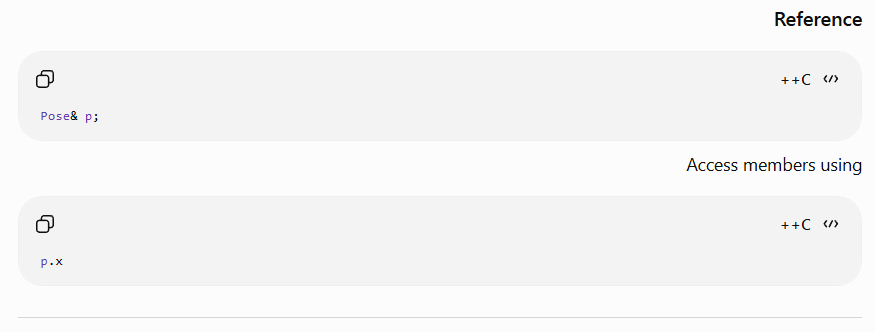

### **8. Common Mistakes**

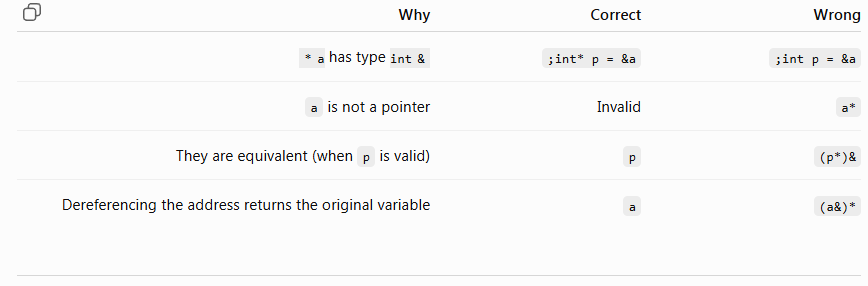

### **9. Pointer Levels**

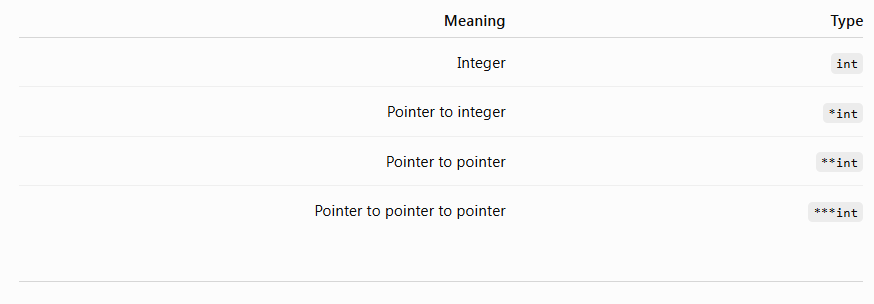

### **10. Robotics / SLAM Examples**

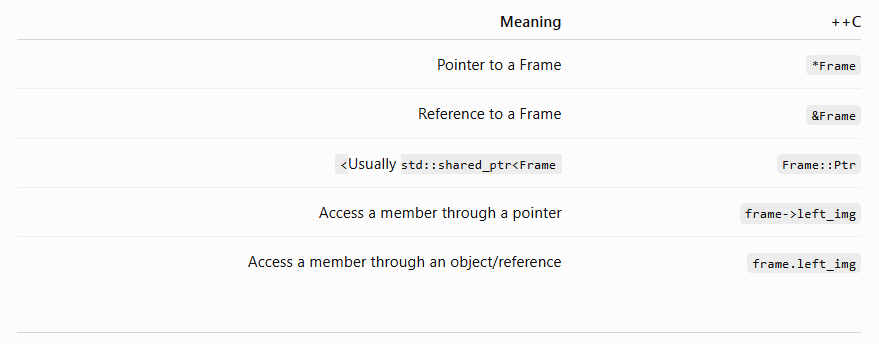

### **11. Mental Model**

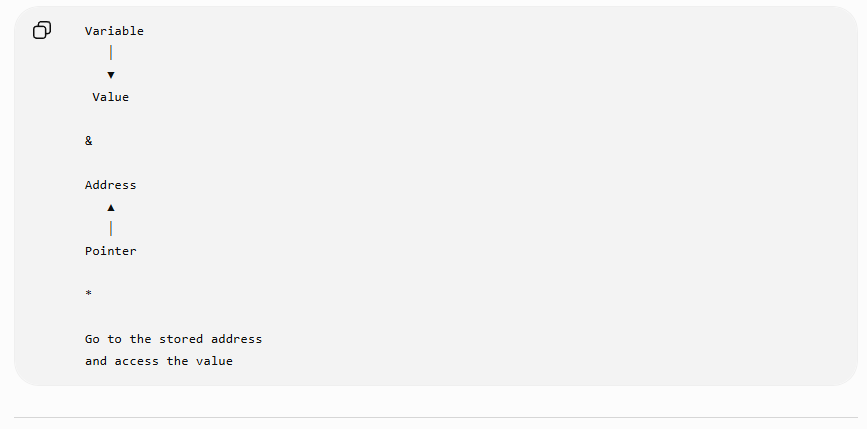

### **12. smart pointer**

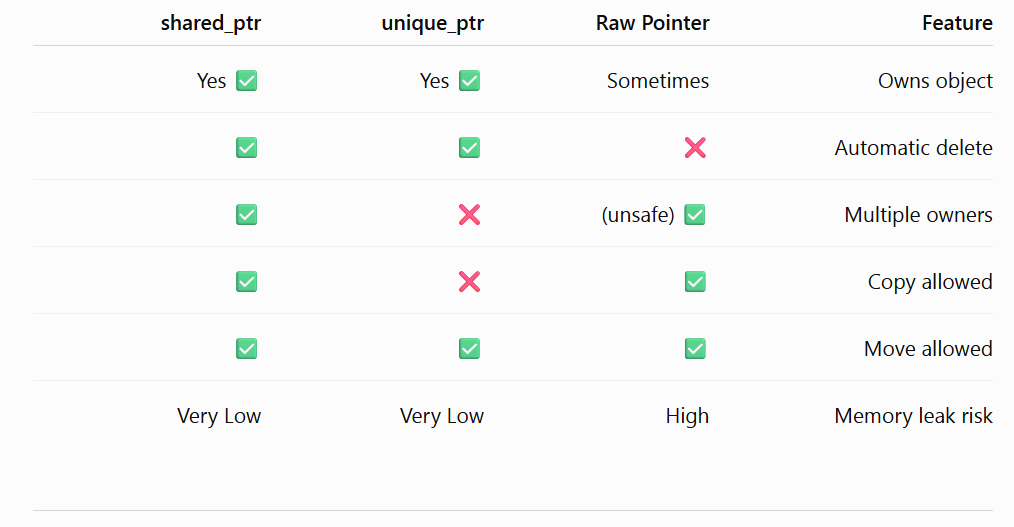

### **Big Picture of Visual SLAM**

In [ ]:
Camera
    ↓
Images
    ↓
Feature Extraction
    ↓
Feature Matching
    ↓
Triangulation
    ↓
PnP
    ↓
Tracking
    ↓
Local Mapping
    ↓
Bundle Adjustment
    ↓
Loop Closure
    ↓
Pose Graph Optimization

# **Chapter 1 — Modern C++ Foundations**

## **Pass by Value / Reference**

**Why do we need it?**



Functions often need to receive data from the caller. There are two common ways to pass that data:

* **Pass by Value** creates a copy of the object.
* **Pass by Reference** gives the function direct access to the original object.

Choosing the right method affects performance, memory usage, and whether the original object can be modified.



Functions need a way to receive data. Choosing how data is passed affects performance, memory usage, and whether the original object can be modified.

**What is it?**

**Pass by Value**

A copy of the variable is passed to the function.

Changes inside the function do not affect the original object.

In [ ]:
void foo(Frame frame);

**Pass by Reference**

The function works directly with the original object.

Changes inside the function affect the original object.



In [ ]:
void foo(Frame& frame);

**Pass by Const Reference**

The function uses the original object without making a copy, but it cannot modify it.



In [ ]:
void foo(const Frame& frame);



This is usually the preferred choice for large objects.

**Syntax**

In [ ]:
void f(Frame frame);          // Pass by Value

void f(Frame& frame);         // Pass by Reference

void f(const Frame& frame);   // Pass by Const Reference

**Example**

In [ ]:
void move(Pose& p)
{
    p.x += 1;
}

No copy is created.

The original pose is updated.

**Common Mistakes**

❌ Passing large objects by value.

In [ ]:
void process(Frame frame);

This creates an unnecessary copy.

❌ Forgetting const when the function should not modify the object.

Instead of

In [ ]:
void process(Frame& frame);

prefer

In [ ]:
void process(const Frame& frame);

**SLAM Example**


In SLAM, classes such as

* Frame
* Map
* Camera
* Feature

can contain a large amount of data.

Copying them repeatedly is expensive.

Therefore, SLAM libraries usually use

In [ ]:
Frame&


or

In [ ]:
const Frame&

instead of


In [ ]:
Frame

to avoid unnecessary copying.


**Key Takeaways**

* Pass by Value creates a copy.
* Pass by Reference avoids copying.
* Use const& when the object should not be modified.
* Large SLAM objects are almost always passed by reference.

* Value → copy
* Reference → original object
* Const reference → no copy + read only

**Interview Questions**

* Why is const Frame& preferred over Frame?
* When should you use pass by value?

### **Basics**

In [ ]:
%%writefile basics.cpp

#include <iostream>
using namespace std;

int main() {
    int a = 10;
    int* p = &a;
    q = &a;

    cout << "a: " << a << endl;
    cout << "&a: " << &a << endl;

    cout << "p: " << p << endl;
    cout << "* p: " << * p << endl;

    cout << "q: " << q << endl;
    cout << "* q: " << * q << endl;

    return 0;
}

Overwriting basics.cpp


In [ ]:
!g++ basics.cpp -o basics
!./basics

basics.cpp: In function ‘int main()’:
basics.cpp:8:5: error: ‘q’ was not declared in this scope
    8 |     q = &a;
      |     ^
a: 10
p: 0x7ffc9f3c71bc
&a: 0x7ffc9f3c71bc
* p: 10


In [ ]:
%%writefile basics.cpp

#include <iostream>
using namespace std;

int main() {
    int frame_id = 1;
    double depth = 5.32;
    bool tracking_ok = true;

    cout << "Frame: " << frame_id << endl;
    cout << "Depth: " << depth << endl;
    cout << "Tracking OK? " << tracking_ok << endl;

    return 0;
}


Writing basics.cpp


In [ ]:
!g++ basics.cpp -o basics
!./basics

Frame: 1
Depth: 5.32
Tracking OK? 1


In [ ]:
%%writefile basicsInput.cpp

#include <iostream>
using namespace std;

int main() {
  int n;
  cout << "Enter number: ";
  cin >> n;
  cout << "You entered: " << n << endl;
  return 0;
};


Writing basicsInput.cpp


In [ ]:
!g++ basicsInput.cpp -o basicsInput
!./basicsInput

Enter number: 127
You entered: 127


In [ ]:
%%writefile SLAMDistance.cpp

#include <iostream>
#include <cmath>
using namespace std;

int main() {

  float x1, y1, theta1;
  float x2, y2, theta2;
  float dx, dy, dθ, d;

  cout << "Enter x1: ";
  cin >> x1;
  cout << "Enter y1: ";
  cin >> y1;
  cout << "Enter theta1: ";
  cin >> theta1;
  cout << "Enter x2: ";
  cin >> x2;
  cout << "Enter y2: ";
  cin >> y2;
  cout << "Enter theta2: ";
  cin >> theta2;

  dx = x2 - x1;
  dy = y2 - y1;
  dθ = theta2 - theta1;

  d = std::sqrt(std::pow(x2 - x1, 2) + std::pow(y2 - y1, 2));

  std::cout << "Δx: " << dx
            << " \n Δy: " << dy
            << " \n Δθ: " << dθ
            << " \n distance: " << d << std::endl;

  return 0;

};


Overwriting SLAMDistance.cpp


In [ ]:
!g++ SLAMDistance.cpp -o dist
!./dist

Enter x1: 3
Enter y1: 3
Enter theta1: 3
Enter x2: 3
Enter y2: 3
Enter theta2: 3
Δx: 0 
 Δy: 0 
 Δθ: 0 
 distance: 0


In [ ]:
%%writefile SLAMDistance.cpp

#include <iostream>
#include <cmath>
using namespace std;

// --- Function declaration ---
void computeDelta(float x1=12, float y1=0, float theta1=5,
                  float x2=18, float y2=8, float theta2=25,
                  float &dx, float &dy, float &dtheta, float &dist)
{
    dx = x2 - x1;
    dy = y2 - y1;
    dtheta = theta2 - theta1;
    dist = sqrt(pow(dx, 2) + pow(dy, 2));
}

int main() {
    float x1, y1, t1, x2, y2, t2;
    float dx, dy, dtheta, dist;

    cout << "Enter x1: "; cin >> x1;
    cout << "Enter y1: "; cin >> y1;
    cout << "Enter theta1: "; cin >> t1;
    cout << "Enter x2: "; cin >> x2;
    cout << "Enter y2: "; cin >> y2;
    cout << "Enter theta2: "; cin >> t2;

    computeDelta(x1, y1, t1, x2, y2, t2,
                 dx, dy, dtheta, dist);

    cout << "Δx: " << dx << "\nΔy: " << dy
         << "\nΔθ: " << dtheta << "\ndist: " << dist << endl;

    return 0;
}

Overwriting SLAMDistance.cpp


In [ ]:
!g++ SLAMDistance.cpp -o dist
!./dist

SLAMDistance.cpp:9:26: error: default argument missing for parameter 7 of ‘void computeDelta(float, float, float, float, float, float, float&, float&, float&, float&)’
    9 |                   float &dx, float &dy, float &dtheta, float &dist)
      |                   ~~~~~~~^~
SLAMDistance.cpp:7:25: note: ...following parameter 1 which has a default argument
    7 | void computeDelta(float x1=12, float y1=0, float theta1=5,
      |                   ~~~~~~^~~~~
SLAMDistance.cpp:9:37: error: default argument missing for parameter 8 of ‘void computeDelta(float, float, float, float, float, float, float&, float&, float&, float&)’
    9 |                   float &dx, float &dy, float &dtheta, float &dist)
      |                              ~~~~~~~^~
SLAMDistance.cpp:9:48: error: default argument missing for parameter 9 of ‘void computeDelta(float, float, float, float, float, float, float&, float&, float&, float&)’
    9 |                   float &dx, float &dy, float &dtheta, float &dis

### **Exercise 1**

**Exercise:** Distance Calculation

**Application in SLAM:** Feature matching and ICP


**Problem Definition:**
Calculate a simple distance

d = sqrt( (x2 - x1)^2 + (y2 - y1)^2 )

**Goal:**

**Input:**

**Output:**


In [ ]:
%%writefile basicDist.cpp

#include <iostream>
#include <cmath>
using namespace std;
// Function to calculate the distance between two points
double calculateDistance(double x1, double y1, double x2, double y2) {
    double distance = sqrt(pow(x2 - x1, 2) + pow(y2 - y1, 2));
    return distance;
}

int main() {
  double x1;
  double y1;
  double x2;
  double y2;
  double distance;


  cout << "Enter number x1: ";
  cin >> x1;
  cout << "Enter number y1: ";
  cin >> y1;
  cout << "Enter number x2: ";
  cin >> x2;
  cout << "Enter number y2: ";
  cin >> y2;

  distance = calculateDistance(x1, y1, x2, y2);

  cout << "calculated Distance: " << distance << endl;

  return 0;
}

Overwriting basics.cpp


In [ ]:
!g++ basicDist.cpp -o basics
!./basics

Enter number x1: 5
Enter number y1: 8
Enter number x2: 15
Enter number y2: 18
calculated Distance: 14.1421


**More Professional**

In [ ]:
%%writefile basicDist.cpp

#include <iostream>
#include <cmath>

using namespace std;

// Function to calculate the distance between two points
double calculateDistance(double x1, double y1, double x2, double y2) {
    double dx = x2 - x1;
    double dy = y2 - y1;

    return sqrt(dx * dx + dy * dy);
}

int main() {
  double x1, y1, x2, y2;

  cout << "Enter number x1: ";
  cin >> x1;
  cout << "Enter number y1: ";
  cin >> y1;
  cout << "Enter number x2: ";
  cin >> x2;
  cout << "Enter number y2: ";
  cin >> y2;


  cout << "Calculated distance: "
     << calculateDistance(x1, y1, x2, y2)
     << endl;

  return 0;
}

Writing basicDist.cpp


In [ ]:
!g++ basicDist.cpp -o basics
!./basics

Enter number x1: 10
Enter number y1: 1
Enter number x2: 10
Enter number y2: 10
Calculated distance: 9


**and More**

In [ ]:
%%writefile basicDist.cpp

#include <iostream>
#include <cmath>

using namespace std;

double calculateDistance(double x1, double y1,
                         double x2, double y2)
{
    return hypot(x2 - x1, y2 - y1);
}

int main()
{
    double x1, y1, x2, y2;

    cout << "Enter x1: ";
    cin >> x1;

    cout << "Enter y1: ";
    cin >> y1;

    cout << "Enter x2: ";
    cin >> x2;

    cout << "Enter y2: ";
    cin >> y2;

    cout << "\nDistance = "
         << calculateDistance(x1, y1, x2, y2)
         << endl;

    return 0;
}

In [ ]:
!g++ basicDist.cpp -o basics
!./basics

**and More with Struct**

In [ ]:
%%writefile basicDist.cpp

#include <iostream>
#include <cmath>

using namespace std;

struct Point2D
{
    double x;
    double y;
};

double calculateDistance(const Point2D& p1, const Point2D& p2)
{
    return hypot(p2.x - p1.x,
                 p2.y - p1.y);
}

int main()
{
    Point2D pointA, pointB;

    cout << "Enter x1: ";
    cin >> pointA.x;

    cout << "Enter y1: ";
    cin >> pointA.y;

    cout << "Enter x2: ";
    cin >> pointB.x;

    cout << "Enter y2: ";
    cin >> pointB.y;

    cout << "\nDistance = "
         << calculateDistance(pointA, pointB)
         << endl;

    return 0;
}

Writing basicDist.cpp


In [ ]:
!g++ basicDist.cpp -o basics
!./basics

Enter x1: 1
Enter y1: 1
Enter x2: 1
Enter y2: 9

Distance = 8


### **Exercise 2**

**Three Versions of computeDelta** ..........

**Exercise:** Simple function for ΔPose Calculator


**Application in SLAM:**


**Problem Definition:**

Take the robot's coordinates at two points in time

and calculate Δx, Δy, and Δθ.

**Compute Delta**

In [ ]:
%%writefile computeDelta.cpp

#include <iostream>
#include <cmath>
using namespace std;

// --- Function declaration ---
void computeDelta(float x1, float y1, float theta1,
                  float x2, float y2, float theta2,
                  float &dx, float &dy, float &dtheta, float &dist)
{
    dx = x2 - x1;
    dy = y2 - y1;
    dtheta = theta2 - theta1;
    dist = sqrt(pow(dx, 2) + pow(dy, 2));
}

int main() {
    float x1, y1, t1, x2, y2, t2;
    float dx, dy, dtheta, dist;

    cout << "Enter x1: "; cin >> x1;
    cout << "Enter y1: "; cin >> y1;
    cout << "Enter theta1: "; cin >> t1;
    cout << "Enter x2: "; cin >> x2;
    cout << "Enter y2: "; cin >> y2;
    cout << "Enter theta2: "; cin >> t2;

    computeDelta(x1, y1, t1, x2, y2, t2,
                 dx, dy, dtheta, dist);

    cout << "Δx: " << dx << "\nΔy: " << dy
         << "\nΔθ: " << dtheta << "\ndist: " << dist << endl;

    return 0;
}

In [ ]:
!g++ computeDelta.cpp -o basics
!./basics

**More Professional**

In [ ]:
%%writefile computeDelta.cpp

#include <iostream>
#include <cmath>
using namespace std;

struct Pose
{
    double x;
    double y;
    double theta;
};

struct Delta
{
    float dx;
    float dy;
    float dtheta;
    float dist;
};

Delta computeDelta(const Pose& p1,
                   const Pose& p2)
{
    Delta d;

    d.dx = p2.x - p1.x;
    d.dy = p2.y - p1.y;
    d.dtheta = p2.theta - p1.theta;
    d.dist = hypot(d.dx, d.dy);

    return d;
}


int main() {

  Pose P1;
  Pose P2;

  cout << "Enter x1 and y1 and theta: ";
  cin >> P1.x >> P1.y >> P1.theta;

  cout << "Enter x1 and y2 and theta: ";
  cin >> P2.x >> P2.y >> P2.theta;

  Delta delta = computeDelta(P1, P2);

  cout << delta.dtheta<< endl;
  cout << delta.dist<< endl;

  return 0;
}

Overwriting computeDelta.cpp


In [ ]:
!g++ computeDelta.cpp -o basics
!./basics

Enter x1 and y1 and theta: 10 10 50
Enter x1 and y2 and theta: 20 20 30
-20
14.1421


### **Exercise 3**

**Exercise:** Simple function for average Calculation.


**Application in SLAM:**


**Problem Definition:**

Write a function that calculates the average of two numbers

First using pass-by-value, and then again using pass-by-reference.

**Pass by Value**

In [ ]:
%%writefile computeAverage.cpp

#include <iostream>
using namespace std;

double average(double a, double b)
{
    return (a + b) / 2.0;
}

int main()
{
    double x = 10;
    double y = 20;

    double avg = average(x, y);

    cout << "Average = " << avg << endl;

    return 0;
}

In [ ]:
x ----------> 10
                 \
                  \ (copy)
                   \
a ----------> 10

y ----------> 20
                 \
                  \ (copy)
                   \
b ----------> 20

**Pass by Reference**

In [ ]:
%%writefile computeAverage.cpp

#include <iostream>
using namespace std;

double average(const double& a, const double& b)
{
    return (a + b) / 2.0;
}

int main()
{
    double x = 10;
    double y = 20;

    double avg = average(x, y);

    cout << "Average = " << avg << endl;

    return 0;
}

In [ ]:
x = 10  <---------
                 |
                 |
const double& a --

In [ ]:
y = 20  <---------
                 |
                 |
const double& b --

We apply **const T&** to avoid unnecessary copies.

In [ ]:
# تمرین 1 — مقداردهی با pointer و dereference

# یک برنامه بنویس که:

# یک متغیر int a تعریف کند (مثلاً مقدار اولیه 10)
# یک pointer به آن بسازد (int* p = &a)
# مقدار a را فقط از طریق pointer تغییر بدهد
# (یعنی a = ... استفاده نکن، فقط *p = ...)
# بعد مقدار جدید a و *p را چاپ کن

# 🔹 نکته مهم: فقط با *p مقدار رو عوض کن.

In [ ]:
%%writefile computeDelta.cpp

#include <iostream>
using namespace std;
int main()
{
  int a = 10;
  cout << "a: " << a << endl;
  int* p = &a; cout << "p: " << p << endl;
  cout << "*p: " << *p << endl; *p = 11;
  cout << "a: " << a << endl; cout << "p: " << p << endl;
  cout << "*p: " << *p << endl;

  return 0;
  }

In [ ]:
# تمرین 2 — swap با pointer

# یک تابع بنویس:

# void swapInts(int* a, int* b)

# که مقادیر را با pointer ها جابه‌جا کند:

# int x = 5, y = 8;
# swapInts(&x, &y);

# نتیجه باید بشه → x=8 و y=5

# 🔹 نکته: از هیچ reference استفاده نکن. فقط pointer.

In [ ]:
%%writefile computeDelta.cpp
#include <iostream>
using namespace std;

void swapInts(int* a, int* b)
{ int c = *a; *a = *b; *b = c;
}

int main()
{
  int x = 5, y = 8;
  cout << "x: " << x << endl;
  cout << "y: " << y << endl;
  cout << "&x: " << &x << endl;
  cout << "&y: " << &y << endl;
  swapInts(&x, &y); cout << "x: " << x << endl;
  cout << "y: " << y << endl; cout << "&x: " << &x << endl;
  cout << "&y: " << &y << endl;
  return 0;

}

In [ ]:
#تمرین 3 مجموع با reference خروجی

# تابع بنویس:

# void computeSum(int a, int b, int &outSum)

# که:

# outSum را برابر جمع a و b بگذارد
# در main باهاش کار کن و مقدار خروجی را چاپ کن

# 🔹 نکته: outSum فقط باید reference باشد، pointer استفاده نکن.

In [ ]:
#include <iostream>
using namespace std;

void computeSum(int a, int b, int &outSum) {
    outSum = a + b;   // فقط مقداردهی
}

int main() {
    int x = 5, y = 8;
    int result;        // متغیری که outSum بهش وصل میشه
    int &outSum = result;

    computeSum(x, y, outSum);

    cout << "SUM: " << outSum << endl;

    return 0;
}

In [ ]:
# Pass by reference
void computeSum(int a, int b, int &res){
  res = a + b;
}

In [ ]:
# بازگرداندن مقدار

int computeSum(int a, int b){
  return a + b;
}
result = computeSum(x, y);

In [ ]:
# پکیج تمرینی — Pointer + Reference + Value-Pass

# (از ساده → متوسط → حرفه‌ای)

# 🔹 بخش A — Pass-by-Value (ساده → متوسط)
# تمرین A1 — چرا جواب نمی‌دهد؟

# کد زیر را اجرا کن و دلیل خروجی را توضیح بده:

In [ ]:
#include <iostream>
using namespace std;

void increase(int x) {
    x += 10;
}

int main() {
    int a = 5;
    increase(a);
    cout << a << endl;  // خروجی؟ چرا؟
}

In [ ]:
# تمرین A2 — شبیه‌سازی pass-by-value

# تابعی بنویس که مقدار ورودی را سه برابر کند، ولی طوری بنویس که مقدار اصلی تغییر نکند:

In [ ]:
int tripleValue(int x);

In [ ]:
# بخش B — Pass-by-Reference (متوسط → حرفه‌ای)
# تمرین B1 — اصلاح تابع غلط

# تابع زیر اشتباه است. آن را به pass-by-reference تبدیل کن:

void setTo100(int x);

# که در main بشود:

int a = 7;
setTo100(a);
cout << a;   // باید 100 چاپ کند

In [ ]:
# تمرین B2 — swap حرفه‌ای

# تابعی بنویس که سه عدد را به صورت cyclic جابه‌جا کند:

In [ ]:
void rotate3(int &a, int &b, int &c);

# ورودی:

a=1, b=2, c=3

# خروجی:

a=3, b=1, c=2

In [ ]:
# 🔹 بخش C — Pointer (متوسط → سخت)
# تمرین C1 — مقداردهی پویا

# کدی بنویس که:

# یک عدد در heap بسازد
# مقدار 42 را در آن بنویسد
# آدرس و مقدار را چاپ کند
# و در پایان delete کند

In [ ]:
int* allocateNumber();

In [ ]:
# تمرین C2 — pointer swap

# بدون استفاده از reference، فقط با pointer ها swap بنویس:

In [ ]:
void swapPtr(int* a, int* b);

In [ ]:
# تمرین C3 — اشاره‌گرهای مضاعف (double pointer)

# کدی بساز که:

# یک اشاره‌گر اولیه (int* p)
# یک اشاره‌گر به اشاره‌گر (int** q)
# مقدار را با استفاده از **q تغییر دهد

# مثلاً:

In [ ]:
int x = 5;
int* p = &x;
int** q = &p;

**q = 20;

In [ ]:
# 🔹 بخش D — Dereference حرفه‌ای (در حد SLAM و ROS)
# تمرین D1 — تغییر دادن یک struct با pointer

# فرض کن state روبوت:

struct Pose {
    float x, y, theta;
};

# تابعی بنویس:

void moveForward(Pose* p, float dist);

# و مقدار x و y را تغییر بده (مثل ربات موبایل).

In [ ]:
# تمرین D2 — تغییر با reference (نسخه مدرن‌تر)

# تابع قبل را این بار با reference بنویس:

void moveForward(Pose &p, float dist);

# تفاوت pointer و reference را توضیح بده.

In [ ]:
# بخش E — چالش نهایی (Professional Level)

# این تمرین درک واقعی تو را امتحان می‌کند:

# تمرین E1 — تابع computeDelta که خودت نوشتی، اما این‌بار ۳ نسخه

# همان تابع معروف:

void computeDelta(...);

# اما:

# ◼ نسخه ۱ — فقط با pass-by-value (و نشان بده که کار نمی‌کند)
# ◼ نسخه ۲ — کاملاً با pointer ها (float* dx و ...)
# ◼ نسخه ۳ — نسخهٔ استاندارد SLAM با reference (درست‌ترین نسخه)

### **Exercise 4**

**Exercise:** Swap.


**Application in SLAM:**


**Problem Definition:**

Write a function that ......

First using pass-by-value, and then again using pass-by-reference .......

## **Pointer**

**Why do we need it?**

Pointers allow multiple parts of a program to access the same object without copying it. They also enable dynamic memory allocation and flexible object relationships.

**What is it?**

A pointer stores the memory address of another object.

**Syntax**

In [ ]:
int a = 5;
int* p = &a;

**Example**

In [ ]:
Frame frame;

Frame* ptr = &frame;

**Common Mistakes**

* Uninitialized pointers
* Dangling pointers
* Forgetting to check for **nullptr**

**SLAM Example**


Many SLAM modules keep pointers to the same **Frame** or **Map**.

**Key Takeaways**

* Pointer stores an address.
* **&** gets an address.
* "*" accesses the object.

**Interview Questions**

* What is the difference between a pointer and a reference?
* What is nullptr?

## **Dereference**

**Why do we need it?**

A pointer only stores an address. Dereferencing allows us to access the actual object stored at that address.

**What is it?**

Dereferencing means accessing the object through a pointer.

**Syntax**

In [ ]:
*p

**Example**

In [ ]:
Pose p;

Pose* ptr = &p;

ptr->x = 10;

// equivalent

(*ptr).x = 10;

**Common Mistakes**

* Dereferencing nullptr
* Confusing * in declaration and dereference

**SLAM Example**


In [ ]:
current_frame_->Pose();

or

In [ ]:
(*frame_ptr).id

**Key Takeaways**

* Pointer → address
* Dereference → object

**Interview Questions**

* What happens if you dereference a null pointer?

## **Struct**

**Why do we need it?**

Related variables should be grouped into one logical object.

**What is it?**

A struct is a user-defined type that groups related data.

**Syntax**

In [ ]:
struct Pose
{
    double x;
    double y;
    double theta;
};

**Example**

In [ ]:
Pose robot;

**Common Mistakes**

* Using many unrelated members
* Confusing struct and class

**SLAM Example**


Pose, Point, Feature

**Key Takeaways**

* Struct groups related data.

**Interview Questions**

* Struct vs Class?

## **Constructor / Destructor**

**Why do we need it?**

Objects often need initialization when created and cleanup when destroyed.

**What is it?**

Constructor initializes an object.

Destructor releases its resources.

**Syntax**

In [ ]:
Frame();

~Frame();

**Example**

In [ ]:
Frame frame;

**Common Mistakes**

* Forgetting initialization lists
* Manual cleanup when smart pointers already manage memory

**SLAM Example**


**Key Takeaways**

Backend initializes optimizer objects.

**Interview Questions**

* Constructor → setup
* Destructor → cleanup

### **Tips**

**Constructor + Member Initializer List**

Example:

In [ ]:
Counter()
{
    name_ = "Ali";
}

First: **name_** is generated

Then: copy **"Ali"** in it


**vs.**

In [ ]:
Counter()
    : name_("Ali")
{
}

**Ali** is generated at the first step.

### **Types**

#### **Default Constructor**

In [ ]:
Car()
{
}

#### **Parameterized  Constructor**

In [ ]:
class Car
{
public:

    Car(int speed)
    {
        speed_ = speed;
    }

private:

    int speed_;
};

application

In [ ]:
Car c(120);

#### **or a better Parameterized  Constructor**

In [ ]:
Car(int speed)
    : speed_(120)
{
}

or using parameters

In [ ]:
Car(int speed)
    : speed_(speed)
{
}

### **C 1**

Complete the code in order to have:

In [ ]:
name = "Unknown"
age = 18

when calling

In [ ]:
Student s;

In [ ]:
%%writefile basicConstructor.cpp

class Student
{
public:

    Student()
    {
        name_ = "Unknown";
        age_ = 18;
    }

private:

    std::string name_;
    int age_;
};

or

In [ ]:
Student()
    : name_("Unknown"),
      age_(18)
{
}

There is a little differnece for **int**. However, they would be remarkably analegeous in such examples:

In [ ]:
std::string

std::vector

Eigen::Matrix

shared_ptr

### **C 2**

Change the previous one in ordert ot be able to have:

In [ ]:
Student s("Fatemeh", 24);

In [ ]:
%%writefile basicConstructor.cpp

class Student
{
public:
Student(std::string name, int age)
{
    name_ = name;
    age_ = age;
}

private:
    std::string name_;
    int age_;
};

or more professional:

In [ ]:
%%writefile basicConstructor.cpp

class Student
{
public:
Student(std::string name, int age)
    : name_(name),
      age_(age)
{
}

private:
    std::string name_;
    int age_;
};

### **C 3**

In [ ]:
class Camera
{
public:

private:

    double fx_;
    double fy_;
};

Complete the code in order to be able to call:

In [ ]:
Camera cam(520.9, 521.0);

In [ ]:
class Camera
{
public:
Camera(double fx, double fy)
  : fx_(fx),
    fy_(fy)
{
}


private:

    double fx_;
    double fy_;
};

### **C 4**

Run and check the result:

In [ ]:
%%writefile basicConstructor.cpp

#include <iostream>
#include <string>

class Student
{
public:
    Student(std::string name)
        : name_(name)
    {
      name_ = "Ali";
    }

    std::string getName() const
    {
        return name_;
    }

private:
    std::string name_;
};

int main()
{
    Student s("Fatemeh");

    std::cout << s.getName() << std::endl;

    return 0;
}

Overwriting basicConstructor.cpp


In [ ]:
!g++ basicConstructor.cpp -o out
!./out

Ali


In [ ]:
%%writefile basicConstructor.cpp

#include <iostream>
#include <string>

class Student
{
public:
    Student(std::string name)
        : name_(name)
    {
    }

    std::string getName() const
    {
        return name_;
    }

private:
    std::string name_;
};

int main()
{
    Student s("Fatemeh");

    std::cout << s.getName() << std::endl;

    return 0;
}

Overwriting basicConstructor.cpp


In [ ]:
!g++ basicConstructor.cpp -o out
!./out

Fatemeh


### **C 5**

Complete the Custructor in order to have count_ = 0 in advance.

In [ ]:
%%writefile basicConstructor.cpp

class Counter
{
public:
    Counter();

private:
    int count_;
};

In [ ]:
%%writefile basicConstructor.cpp

class Counter
{
public:
    Counter()
    : count_(0)
{
}

private:
    int count_;
};

### **C 6**

We want to have this code possible:

In [ ]:
Camera cam(
    520.9,
    521.0,
    325.1,
    249.7
);

In [ ]:
class Camera
{
public:
  Camera(double fx, double fy, double cx, double cy)
{
    fx_ = fx;
    fy_ = fy;
    cx_ = cx;
    cy_ = cy;
}

private:
    double fx_;
    double fy_;
    double cx_;
    double cy_;
};

or

In [ ]:
class Camera
{
public:
  Camera(double fx, double fy, double cx, double cy)
    : fx_(fx),
      fy_(fy),
      cx_(cx),
      cy_(cy)
{
}

  private:
    double fx_;
    double fy_;
    double cx_;
    double cy_;
};

### **C 7**

In [ ]:
class Backend
{
public:

private:
    Frame::Ptr current_frame_;
    Map::Ptr map_;
};

In [ ]:
# می‌خواهیم هنگام ساخت Backend، دو Pointer ورودی بگیرد.

Frame::Ptr frame = std::make_shared<Frame>();
Map::Ptr map = std::make_shared<Map>();

Backend backend(frame, map);

In [ ]:
%%writefile Backend.cpp

class Backend
{
public:
Backend(Frame::Ptr frame, Map::Ptr map)
    :current_frame_(frame),
     map_(map)
{

}

private:
    Frame::Ptr current_frame_;
    Map::Ptr map_;
};

or

In [ ]:
%%writefile Backend.h

class Backend
{
public:

    Backend(Frame::Ptr frame, Map::Ptr map);

private:

    Frame::Ptr current_frame_;
    Map::Ptr map_;
};

In [ ]:
%%writefile Backend.cpp

#include "Backend.h"

Backend::Backend(Frame::Ptr frame, Map::Ptr map)
    : current_frame_(frame),
      map_(map)
{
}

### **C 8**

Run and check the result:

In [ ]:
%%writefile basicConstructor.cpp

class Person
{
public:
    Person()
        : age_(20)
    {
        age_ = 30;
    }

private:
    int age_;
};

In [ ]:
%%writefile basicConstructor.cpp

#include <iostream>
#include <string>

class Person
{
public:
    Person()
        : age_(20)
    {
        age_ = 30;
    }

    int getAge() const
    {
        return age_;
    }

private:
    int age_;
};

int main()
{
    Person s;

    std::cout << s.getAge() << std::endl;

    return 0;
}

Overwriting basicConstructor.cpp


In [ ]:
!g++ basicConstructor.cpp -o out
!./out

30


### **C 9**

In [ ]:
class Student
{
public:

    Student()
        : age_(18)
    {
    }

private:

    std::string name_;
    int age_;
};

Run and check the result. What would be "name_"?

In [ ]:
%%writefile basicConstructor.cpp

#include <iostream>
#include <string>

class Student
{
public:
    Student()
        : age_(18)
    {
    }

    std::string getName() const
    {
        return name_;
    }
    int getAge() const
    {
        return age_;
    }

private:
    std::string name_;
    int age_;
};

int main()
{
    Student s;

    std::cout << "Name: " << s.getName() << std::endl;
    std::cout << "Age: " << s.getAge() << std::endl;

    return 0;
}

Overwriting basicConstructor.cpp


In [ ]:
!g++ basicConstructor.cpp -o out
!./out

Name: 
Age: 18


### **C 10**

Look at this code:

In [ ]:
class Camera
{
public:

    Camera(
        double fx,
        double fy,
        double cx,
        double cy
    );

private:

    double fx_;
    double fy_;
    double cx_;
    double cy_;
};

To add this new member

In [ ]:
std::string camera_name_;

and to be able to run this code

In [ ]:
Camera cam(
    520,
    520,
    320,
    240,
    "Left Camera"
);

Let's work on both: Declaration and Implementation

In [ ]:
%%writefile Camera.h

#pragma once

class Camera
{
public:

    Camera(
        double fx,
        double fy,
        double cx,
        double cy,
        std::string camera_name
    );


    std::string getName() const;

private:

    double fx_;
    double fy_;
    double cx_;
    double cy_;

    std::string camera_name_;
};

Overwriting Camera.h


In [ ]:
%%writefile Camera.cpp


#include <iostream>
#include <string>


#include "Camera.h"

Camera::Camera(
    double fx,
    double fy,
    double cx,
    double cy,
    std::string camera_name)
    : fx_(fx),
      fy_(fy),
      cx_(cx),
      cy_(cy),
      camera_name_(camera_name)
{
}

std::string Camera::getName() const
{
    return camera_name_;
}

int main()
{
    Camera cam(
    520,
    520,
    320,
    240,
    "Left Camera"
);

    std::cout << "Camera: " << cam.getName() << std::endl;

    return 0;
}


Overwriting Camera.cpp


In [ ]:
!g++ Camera.cpp -o out
!./out

Camera: Left Camera


In [ ]:
#pragma once

#include <string>

class Camera
{
public:

    Camera(
        double fx,
        double fy,
        double cx,
        double cy,
        std::string camera_name
    );

    std::string getName() const;

private:

    double fx_;
    double fy_;
    double cx_;
    double cy_;

    std::string camera_name_;
};

In [ ]:
#include <iostream>
#include "Camera.h"

Camera::Camera(
    double fx,
    double fy,
    double cx,
    double cy,
    std::string camera_name)
    : fx_(fx),
      fy_(fy),
      cx_(cx),
      cy_(cy),
      camera_name_(camera_name)
{
}

std::string Camera::getName() const
{
    return camera_name_;
}

int main()
{
    Camera cam(
        520,
        520,
        320,
        240,
        "Left Camera"
    );

    std::cout << cam.getName() << std::endl;
}

تمریناش

RAII

فرق هیپ و استک

## **Header Files**

**Why do we need it?**

Separate declarations from implementations to improve modularity and compilation speed.

**What is it?**

Headers contain declarations.

CPP files contain implementations.

**Syntax**

In [ ]:
pose.h

pose.cpp

**Common Mistakes**

* Missing include guards
* Putting implementations in headers unnecessarily

**SLAM Example**


Every major module has its own header.

**Key Takeaways**

* Header = declaration
* CPP = implementation

### **H1**

**BasicHeaders**

**Goal:** declaration vs. definition

In [ ]:
%%writefile math_utils.h

#pragma once

#include <iostream>
using namespace std;

float add(float a, float b);

Writing math_utils.h


Why?

... #include <iostream> and

... using namespace std;

There is a rule; all other parts must be able to be run only with: #include "math_utils.h"

In [ ]:
%%writefile math_utils.cpp

#include "math_utils.h"

float add(float a, float b) {
    return a + b;
}


Writing math_utils.cpp


In [ ]:
%%writefile main.cpp

// #include <iostream>
// using namespace std;

#include "math_utils.h"

int main() {
    std::cout << add(2, 3) << std::endl;
    return 0;
}

Writing main.cpp


In [ ]:
!g++ main.cpp math_utils.cpp -o out
!./out

5


### **H2**

**Headers + Struct**

In [ ]:
Pose
│
├── headerStrct.h
│      فقط اعلام می‌کند declaration
│
├── headerStrct.cpp
│      پیاده‌سازی می‌کند Implementation
│
└── main.cpp
       استفاده می‌کند Calling

In [ ]:
%%writefile pose.h

#pragma once

#include <cmath>

struct Pose
{
    float x;
    float y;
    float theta;
};

void moveForward(Pose& p, float dist);


Writing pose.h


In [ ]:
%%writefile pose.cpp

#include "pose.h"

void moveForward(Pose& p, float dist)
{
    p.x += dist * cos(p.theta);
    p.y += dist * sin(p.theta);
}


Writing pose.cpp


In [ ]:
%%writefile main.cpp

#include <iostream>
#include "pose.h"
#include <cmath>
using namespace std;

// or
// constexpr double M_PI = 3.141592653589793;

int main()
{
  Pose P;

  P.x = 10;
  P.y = 5;
  P.theta = M_PI / 6;
  // P.theta = 30.0 * M_PI / 180.0;
  float D = 1;

  moveForward(P, D);

  std::cout << "x = " << P.x << " "
          << "y = " << P.y << " "
          << theta = " << P.theta << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

10.866 5.5 0.523599


### **H3**

**Headers + class**

**Goal:**

struct vs. class + public/private

In [ ]:
class Backend
{
public:

    Backend(Frame::Ptr frame, Map::Ptr map);

private:

    Frame::Ptr current_frame_;
    Map::Ptr map_;
};

In [ ]:
#include "Backend.h"

Backend::Backend(Frame::Ptr frame, Map::Ptr map)
    : current_frame_(frame),
      map_(map)
{
}

In [ ]:
%%writefile counter.h

#pragma once

class Counter
{

public:

    // Default Constructor
    Counter();

    void increment();
    int value() const;

private:

    int count_;

};

Writing counter.h


In [ ]:
%%writefile counter.cpp

#include "counter.h"

// constructor
Counter::Counter()
  : count_(0)
  {
  }

void Counter::increment() {
    count_++;
}

// get value
int Counter::value() const {
    return count_;
}


Writing counter.cpp


In [ ]:
%%writefile main.cpp

#include "counter.h"

int main()
{
  Counter counterr;

  std::cout << "Count: " << counterr.value() << std::endl;
  counterr.increment();
  std::cout << "Count: " << counterr.value() << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp counter.cpp -o out
!./out

Count: 0
Count: 1


### **H4**

**More Professional Headers: Pointer + ownership**

In [ ]:
%%writefile pose.h

#pragma once

#include <cmath>

struct Pose
{
    float x;
    float y;
    float theta;
};

void moveForward(Pose& p, float dist);


Overwriting pose.h


In [ ]:
%%writefile pose.cpp

#include "pose.h"

void moveForward(Pose& p, float dist)
{
    p.x += dist * cos(p.theta);
    p.y += dist * sin(p.theta);
}


Overwriting pose.cpp


In [ ]:
%%writefile tracker.h

#pragma once
#include "pose.h"

class Tracker
{

public:

    Tracker();

    void setPose(Pose* p);
    void move(float dist);

private:

    Pose* pose_;

};

Overwriting tracker.h


In [ ]:
%%writefile tracker.cpp

#include "tracker.h"

Tracker::Tracker()
  : pose_(nullptr)
  {

  }

void Tracker::setPose(Pose* p)
{
    pose_ = p;
}

void Tracker::move(float dist)
{
    if (pose_)
    {
        moveForward(*pose_, dist);
    }
}

Overwriting tracker.cpp


In [ ]:
%%writefile main.cpp

#include "tracker.h"
#include "pose.h"
#include <cmath>
#include <iostream>
using namespace std;

int main()
{
  Tracker tracker;
  Pose P;

  P.x = 10;
  P.y = 5;
  P.theta = M_PI / 6;

  float D = 1;

  tracker.setPose(&P);
  tracker.move(D);


  std::cout << "x = " << P.x << " "
          << "y = " << P.y << " "
          << "theta = " << P.theta << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp tracker.cpp pose.cpp -o out
!./out

x = 10.866 y = 5.5 theta = 0.523599


Why Pose* instead of Pose?

In [ ]:
class Tracker
{
private:
    Pose* pose_;
};

At first glance, it may seem simpler to store a Pose object directly:

In [ ]:
class Tracker
{
private:
    Pose pose_;
};

However, these two designs represent completely different ownership models.

**Option 1 — Store the object directly**

In [ ]:
Pose pose_;

The Tracker owns the Pose.


Whenever a Tracker object is created, its own Pose object is also created.

In [ ]:
Tracker
+----------------+
| Pose           |
| x              |
| y              |
| theta          |
+----------------+

Since the pose already exists inside the tracker, there is no reason to provide another one.


In this design, a function like

In [ ]:
setPose(...)

would no longer make sense.

Instead, the tracker would modify its own internal pose.

**Option 2 — Store a pointer**

In [ ]:
Pose* pose_;

Now the tracker does not own the pose.

It only stores the address of a pose that already exists somewhere else.

In [ ]:
Pose
+-----------+
| x         |
| y         |
| theta     |
+-----------+
      ▲
      │
      │
   pose_

The tracker simply works with that existing object.

This is why

In [ ]:
tracker.setPose(&robotPose);

makes sense.

The tracker receives the address of an existing pose and uses it whenever needed.

**Why is this useful in large projects?**

Large software systems (such as SLAM) usually have many modules that need access to the same object.

For example, a Frame may be used simultaneously by:

* Frontend
* Backend
* Viewer
* Map
* Loop Closing

Creating a separate copy for each module would waste memory and make synchronization difficult.

Instead, every module stores a pointer (or, more commonly, a smart pointer) to the same object.

In [ ]:
             Frame
               ▲
      ┌────────┼────────┐
      │        │        │
 Frontend   Backend   Viewer

All modules work on the same frame instead of maintaining independent copies.

This is one of the fundamental design ideas behind modern C++ software and many SLAM systems.

**When would setPose() no longer make sense?**

In [ ]:
Pose pose_;

instead of

In [ ]:
Pose* pose_;

then the tracker already owns its own pose.

Passing another pose from outside would create ambiguity:

* Which pose should the tracker use?
* Its internal one?
* Or the external one?

For this reason, a function like

In [ ]:
tracker.setPose(...)

is unnecessary in that design.

Instead, the class would provide functions such as

In [ ]:
tracker.setPosition(...)
tracker.move(...)
tracker.reset()

which directly modify its own internal pose.

**Your Design Rule**

Before choosing between an object and a pointer, always ask:

"Does this class own the object, or does it only use it?"

If it owns the object → store the object itself (or use std::unique_ptr when dynamic allocation is needed).
If it only uses an existing object → store a pointer, reference, or std::shared_ptr.

This simple question explains a large portion of the architecture used in SLAM, ROS, g2o, and many modern C++ projects.

### **H5**

**SLAM-Level Headers: (shared_ptr + namespace)**

In [ ]:
%%writefile frontend.h

#pragma once
#include <memory>
#include "pose.h"

namespace myslam {

class Frontend {

public:
    using Ptr = std::shared_ptr<Frontend>;

    Frontend();
    void setPose(std::shared_ptr<Pose> pose);
    void track(float dist);

private:
    std::shared_ptr<Pose> pose_;
};

}

## **typedef / using**

**Why do we need it?**

Long type names reduce readability.

**What is it?**

Creates an alias for an existing type.

**Syntax**

In [ ]:
using Ptr = std::shared_ptr<Frame>;

**Common Mistakes**

* Confusing alias with a new **type**

**SLAM Example**


In [ ]:
Frame::Ptr
Map::Ptr

**Key Takeaways**

Alias ≠ New type.

### **Exercise U1 — The Simplest Alias**

**Task**

Create an alias called Distance for the type double.

Then declare two variables of type Distance and print their sum.

**Requirements**

* Use using
* Print the result

In [ ]:
Distance = 12.5

In [ ]:
#include <iostream>
using namespace std;

// Type Alias
using Distance = double;

int main()
{
    Distance d1 = 12.5;
    Distance d2 = 7.3;

    cout << "Sum = " << d1 + d2 << endl;

    return 0;
}

Why do we use "using"?

Because the code becomes more readable.

For example:

In [ ]:
using Meter = double;
using Second = double;
using Velocity = double;

From this point on, we have:

In [ ]:
Meter length = 12.5;
Second time = 3.0;
Velocity speed = length / time;

It is far clearer.

### **Exercise U2 — Replace using with typedef**

Rewrite Exercise U1 using typedef instead of using.

Then answer:

**Which syntax do you personally find easier to read? Why?**

(One or two sentences are enough.)

In [ ]:
typedef double Distance;

I personally prefer **using**. More specifically it is much easier to read when we are working with **smart pointers**. for example:

using Ptr = std::shared_ptr<Frame>;

instead of

typedef std::shared_ptr<Frame> Ptr;

### **Exercise U3 — Alias for a Vector**

Create an alias for

In [ ]:
std::vector<int>

called

In [ ]:
IntVector

Then

* Create a vector
* Insert five numbers
* Print them using a range-based for loop

In [ ]:
%%writefile main.cpp

#include <vector>
#include <iostream>
using namespace std;


// Create a vector called numbers
using IntVector = std::vector<int>;
IntVector numbers;


int main()
{
    for (int i = 0; i < 5; i++)
{
    int value;
    cin >> value;
    numbers.push_back(value);
}

    cout << "*************************************"  << endl;

    for (int i : numbers) {
        cout << i << " ";
    }


    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

1
3
56
8
1
*************************************
1 3 56 8 1 

### **Exercise U4 — Alias for Smart Pointer**

Suppose we have

In [ ]:
struct Pose
{
    float x;
    float y;
    float theta;
};

Create an alias

In [ ]:
using Ptr = std::shared_ptr<Pose>;

Then

* Create a Pose using make_shared
* Assign values
* Print them

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <vector>

using namespace std;

#include <memory>

struct Pose
{
    float x;
    float y;
    float theta;

    using Ptr = std::shared_ptr<Pose>;
};


int main()
{

  Pose::Ptr pose = std::make_shared<Pose>();

  pose->x = 1.5f;
  pose->y = 2.3f;
  pose->theta = 90.0f;

  cout << "\nPose:\n";

  std::cout << pose->x << std::endl;
  std::cout << pose->y << std::endl;
  std::cout << pose->theta << std::endl;

  return 0;

}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o out
!./out


Pose:
1.5
2.3
90


### **Exercise U5 — Nested Alias (Very Important ⭐)**

This exercise is almost identical to real SLAM code.

In [ ]:
class Frame
{
public:

    using Ptr = std::shared_ptr<Frame>;

};

Now answer these questions:

**Q1**

What is Ptr?

Ptr is an Alias for 'std::shared_ptr<Frame>'; in fact an Alias for a smart pointer to a Frame.

So, it means that Ptr is another name for std::shared_ptr<Frame>.

**Q2**

What does Frame::Ptr mean?

The Ptr alias defined inside the Frame class.

So:

Frame::Ptr

is equivalent to:

In [ ]:
std::shared_ptr<Frame>

For example:



In [ ]:
Frame::Ptr frame = std::make_shared<Frame>();
# means:
std::shared_ptr<Frame> frame = std::make_shared<Frame>();


**Q3**

Is Ptr a new type or an alias?

an Alias

It does not create a new pointer type. It simply gives an existing type a shorter name:

In [ ]:
using Ptr = std::shared_ptr<Frame>;

**Q4**

Why is the alias defined inside the class instead of outside?

Because it makes the relationship between Frame and its pointer type clear and keeps the alias scoped to Frame.

* To avoid names mixed up.

Consider three classes:

1 class Frame {};
2 class Map {};
3 class Camera {};

It is not possible to have
using Ptr = std::shared_ptr<Frame>;

and

using Ptr = std::shared_ptr<Map>;

outside the class.

However, it's possible:

In [ ]:
class Frame
{
public:
    using Ptr = std::shared_ptr<Frame>;
};

# and

class Map
{
public:
    using Ptr = std::shared_ptr<Map>;
};

# and

class Camera
{
public:
    using Ptr = std::shared_ptr<Camera>;
};

* It is easier to read.

Frame::Ptr current_frame_;

instead of

std::shared_ptr<Frame> current_frame_;

* One name for all classes alias:

instead of:

using FramePtr = std::shared_ptr<Frame>;

using MapPtr = std::shared_ptr<Map>;

using CameraPtr = std::shared_ptr<Camera>;


So, we always have:

In [ ]:
class Frame
{
public:
    using Ptr = std::shared_ptr<Frame>;
};

then,

In [ ]:
Frame::Ptr frame;

And so on ...

### **Exercise U6 — Read Real SLAM Code**

Read the following declaration:

In [ ]:
using FeaturesType = std::unordered_map<long, std::vector<Frame::Ptr>>;

Answer the following:

**Q1**

What is the key type?

long

**Q2**

What is the value type?

In [ ]:
std::vector<Frame::Ptr>

So, for each long key, we store a vector of Frame::Ptr.

In [ ]:
Frame::Ptr
# means:
std::shared_ptr<Frame>

**Q3**

What does each std::vector store?

Each vector stores multiple Frame::Ptr objects.

For example, one entry could conceptually look like:

In [ ]:
Key:  101
Value:
    Frame 1
    Frame 5
    Frame 8
    Frame 12

Each of those Frames is represented by a Frame::Ptr.

So:

In [ ]:
std::vector<Frame::Ptr>

means:

A collection of pointers to Frames.

**Q4**

What does the whole unordered_map represent?

(Try to imagine a practical SLAM use case.)

Conceptually, it represents:

A mapping from an ID to all the Frames associated with that ID.

For example:

In [ ]:
Feature ID       Frames containing that feature
------------------------------------------------
101              Frame 1, Frame 5, Frame 8
205              Frame 2, Frame 5
310              Frame 1, Frame 4, Frame 7

In a practical SLAM scenario, imagine 101 is a visual feature / landmark ID.

That feature might be observed in several camera frames:

In [ ]:
Feature 101
     │
     ├── Frame 1
     ├── Frame 5
     └── Frame 8

### **Exercise U7 — Which One Would You Choose?**

For each of the following, decide whether you would use an alias and explain why.

**1**

In [ ]:
int

**2**

In [ ]:
std::vector<int>

Only in situations that we use one type repetedly; for example:

In [ ]:
using IntVector = std::vector<int>;

**3**

In [ ]:
std::unordered_map<long, std::vector<Frame::Ptr>>

I would use ..

for example

In [ ]:
using FeaturesType =
    std::unordered_map<long, std::vector<Frame::Ptr>>;

# So, we will apply instead:
FeaturesType features;

**4**

In [ ]:
std::shared_ptr<Map>

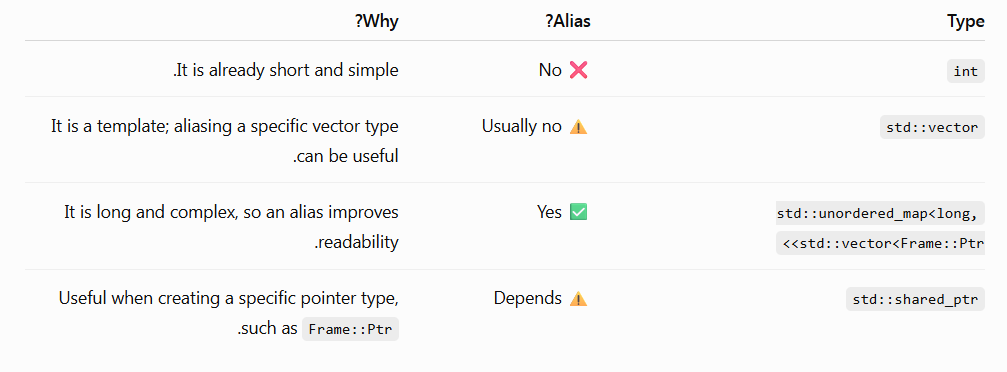

### **Final Challenge ⭐⭐⭐**

Explain the following code to someone who has never learned C++ before.

In [ ]:
class Frame
{
public:

    using Ptr = std::shared_ptr<Frame>;

};

Your explanation should answer:

* What is using?
* What is Ptr?
* What is shared_ptr?
* What is Frame::Ptr?
* Why do SLAM projects use this pattern everywhere?

**An alias does not create a new type. It simply gives an existing type a shorter or more meaningful name. In modern C++, using is preferred over typedef because it is more readable and works naturally with templates.**

## **smart pointer**

**Why do we need it?**

Automatically manages heap memory and prevents memory leaks.

**What is it?**

A smart pointer is an object that owns or shares ownership of dynamically allocated memory.

**Syntax**

In [ ]:
unique_ptr

shared_ptr

weak_ptr

**Common Mistakes**

* Copying unique_ptr
* Creating cycles with shared_ptr

**SLAM Example**


Almost every object (**Frame**, **MapPoint**, **Camera**) is managed using smart pointers.

**Key Takeaways**

* Prefer smart pointers over raw pointers.
* unique_ptr → exclusive ownership.
* shared_ptr → shared ownership.

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

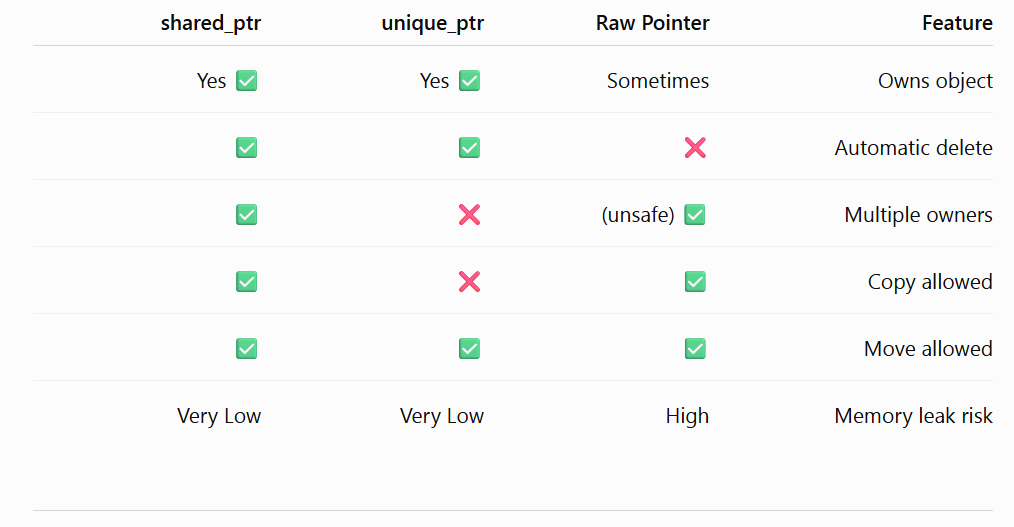

### **Smart Pointers — Part 1**

**Why do we need Smart Pointers?**

Raw pointers require manual memory management.

In [ ]:
Pose* p = new Pose();

The programmer is responsible for releasing the memory.

In [ ]:
delete p;

Forgetting to call delete results in a **memory leak**.

Calling delete twice leads to **undefined behavior**.

Using a pointer after deleting it creates a **dangling pointer**.

Smart pointers automate memory management and make C++ programs safer.

### **Exercise S1 — Creating a unique_ptr**

**Goal:**
Learn how to create an object using std::make_unique().

Create the following program.

In [ ]:
struct Pose
{
    float x;
    float y;
    float theta;
};

Inside main():

1. Create a std::unique_ptr<Pose> named robot.
2. Initialize

In [ ]:
x = 2
y = 5
theta = 0

3. Print all three values.

**Restrictions**

❌ Do NOT use

In [ ]:
new Pose

Only use

In [ ]:
std::make_unique

**Expected Learning**

After this exercise you should understand:

* how to create a unique_ptr
* how to access members through ->
* why make_unique() is preferred over new

In [ ]:
%%writefile pose.h

#pragma once

#include <cmath>

struct Pose
{
    float x;
    float y;
    float theta;
};

void moveForward(Pose* p, float dist);


Overwriting pose.h


In [ ]:
%%writefile pose.cpp

#include "pose.h"

void moveForward(Pose* p, float dist)
{
    p->x += dist * cos(p->theta);
    p->y += dist * sin(p->theta); // or (*p).x, as prioity is . then * >>> *p.x == *(p.x)
}


Overwriting pose.cpp


In [ ]:
%%writefile main.cpp

#include <iostream>
#include "pose.h"
#include <cmath>
#include <memory>
using namespace std;

// or
// constexpr double M_PI = 3.141592653589793;

int main()
{
  // Pose P;
  auto P = std::make_unique<Pose>();


  P->x = 10;
  P->y = 5;
  P->theta = M_PI / 6;
  // P->theta = 30.0 * M_PI / 180.0;
  float D = 1;

  // P.get() == &P
  moveForward(P.get(), D);

  std::cout << "x = " << P->x << " "
          << "y = " << P->y << " "
          << "theta = " << P->theta << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

x = 10.866 y = 5.5 theta = 0.523599


**Question:**

In [ ]:
auto P = std::make_unique<Pose>();

and

In [ ]:
Frame::Ptr frame = Frame::CreateFrame();
using Ptr = std::shared_ptr<Frame>;

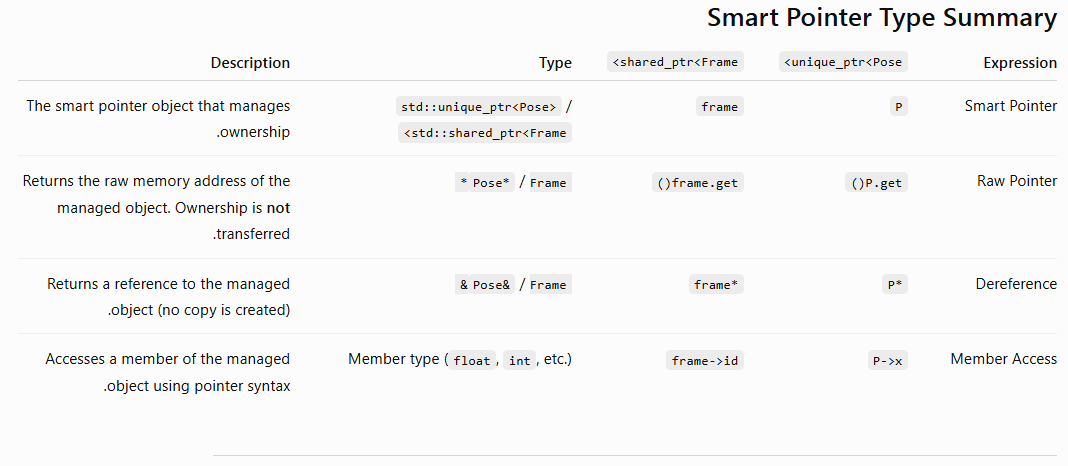

In [ ]:
P
│
├── Smart Pointer
│
├── P.get()
│      Raw Pointer
│
└── *P
       Reference to Pose

### **Exercise S2 — Ownership Transfer**

**Goal**

Understand that a unique_ptr has exactly one owner

Understand why std::unique_ptr cannot be copied and learn how ownership is transferred.

Given

In [ ]:
auto robot = std::make_unique<Pose>();

Try this:

In [ ]:
auto robot2 = robot;

Observe the compiler error.

In [ ]:
%%writefile pose.h

#pragma once

#include <cmath>

struct Pose
{
    float x;
    float y;
    float theta;
};

void moveForward(Pose* p, float dist);


Writing pose.h


In [ ]:
%%writefile pose.cpp

#include "pose.h"

void moveForward(Pose* p, float dist)
{
    p->x += dist * cos(p->theta);
    p->y += dist * sin(p->theta); // or (*p).x, as prioity is . then * >>> *p.x == *(p.x)
}


Writing pose.cpp


In [ ]:
%%writefile main.cpp

#include <iostream>
#include "pose.h"
#include <cmath>
#include <memory>
using namespace std;

// or
// constexpr double M_PI = 3.141592653589793;

int main()
{
  // Pose P;
  auto robot = std::make_unique<Pose>();



  robot->x = 10;
  robot->y = 5;
  robot->theta = M_PI / 6;
  // P->theta = 30.0 * M_PI / 180.0;
  float D = 1;

  // P.get() == &P
  moveForward(robot.get(), D);

  auto robot2 = robot;

  std::cout << "x = " << robot2->x << " "
          << "y = " << robot2->y << " "
          << "theta = " << robot2->theta << std::endl;

  return 0;
}

Writing main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

main.cpp: In function ‘int main()’:
main.cpp:27:17: error: use of deleted function ‘std::unique_ptr<_Tp, _Dp>::unique_ptr(const std::unique_ptr<_Tp, _Dp>&) [with _Tp = Pose; _Dp = std::default_delete<Pose>]’
   27 |   auto robot2 = robot;
      |                 ^~~~~
In file included from /usr/include/c++/11/memory:76,
                 from main.cpp:5:
/usr/include/c++/11/bits/unique_ptr.h:468:7: note: declared here
  468 |       unique_ptr(const unique_ptr&) = delete;
      |       ^~~~~~~~~~
/bin/bash: line 1: ./out: No such file or directory


**Why can't we copy a std::unique_ptr?**

std::unique_ptr enforces exclusive ownership of a dynamically allocated object.

Allowing copy construction would create two owners of the same memory.

**When**

In [ ]:
auto robot = std::make_unique<Pose>();

auto robot2 = robot; // Error

If copying were allowed:

In [ ]:
robot  ----+
           |
           v
        Pose
           ^
           |
robot2 ----+

In [ ]:
p1 ---> Pose
p2 ---^

Both smart pointers would attempt to delete the same object, resulting in a double deletion and undefined behavior.

For this reason, the copy constructor of std::unique_ptr is deleted.

**After the move:**

In [ ]:
p1 == nullptr

p2 ---> Pose

The object is not copied.

Only its ownership is transferred.

and when the program is done

In [ ]:
robot  --> delete Pose
robot2 --> delete Pose

**Double Delete**

So, if you want to transfer the ownership >> apply

In [ ]:
auto robot2 = std::move(robot);

It means:

"I'm done with this object.

You may steal its resources."



In [ ]:
robot
   |
   v
 Pose

In [ ]:
auto robot2 = std::move(robot);

In [ ]:
robot -----> nullptr

robot2
   |
   v
 Pose

There is no transfering in **Pose**

**Now fix the code using**

In [ ]:
std::move(...)

Print

In [ ]:
robot == nullptr ?
robot2->x

In [ ]:
%%writefile main.cpp

#include <iostream>
#include "pose.h"
#include <cmath>
#include <memory>
using namespace std;

// or
// constexpr double M_PI = 3.141592653589793;

int main()
{
  // Pose P;
  auto robot = std::make_unique<Pose>();



  robot->x = 10;
  robot->y = 5;
  robot->theta = M_PI / 6;
  // P->theta = 30.0 * M_PI / 180.0;
  float D = 1;


  auto robot2 = std::move(robot);

  // P.get() == &P
  moveForward(robot2.get(), D);



  if(robot == nullptr)
{
    cout << "robot is empty\n";
}


  std::cout << "x = " << robot2->x << " "
          << "y = " << robot2->y << " "
          << "theta = " << robot2->theta << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

robot is empty
x = 10.866 y = 5.5 theta = 0.523599


**Question**

After calling

In [ ]:
std::move(robot)

Which pointer owns the object?

Why?

**Expected Learning**

You should understand:

* why copying a unique_ptr is forbidden
* what ownership transfer means
* why std::move() does not copy the object

### **Exercise S3 — First shared_ptr**

**Goal**

Understand shared ownership.

Create

In [ ]:
auto robot = std::make_shared<Pose>();

Create two more pointers

In [ ]:

auto tracker = robot;
auto viewer  = robot;


Print

In [ ]:
robot.use_count()

after every copy.

Then write

In [ ]:
viewer.reset();

Print

In [ ]:
robot.use_count()

again.

Finally

In [ ]:
tracker.reset();

Print the count one more time.

**Questions**
1. Why doesn't the object get deleted immediately?
2. When is the memory actually released

1. std::shared_ptr uses reference counting. As long as at least one shared_ptr owns the object, it remains alive.

2. The managed object is destroyed automatically when the last shared_ptr goes out of scope or is reset.

**Expected Learning**

You should understand:

* reference counting
* shared ownership
* automatic destruction

In [ ]:
%%writefile main.cpp

#include <iostream>
#include "pose.h"
#include <cmath>
#include <memory>
using namespace std;

// or
// constexpr double M_PI = 3.141592653589793;

int main()
{
  // Pose P;
  auto robot = std::make_shared<Pose>();
  cout << "robot usage\n" << robot.use_count()<< std::endl;

  auto tracker = robot;
  cout << "robot usage\n" << robot.use_count()<< std::endl;
  auto viewer = robot;
  cout << "robot usage\n" << robot.use_count()<< std::endl;

  viewer.reset();
  cout << "robot usage\n" << robot.use_count()<< std::endl;

  tracker.reset();
  cout << "robot usage\n" << robot.use_count()<< std::endl;

  // std::cout << "x = " << robot2->x << " "
  //         << "y = " << robot2->y << " "
  //         << "theta = " << robot2->theta << std::endl;

  return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

robot usage
1
robot usage
2
robot usage
3
robot usage
2
robot usage
1


### **Exercise S4 — Passing shared_ptr to Functions**

**Goal**

Learn what happens when a shared_ptr is passed to a function.

Complete the following program.

**pose.h**

In [ ]:
#pragma once

struct Pose
{
    float x;
    float y;
};

**main.cpp**

In [ ]:
#include <iostream>
#include <memory>
#include "pose.h"

using namespace std;

void printPose( __________________ );

int main()
{
    auto robot = std::make_shared<Pose>();

    robot->x = 3;
    robot->y = 7;

    cout << robot.use_count() << endl;

    printPose(robot);

    cout << robot.use_count() << endl;
}

Now implement

In [ ]:
printPose(...)

so that

* it prints x
* it prints y
* it prints

In [ ]:
robot.use_count()

inside the function.

**Questions**
1. What is the value of use_count() before calling the function?
2. What is the value inside the function?
3. What is the value after returning?
4. Why does the reference count increase?
5. When would you pass a shared_ptr by reference instead of by value

**💡 Hint**

There are **two correct implementations.**

One of them temporarily increases the reference count.

The other one does not.

In [ ]:
%%writefile pose.h

#pragma once

#include <cmath>
#include <memory>
#include <iostream>
using namespace std;

struct Pose
{
    float x;
    float y;

};

void printPose(std::shared_ptr<Pose> pose);


Overwriting pose.h


In [ ]:
%%writefile pose.cpp

#include "pose.h"

void printPose(std::shared_ptr<Pose> pose)
{
    std::cout << pose->x << " " << pose->y << std::endl;
    std::cout << pose.use_count() << std::endl;
}


Overwriting pose.cpp


In [ ]:
%%writefile main.cpp

#include <iostream>
#include <memory>
#include "pose.h"

using namespace std;

int main()
{
    auto robot = std::make_shared<Pose>();

    robot->x = 3;
    robot->y = 7;

    std::cout << robot.use_count() << std::endl;

    printPose(robot);

    std::cout << robot.use_count() << std::endl;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp pose.cpp -o out
!./out

1
3 7
2
1


**Before calling**

There is only one **shared_ptr**.

In [ ]:
robot
   │
   ▼
+---------+
|  Pose   |
+---------+

use_count = 1

**During the function**

When we write:

In [ ]:
printPose(robot);

In [ ]:
robot  ─────┐
            │
            ▼
        +---------+
        |  Pose   |
        +---------+
            ▲
            │
         pose

SO

In [ ]:
use_count = 2

At the end of the function, one of them is done, so:

In [ ]:
use_count = 1

accordingly.

Hint:

You should no longer pass a raw pointer.

**Questions**

Why is this design safer?

Which object owns the pose now?

**Nico's Design Note**

**Raw pointers answer the question:**

"Where is the object?"

**Smart pointers answer two questions:**

"Where is the object?"

**and**

"Who is responsible for destroying it?"

This second question is the reason why smart pointers exist.

**Why does the reference count increase?**

Passing a shared_ptr by value creates another owner of the same object. Therefore, the reference count increases by one while the function is executing.

So, in all serious projects (SLAM، ROS، OpenCV, ...) it's allways

In [ ]:
void printPose(const std::shared_ptr<Pose>& pose)

applied, istead of

In [ ]:
void printPose(std::shared_ptr<Pose> pose)

since, the second one makes a copy. And each copy:

* more reference count
* less reference count
* atomic operation
* more costs

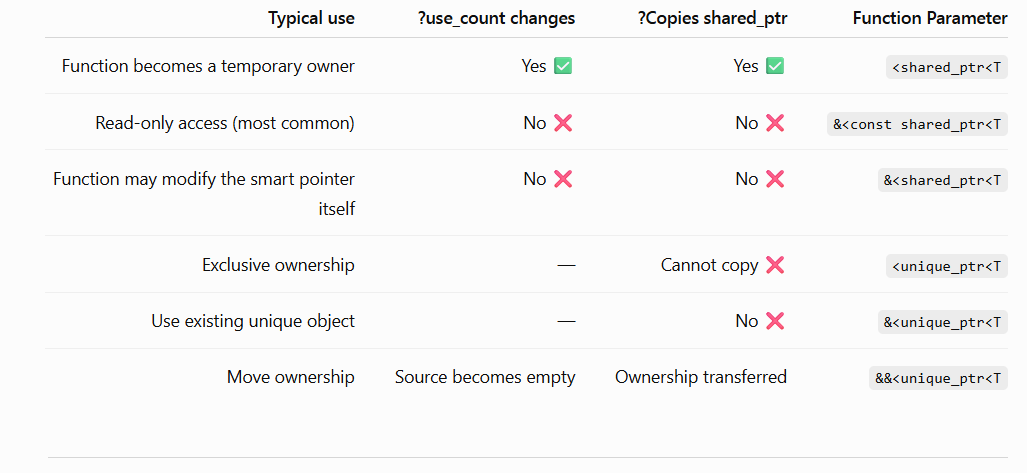

## **const**

**Why do we need it?**

Protect objects from accidental modification and improve code clarity.

**What is it?**

Declares something as read-only.

**Example**

**Common Mistakes**

* Forgetting const
* Misunderstanding const int* vs int* const

**SLAM Example**


In [ ]:
const Frame&

**Key Takeaways**

Const improves safety.

**const with pointers** (const int*, int* const, const int* const)

**Const Rule (Golden Rule ⭐)**

**const** applies to the thing immediately on its left. If there is nothing on the left, it applies to the thing on its right.

Examples:

In [ ]:
const int* p      // const applies to int

In [ ]:
int* const p      // const applies to pointer

In [ ]:
const int* const p    // both are const

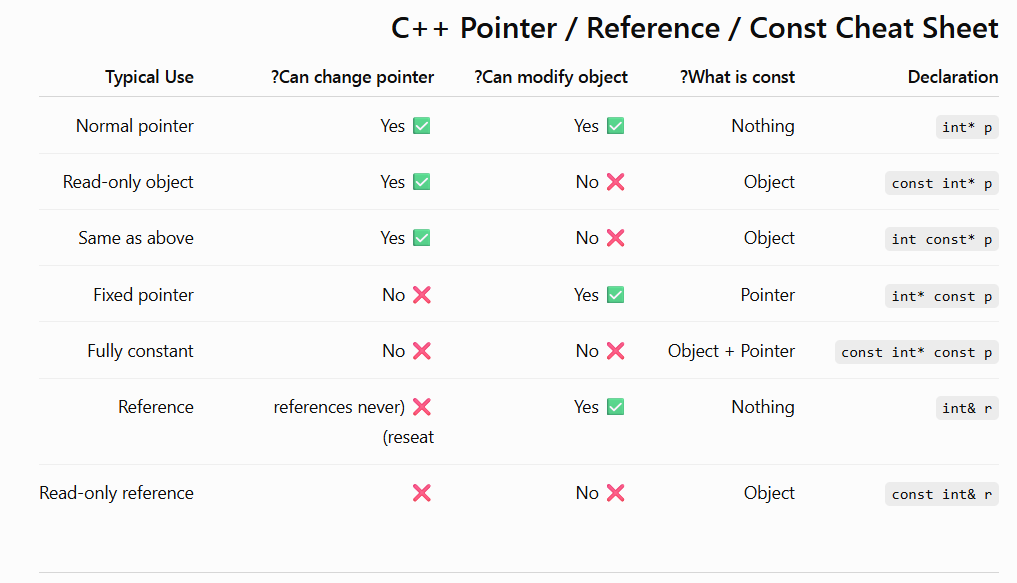

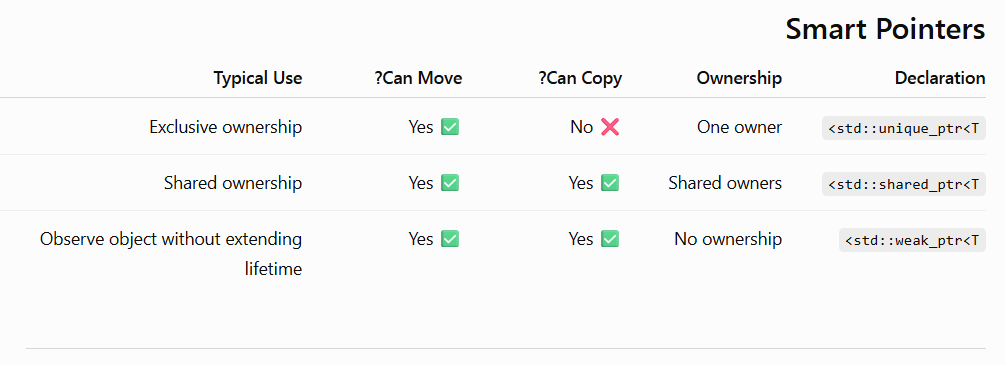

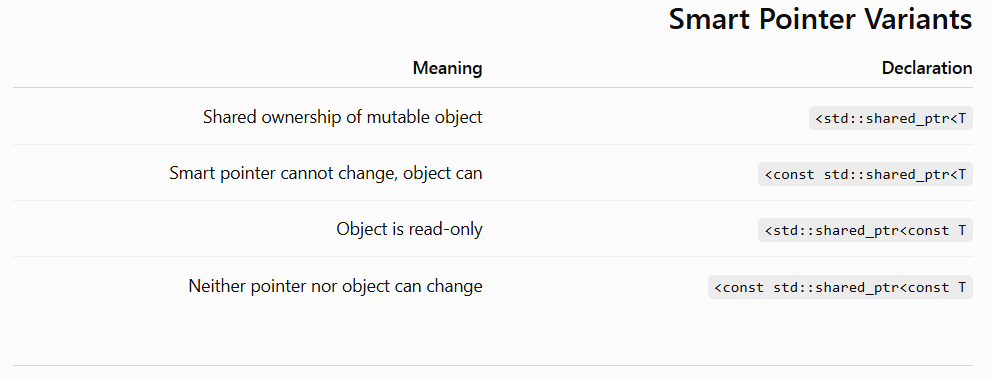

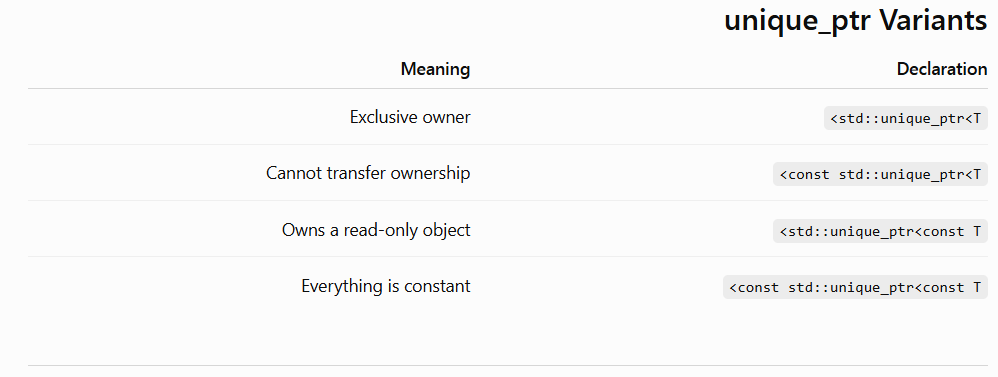

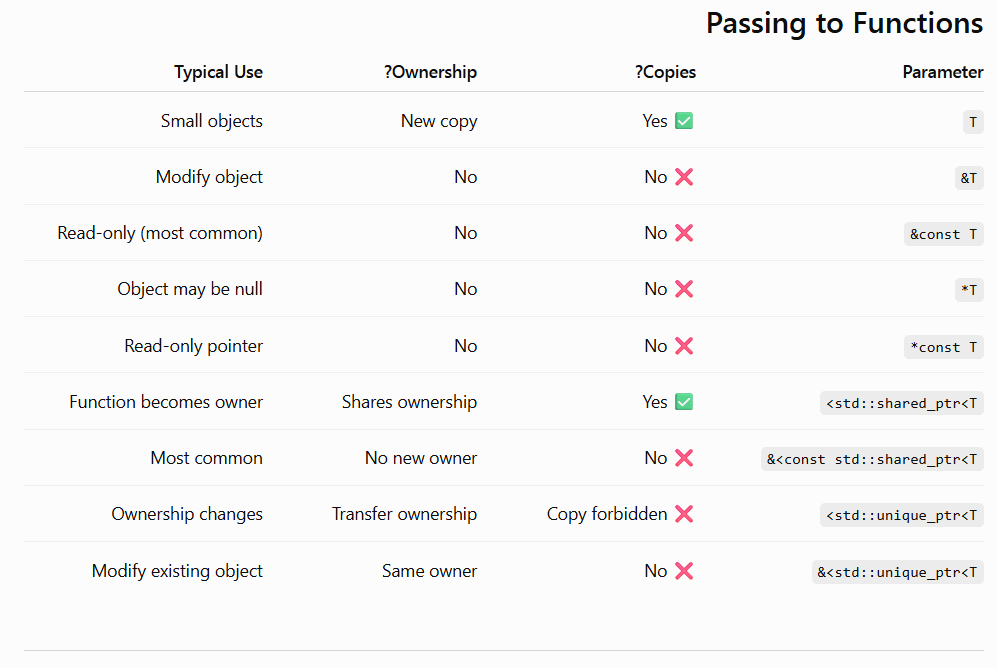

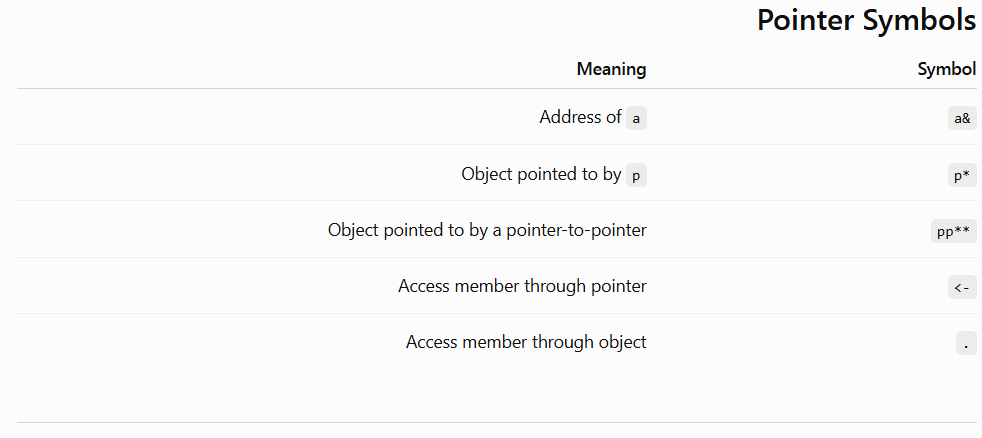

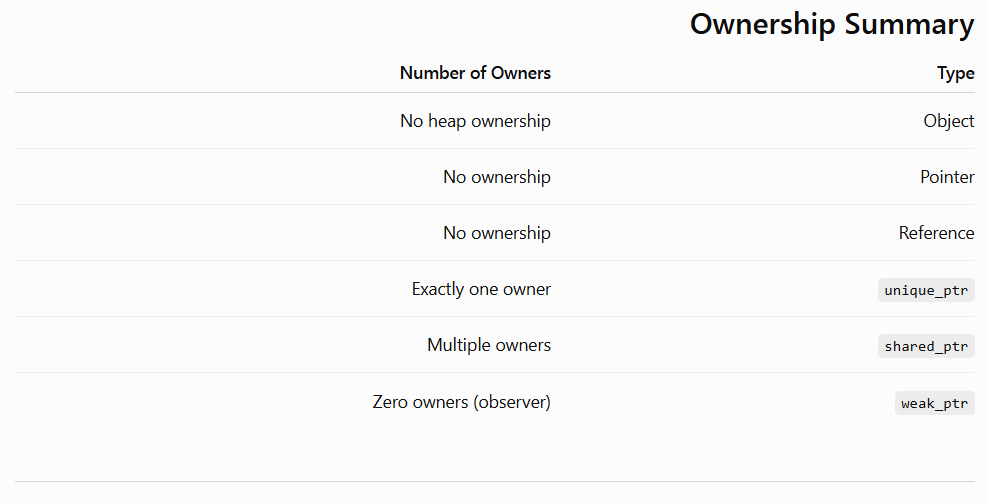

## **Template**

**Why do we need it?**

Write one implementation that works with multiple types.

**What is it?**

Templates allow generic programming.

**Syntax**

**Example**

**Common Mistakes**

* Thinking templates duplicate code manually
* Forgetting that templates are instantiated at compile time

**SLAM Example**


In [ ]:
std::vector<Frame::Ptr>

**Key Takeaways**

Templates increase code reuse.

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

instead of:

In [ ]:
int maxInt(int a, int b)
{
    return (a > b) ? a : b;
}

# and

float maxDouble(float a, float b)
{
    return (a > b) ? a : b;
}

and

double maxFloat(double a, double b)
{
    return (a > b) ? a : b;
}

SyntaxError: invalid syntax (3669784019.py, line 1)

We have:

In [ ]:
template<typename T>
T maximum(T a, T b)
{
    return (a > b) ? a : b;
}

**Important point in SLAM:**

All these in the following are **Template**

In [ ]:
std::vector<int>

In [ ]:
Template

In [ ]:
std::vector<MapPoint::Ptr>

In fact, all of them are applyiong the same class:

In [ ]:
template<typename T>
class vector
{
    ...
};

And, In the same way:

In [ ]:
std::shared_ptr<Frame>

is deriving from

In [ ]:
template<typename T>
class shared_ptr
{
    ...
};

**Question:**

In [ ]:
std::vector<Frame::Ptr>

* What is 'vector'?
* What is 'Frame::Ptr'?
* Here, what is the value of 'T'?
* What is stored into the 'vector'?

* A Class Template
* Frame::Ptr is a Type
* T = Frame::Ptr
* std::shared_ptr<Frame>

In [ ]:
frames

+---------------------------+
| shared_ptr<Frame>         | -----> Frame #0
+---------------------------+

| shared_ptr<Frame>         | -----> Frame #1
+---------------------------+

| shared_ptr<Frame>         | -----> Frame #2
+---------------------------+

### **Exercise T1 — Function Template (Warm-up)**

**Goal**

Learn how one function works for multiple data types.

**Task**

Write a function template

In [ ]:
maximum(...)

that returns the larger value.

Test it with

In [ ]:
int
float
double

In [ ]:
%%writefile main.cpp

#include <iostream>
using namespace std;

template <typename T> T myMax(T x, T y){
    return (x > y) ? x : y;
}

int main(){

    cout << "Max of 3 and 7 is: " << myMax<int>(3, 7) << endl;
    cout << "Max of 3.5 and 7.5 is :" << myMax<double>(3.5, 7.5) << endl;
    cout << "Max of 'g' and 'e' is: " << myMax<char>('g', 'e') << endl;

    return 0;
}


Writing main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

Max of 3 and 7 is: 7
Max of 3.5 and 7.5 is :7.5
Max of 'g' and 'e' is: g


**⭐ Note**

You do not need to specify the template type explicitly.

Instead of

In [ ]:
myMax<int>(3,7);

you can simply write

In [ ]:
myMax(3,7);

The compiler automatically deduces that

In [ ]:
T = int

This feature is called **Template Argument Deduction**.

### **Exercise T2 — Template Class Reading**

Without writing any code, explain the meaning of

In [ ]:
std::vector<int>

std::vector<Pose>

std::vector<Frame::Ptr>

std::shared_ptr<Map>

std::unordered_map<long, Frame::Ptr>

Describe

* Template class
* Template parameter(s)
* Stored object

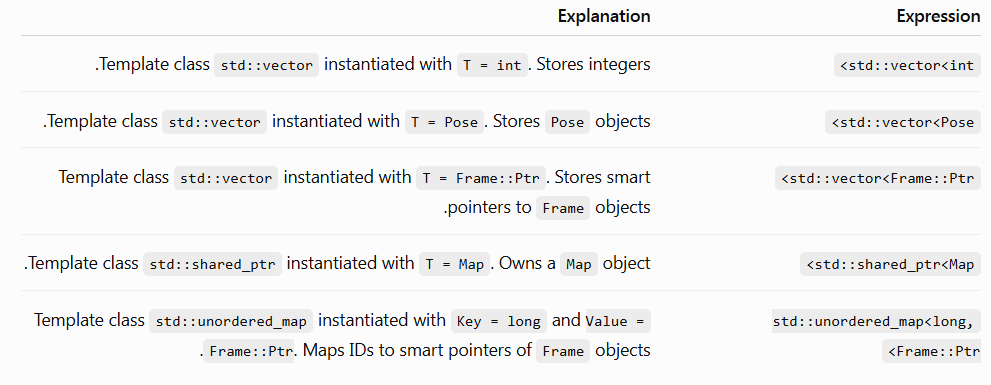

In [ ]:
std::vector<Frame::Ptr>   // A vector of shared pointers to Frame.
# vs.
std::shared_ptr<Map>      // A shared pointer that manages one Map object.

In [ ]:
vector
 ├── shared_ptr<Frame>
 ├── shared_ptr<Frame>
 ├── shared_ptr<Frame>
 └── ...

vs.

In [ ]:
shared_ptr
      │
      ▼
     Map

**For Example:**

In [ ]:
class Frontend
{
private:
    Map::Ptr map_;
};

and in the Map we have:

In [ ]:
using Ptr = std::shared_ptr<Map>;

So, they are equivalent

In [ ]:
Map::Ptr map_;
# and
std::shared_ptr<Map> map_;
#  in main
auto map = std::make_shared<Map>();
#  then
frontend->SetMap(map);
# and in SetMap
void Frontend::SetMap(Map::Ptr map)
{
    map_ = map;
}


Who owns **Map**?

In [ ]:
main
  │
  ▼
shared_ptr
  │
  ├──────────────┐
  ▼              ▼
Map        Frontend::map_

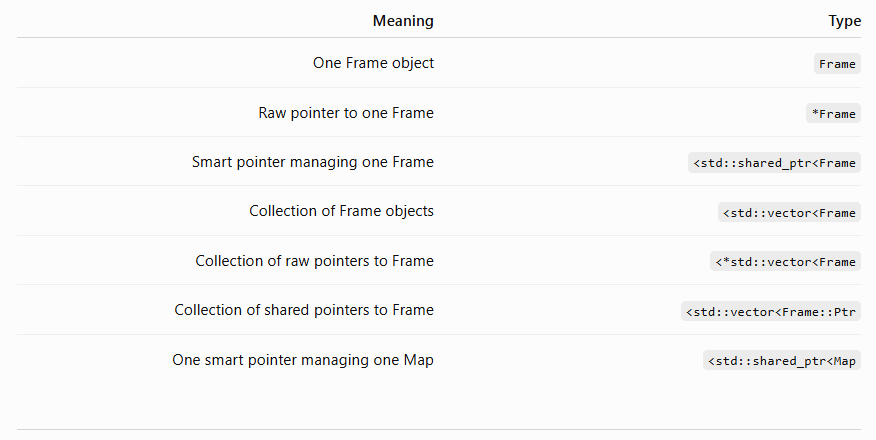

### **Exercise T3 — Build a Tiny Template Class**

Create

In [ ]:
template<typename T>

class Holder

Requirements

In [ ]:
Store one object

set()

get()

Test it with

In [ ]:
int

float

Pose

In [ ]:
%%writefile holder.h

#pragma once

template<typename T>
class Holder
{
public:

    Holder();

    void set(const T& value);

    T get() const;

private:

    T value_;
};

With No **holder.cpp**.

**Why?**

Because templates are special.

The compiler must see the entire implementation when it generates code.

Therefore we usually implement template classes inside the header file.

This is one of the biggest differences between

* normal classes

and

* template classes.

We'll explain why later.

In [ ]:
%%writefile holder.h

#pragma once

template<typename T>
class Holder
{
public:

    Holder();

    void set(const T& value);

    T get() const;

private:

    T value_;
};


template<typename T>
Holder<T>::Holder()
{
}

template<typename T>
void Holder<T>::set(const T& value)
{
    value_ = value;
}

template<typename T>
T Holder<T>::get() const
{
    return value_;
}

Writing holder.h


In [ ]:
%%writefile main.cpp

#include <iostream>
#include "holder.h"

using namespace std;

struct Pose
{
    float x;
    float y;
};

int main()
{
    Holder<int> h1;
    h1.set(25);

    Holder<float> h2;
    h2.set(3.14f);

    Holder<Pose> h3;

    Pose p;
    p.x = 10;
    p.y = 20;

    h3.set(p);

    cout << h1.get() << endl;

    cout << h2.get() << endl;

    cout << h3.get().x << " "
         << h3.get().y << endl;

    return 0;
}

**⭐ What You Learn**

In [ ]:
Exercise T3 — Template Class

Goal:
Learn how to write a simple class template.

New Concepts:
• Class templates
• Template implementation in header files
• Using template classes with built-in and user-defined types
• const reference parameters
• Generic programming

### **Exercise T4 — SLAM Example**

Create

In [ ]:
Holder<Frame::Ptr>

Explain

* What does Holder store?
* Who owns the Frame?
* Is copying allowed?

1. Pointer to Frame

A more precise answer is:

Holder stores one std::shared_ptr<Frame> object.

or

Holder stores one Frame::Ptr.

2. Ownership is shared.

Holder is one of the owners.

In [ ]:
main
   │
   ▼
shared_ptr ------------+
                       |
                       ▼
                    Frame
                       ▲
                       |
Holder.value_ ---------+

There are now **two shared_ptr objects** pointing to the same Frame.

Therefore:

**Holder shares ownership of the Frame.**

3. Yes, because shared_ptr is used.

For example,

In [ ]:
Holder<Frame::Ptr> h2 = h1;

copies

In [ ]:
Frame::Ptr

which increases the reference count.

The Frame itself is not copied.

Only the smart pointer is copied.

## **STL**

**Why do we need it?**

Provides efficient, reusable data structures and algorithms.

The STL gives us ready-made data structures and algorithms.

The most important ones here are:

In [ ]:
vector
   ↓
ordered collection

map
   ↓
key → value

unordered_map
   ↓
key → value, fast lookup

set
   ↓
unique sorted values

iterator
   ↓
walk through a container

algorithms
   ↓
sort, find, remove, ...

**What is it?**

The Standard Template Library.

**Common Mistakes**

* Using the wrong container
* Ignoring iterator invalidation

**SLAM Example**


In [ ]:
vector

map

unordered_map

set

**Key Takeaways**

Choose the right container for the task.

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

### **Part A — vector**

#### **Exercise V1**

Store several robot poses

In [ ]:
Pose

Pose

Pose

inside

In [ ]:
std::vector<Pose>

Print every pose.

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <vector>
using namespace std;

struct Pose
{
    float x;
    float y;
};

// Create a vector called robotPoses that will store Poses
// means: Create a dynamic array that stores Pose objects
std::vector<Pose> robotPoses;


int main()
{
    for (int i = 0; i < 4; i++)
    {
      Pose p;
      cin >> p.x;
      cin >> p.y;
      robotPoses.push_back(p);
      // cout << p.x << " " << p.y << "\n";
    }

    cout << "*************************************"  << endl;
    cout << "\nRobot Poses:\n";

    for (Pose robotPose : robotPoses)
    {
      cout << robotPose.x << " "
     << robotPose.y << endl;
    }


    return 0;
}

Overwriting main.cpp


OR

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <vector>
using namespace std;

struct Pose
{
    float x;
    float y;
};

// Create a vector called robotPoses that will store Poses
std::vector<Pose> robotPoses;


int main()
{
    for (int i = 0; i < 4; i++)
    {
      Pose p;
      cin >> p.x;
      cin >> p.y;
      robotPoses.push_back(p);
      // cout << p.x << " " << p.y << "\n";
    }

    cout << "*************************************"  << endl;
    cout << "\nRobot Poses:\n";


    for (const Pose& robotPose : robotPoses)
    {
        cout << robotPose.x << " "
            << robotPose.y << endl;
    }


    return 0;
}

Overwriting main.cpp


OR More (Professional)

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <vector>

using namespace std;

struct Pose
{
    float x;
    float y;
};

int main()
{
    vector<Pose> robotPoses;

    while (true)
    {
        cout << "Enter x y (or q to quit): ";

        float x, y;

        if (!(cin >> x))
            break;

        if (!(cin >> y))
            break;

        robotPoses.emplace_back(Pose{x, y});
    }

    cout << "\nRobot poses:\n";

    for (const Pose& p : robotPoses)
    {
        cout << "(" << p.x << ", " << p.y << ")\n";
    }

    return 0;
}

In [ ]:
!g++ main.cpp -o out
!./out

1 2
12 2
58 33
4654 54
*************************************

Robot Poses:
1 2
12 2
58 33
4654 54


#### **Exercise V2**

Store

In [ ]:
Frame::Ptr

inside

In [ ]:
std::vector

Print each Frame ID.

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <memory>
#include <vector>

using namespace std;

class Frame
{
public:

    using Ptr = shared_ptr<Frame>;

    Frame(int id)
        : id_(id)
    {}

    int getID() const
    {
        return id_;
    }

private:

    int id_;
};

int main()
{
    vector<Frame::Ptr> frames;

    frames.emplace_back(make_shared<Frame>(10));
    frames.emplace_back(make_shared<Frame>(20));
    frames.emplace_back(make_shared<Frame>(30));

    cout << "Frame IDs\n";

    for (const Frame::Ptr& frame : frames)
    {
        cout << frame->getID() << endl;
    }

    return 0;
}

#### **Exercise V3**

Implement

In [ ]:
findFrameByID(...)

using a vector.

In [ ]:
Frame::Ptr findFrameByID(
    const std::vector<Frame::Ptr>& frames,
    long id)
{
    for (const Frame::Ptr& frame : frames)
    {
        if (frame->Id() == id)
        {
            return frame;
        }
    }

    return nullptr;
}

Usage:

In [ ]:
Frame::Ptr frame = findFrameByID(frames, 3);

if (frame)
{
    std::cout << "Found Frame "
              << frame->Id()
              << std::endl;
}
else
{
    std::cout << "Frame not found." << std::endl;
}

Why const&?

This:

In [ ]:
const std::vector<Frame::Ptr>& frames

means:

Give me the vector without making a copy, and I promise not to modify it.

This is a very useful C++ pattern.

### **Part B — map**

#### **Exercise M1**

Create

In [ ]:
std::map<int, Pose>

Insert

In [ ]:
Robot 1

Robot 2

Robot 3

Retrieve Robot 2.

In [ ]:
%%writefile main.cpp


#include <iostream>
#include <map>

using namespace std;

struct Pose
{
    float x;
    float y;
};

int main()
{
    map<int, Pose> robots;

    robots.emplace(1, Pose{10,20});
    robots.emplace(2, Pose{5,8});
    robots.emplace(3, Pose{0,-2});

    Pose robot2 = robots[2];

    cout << "Robot 2\n";

    cout << robot2.x << " "
         << robot2.y << endl;

    return 0;
}

or

In [ ]:
for (const auto& robot : robots)
{
    cout << robot.first
         << " -> "
         << robot.second.x
         << " "
         << robot.second.y
         << endl;
}

#### **Exercise M2**

Explain

In [ ]:
Key

Value

Lookup

using your own words.

The **key** identifies the object.

The **value** is the data associated with the key.

**Lookup** means: Search for a value using its key.

### **Part C — unordered_map**

#### **Exercise U1**

Implement

In [ ]:
std::unordered_map<long, Frame::Ptr>

Insert

5 Frames.

Retrieve Frame #3.

In [ ]:
#include <iostream>
#include <memory>
#include <unordered_map>

class Frame
{
public:

    using Ptr = std::shared_ptr<Frame>;

    Frame(long id)
        : id_(id)
    {
    }

    long Id() const
    {
        return id_;
    }

private:

    long id_;
};

int main()
{
    std::unordered_map<long, Frame::Ptr> frames;

    frames[1] = std::make_shared<Frame>(1);
    frames[2] = std::make_shared<Frame>(2);
    frames[3] = std::make_shared<Frame>(3);
    frames[4] = std::make_shared<Frame>(4);
    frames[5] = std::make_shared<Frame>(5);

    Frame::Ptr frame = frames[3];

    if (frame)
    {
        std::cout << "Frame ID = "
                  << frame->Id()
                  << std::endl;
    }

    return 0;
}

#### **Exercise U2**

Implement

In [ ]:
std::unordered_map<long, MapPoint::Ptr>

Explain why SLAM uses an unordered_map instead of a vector.

The important idea is:

A vector is good when we mainly care about sequential storage. An unordered_map is useful when we frequently need to find objects by their IDs.

This is one reason it fits SLAM databases very naturally.

For example:

**Imagine we have:**

std::vector<Frame::Ptr> frames;

**and we want Frame #5000.**

We may need to search through the vector:

1
2
3
4
5
...
5000

**But with:**

std::unordered_map<long, Frame::Ptr>

we can **directly** use:

frames[5000]*italicized text*

### **Part D — set**

#### **Exercise S1**

Store KeyFrame IDs

In [ ]:
3

8

3

2

8

inside

In [ ]:
std::set<int>

Explain the output.

In [ ]:

#include <iostream>
#include <set>

int main()
{
    std::set<int> keyframe_ids;

    keyframe_ids.insert(3);
    keyframe_ids.insert(8);
    keyframe_ids.insert(3);
    keyframe_ids.insert(2);
    keyframe_ids.insert(8);

    for (int id : keyframe_ids)
    {
        std::cout << id << std::endl;
    }

    return 0;
}

**Output:**

2

3

8

**Beacause:**

A set has two important properties:

1. No duplicates
2. Sorted order

**SO:**

A set is useful when we care about uniqueness of KeyFrame IDs.

#### **Exercise S2**

Explain why a set is useful for KeyFrame IDs.

### **Part E — Iterators**

#### **Exercise I1**

Print every Frame

using

In [ ]:
iterator

In [ ]:
for (
    std::vector<Frame::Ptr>::iterator it = frames.begin();
    it != frames.end();
    ++it)
{
    std::cout << "Frame ID = "
              << (*it)->Id()
              << std::endl;
}

**The important pieces:**

frames.begin()

**means:**

Iterator pointing to the first element.

**And:**

frames.end()

**means:**

**Iterator pointing just after the last element.**

**And:**

++it

**moves to the next element.**

**Why** (*it)->Id()?

**Because:**

it

**is an iterator.**

**So:**

*it

**gives us the element:**

Frame::Ptr

**Then:**

(*it)->Id()

**uses the shared_ptr to access the Frame.**

#### **Exercise I2**

Print every Frame

using

In [ ]:
range-based for

Explain the difference.

In [ ]:
for (const Frame::Ptr& frame : frames)
{
    std::cout << "Frame ID = "
              << frame->Id()
              << std::endl;
}

Much cleaner.

**Difference**

**Iterator version:** gives you direct control over the iterator.

**Range-based version:** is simpler when you just want to process every element.

**In modern C++**

You'll usually prefer: unless you specifically need iterator operations.

### **Part F — Algorithms**

#### **Exercise A1**

Sort robot poses by x coordinate.

In [ ]:
#include <algorithm>

std::sort(
    poses.begin(),
    poses.end(),
    [](const Pose& a, const Pose& b)
    {
        return a.x < b.x;
    }
);

#### **Exercise A2**

Sort KeyFrames by ID.

In [ ]:
struct KeyFrame
{
    int id;
};

Then

In [ ]:
std::sort(
    keyframes.begin(),
    keyframes.end(),
    [](const KeyFrame& a, const KeyFrame& b)
    {
        return a.id < b.id;
    }
);

Again

In [ ]:
a.id < b.id

means ascending order.

#### **Exercise A3**

Find the first Frame whose ID equals 5.

In [ ]:
auto it = std::find_if(
    frames.begin(),
    frames.end(),
    [](const Frame::Ptr& frame)
    {
        return frame->Id() == 5;
    }
);

Then

In [ ]:
if (it != frames.end())
{
    std::cout << "Found Frame 5." << std::endl;
}
else
{
    std::cout << "Frame 5 not found." << std::endl;
}

#### **Exercise A4**

Remove every Pose whose

In [ ]:
x < 0

In [ ]:
poses.erase(
    std::remove_if(
        poses.begin(),
        poses.end(),
        [](const Pose& pose)
        {
            return pose.x < 0;
        }
    ),
    poses.end()
);

This is called the erase-remove idiom.

The logic is roughly:

In [ ]:
remove_if
    ↓
move unwanted elements toward the end
    ↓
erase
    ↓
actually remove them from the vector

You don't need to memorize the mechanics yet. Just recognize the pattern.

### **Final Mini Project - Implement a tiny SLAM database**

In [ ]:
Frame

MapPoint

Map



Requirements

In [ ]:
Map stores Frames

Map stores MapPoints

Insert()

Find()

Remove()

Print()


Use

In [ ]:
vector

unordered_map

shared_ptr

iterator

const&

Now let's combine everything.

We want:

In [ ]:
             Map
          /       \
       Frames    MapPoints

We'll use:

In [ ]:
vector
unordered_map
shared_ptr
iterator
const&

**frame.h**

In [ ]:
#pragma once

#include <memory>

class Frame
{
public:

    using Ptr = std::shared_ptr<Frame>;

    Frame(long id)
        : id_(id)
    {
    }

    long Id() const
    {
        return id_;
    }

private:

    long id_;
};

**mappoint.h**

In [ ]:
#pragma once

#include <memory>

class MapPoint
{
public:

    using Ptr = std::shared_ptr<MapPoint>;

    MapPoint(long id)
        : id_(id)
    {
    }

    long Id() const
    {
        return id_;
    }

private:

    long id_;
};

**map.h**

Here is where the STL containers come together:

In [ ]:
#pragma once

#include <iostream>
#include <memory>
#include <unordered_map>
#include <vector>

#include "frame.h"
#include "mappoint.h"

class Map
{
public:

    using Ptr = std::shared_ptr<Map>;

    void InsertFrame(Frame::Ptr frame)
    {
        frames_.push_back(frame);
    }

    void InsertMapPoint(MapPoint::Ptr map_point)
    {
        map_points_[map_point->Id()] = map_point;
    }

    Frame::Ptr FindFrame(long id) const
    {
        for (const Frame::Ptr& frame : frames_)
        {
            if (frame->Id() == id)
            {
                return frame;
            }
        }

        return nullptr;
    }

    MapPoint::Ptr FindMapPoint(long id) const
    {
        auto it = map_points_.find(id);

        if (it != map_points_.end())
        {
            return it->second;
        }

        return nullptr;
    }

    void RemoveMapPoint(long id)
    {
        map_points_.erase(id);
    }

    void Print() const
    {
        std::cout << "Frames:" << std::endl;

        for (const Frame::Ptr& frame : frames_)
        {
            std::cout << "  Frame "
                      << frame->Id()
                      << std::endl;
        }

        std::cout << "MapPoints:" << std::endl;

        for (auto it = map_points_.begin();
             it != map_points_.end();
             ++it)
        {
            std::cout << "  MapPoint "
                      << it->first
                      << std::endl;
        }
    }

private:

    std::vector<Frame::Ptr> frames_;

    std::unordered_map<long, MapPoint::Ptr> map_points_;
};

**main.cpp**

In [ ]:
#include <iostream>
#include <memory>

#include "map.h"

int main()
{
    auto map = std::make_shared<Map>();

    // Insert Frames
    map->InsertFrame(
        std::make_shared<Frame>(1)
    );

    map->InsertFrame(
        std::make_shared<Frame>(2)
    );

    map->InsertFrame(
        std::make_shared<Frame>(3)
    );

    // Insert MapPoints
    map->InsertMapPoint(
        std::make_shared<MapPoint>(100)
    );

    map->InsertMapPoint(
        std::make_shared<MapPoint>(200)
    );

    map->InsertMapPoint(
        std::make_shared<MapPoint>(300)
    );

    // Print
    map->Print();

    // Find Frame
    auto frame = map->FindFrame(2);

    if (frame)
    {
        std::cout << "Found Frame: "
                  << frame->Id()
                  << std::endl;
    }

    // Find MapPoint
    auto map_point = map->FindMapPoint(200);

    if (map_point)
    {
        std::cout << "Found MapPoint: "
                  << map_point->Id()
                  << std::endl;
    }

    // Remove MapPoint
    map->RemoveMapPoint(200);

    std::cout << "\nAfter removing MapPoint 200:\n";

    map->Print();

    return 0;
}

**🧠 The important architecture**

Look at what we've built:

In [ ]:
                    Map
                     │
          ┌──────────┴──────────┐
          │                     │
          ▼                     ▼
       vector              unordered_map
          │                     │
          ▼                     ▼
   Frame::Ptr              MapPoint::Ptr

Why different containers?

**Frames**

In [ ]:
std::vector<Frame::Ptr>

We're storing Frames as a collection.

**MapPoints**

In [ ]:
std::unordered_map<long, MapPoint::Ptr>

We have IDs and frequently want:

In [ ]:
FindMapPoint(id)

So the ID becomes the key.

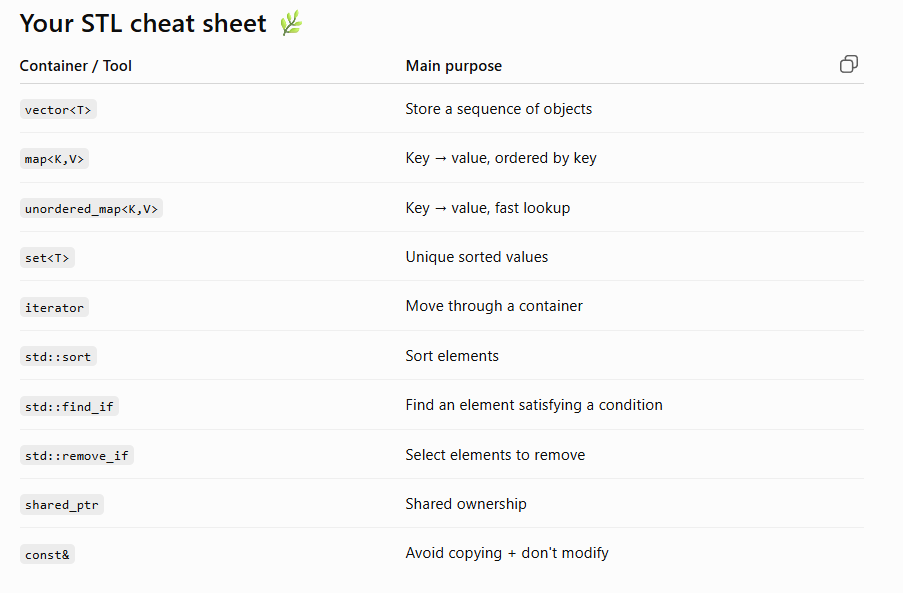

And the SLAM mental model:

In [ ]:
Frame IDs / MapPoint IDs
          ↓
       containers
          ↓
 ┌────────┴─────────┐
 │                  │
vector        unordered_map
 │                  │
Frames          MapPoints

**The biggest thing to understand in this module isn't memorizing STL syntax.**

It's learning to ask:

**"How am I going to access this data?"**

If the answer is **sequentially** → vector is often natural.

If the answer is by **ID/key** → unordered_map is often natural.

If the answer is **I need unique values** → set is often natural.

## **argv (argument vector)**

In [ ]:
int main(int argc, char** argv)
{
    ...
}

# argc → how many?
# argv → what are they?

# Example:
# ./app hello world
# argc = 3
# argv[0] → "./app"
# argv[1] → "hello"
# argv[2] → "world"


In [ ]:
        argv
          ↓
┌───────────────┐
│ argv[0]       │ → "./app"
├───────────────┤
│ argv[1]       │ → "hello"
├───────────────┤
│ argv[2]       │ → "world"
└───────────────┘

argc = 3

In [ ]:
char** argv

argv
 ↓
char* → "./app"
char* → "hello"
char* → "world"

**Why do we need it?**

Programs often need input from the command line.

**What is it?**

argv stores command-line arguments.

**Syntax**

**Example**

**Common Mistakes**

* Forgetting to check argc
* Accessing argv[1] without validation

In [ ]:
argc → number of command-line arguments INCLUDING argv[0]

argv → array of command-line arguments

argv[0] → program name/path

argv[1] → first user-provided argument

argv[2] → second user-provided argument
...

In [ ]:
int main(int argc, char** argv)

**Means:**

**"Give me the number of command-line arguments and the arguments themselves."**

**SLAM Example**


In [ ]:
./run_slam config.yaml

**Key Takeaways**

Always validate user input.

**Interview Questions**

In [ ]:
# تمرین‌ها:

# چاپ argc
# چاپ تمام argv
# خواندن dataset_path
# خواندن config.yaml
# شبیه‌سازی run_slam vocabulary.yml config.yaml

# آخرش دقیقاً همون کدی رو می‌فهمی که توی MySLAM دیدیم:

In [ ]:
Dataset::Ptr ds(new Dataset(argv[1]));

### **A1 — Warm-up**

Run the following

Print **argc**
Print all **argv**s in a loop

In [ ]:
./app hello world SLAM

In [ ]:
%%writefile  main.cpp

#include <iostream>
using namespace std;

int main(int argc, char* argv[])     // == int main(int argc, char** argv)
{
    // 1. چاپ تعداد آرگومان‌ها
    cout << "argc = " << argc << endl << endl;

    // 2. چاپ تمام argv ها
    cout << "Arguments:" << endl;

    for (int i = 0; i < argc; i++)
    {
        cout << "argv[" << i << "] = " << argv[i] << endl;
    }

    return 0;
}

Overwriting main.cpp


./app hello world SLAM

or in colab

In [ ]:
!g++ main.cpp -o app
!./app hello world SLAM

argc = 4

Arguments:
argv[0] = ./app
argv[1] = hello
argv[2] = world
argv[3] = SLAM


### **A2 — Read a Dataset Path from the Command Line ⭐**

Now let's do exactly what we see in real SLAM projects.

Suppose we want to run:

In [ ]:
./app /home/niki/dataset

The program should read the dataset path from the command line.

Write a program that:

1. Checks whether the user provided a dataset path

If not, print:

In [ ]:
Usage: ./app <dataset_path>

and return -1.

2. If the dataset path exists

Store:

In [ ]:
argv[1]

inside:

In [ ]:
std::string dataset_path;

3. Print the dataset path

For example:

In [ ]:
Dataset path: /home/niki/dataset

But your program will have this general logic:

In [ ]:
Start
  │
  ▼
Check argc
  │
  ├── argc < 2
  │      │
  │      ▼
  │   Print Usage
  │   return -1
  │
  ▼
Read argv[1]
  │
  ▼
Store it in dataset_path
  │
  ▼
Print dataset_path
  │
  ▼
End

In [ ]:
%%writefile  main.cpp

#include <iostream>
#include <string>
using namespace std;


int main(int argc, char* argv[])     // == int main(int argc, char** argv)
{
    if(argc < 2)
    {
      cout << "Usage: ./out <dataset_path>\n";
      return -1;
    }
    string dataset_path = argv[1];

    cout << "Dataset Path: " << dataset_path << endl;

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

Usage: ./out <dataset_path>


In [ ]:
!g++ main.cpp -o out
!./out /home/user/dataset

Dataset Path: /home/user/dataset


**Real SLAM Connection 🌿**

This:

In [ ]:
std::string dataset_path = argv[1];

### **A3 — Multiple Command-Line Arguments ⭐**

Now let's make it more similar to a real SLAM application.

Suppose the program is executed like this:

In [ ]:
./out config.yaml dataset_path

Then

In [ ]:
argv[0] → ./out
argv[1] → config.yaml
argv[2] → dataset_path

and

In [ ]:
argc = 3

Your Task

Write a program that:

1. Checks whether exactly two user-provided arguments exist

The program needs:

* a configuration file
 a dataset path

So if the user does not provide enough arguments, print:

In [ ]:
Usage: ./out <config_file> <dataset_path>

and return -1.

2. Store the arguments in:

In [ ]:
std::string config_file;
std::string dataset_path;

3. Print both values

Expected output:

In [ ]:
Config file: config.yaml
Dataset path: /home/niki/dataset

In [ ]:
%%writefile  main.cpp

#include <iostream>
#include <string>
using namespace std;


int main(int argc, char* argv[])     // == int main(int argc, char** argv)
{
    if(argc < 3)
    {
      cout << "Usage: ./out <config_file> <dataset_path>\n";
      return -1;
    }

    std::string config_file = argv[1];
    std::string dataset_path = argv[2];

    cout << "Config file: " << config_file << endl;
    cout << "Dataset Path: " << dataset_path << endl;

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

Usage: ./out <config_file> <dataset_path>


In [ ]:
!g++ main.cpp -o out
!./out config.yaml dataset_path

Config file: config.yaml
Dataset Path: dataset_path


* argc = number of command-line arguments
* argv = command-line arguments
* argv[0] = program name/path
* argv[1] = first user argument
* argv[2] = second user argument
* Always check argc before accessing argv[i]
* argv[i] can be stored in a std::string
* Real SLAM programs often use argv for:

  1 dataset paths
  
  2 configuration files
  
  3 vocabulary files

For example, when you later see:

In [ ]:
if (argc != 3) {
    std::cerr << "Usage: ./run_slam config.yaml dataset_path" << std::endl;
    return -1;
}

std::string config_file = argv[1];
std::string dataset_path = argv[2];

## **Dependency Injection**

**Why do we need it?**

Reduce coupling between classes and improve flexibility, testing, and maintainability.

**What is it?**

Objects receive their dependencies instead of creating them internally.

**Syntax**

**Example**

**Common Mistakes**

* Creating dependencies inside constructors
* Tight coupling

**SLAM Example**


In [ ]:
SetMap()

SetCamera()

**Key Takeaways**

Inject dependencies instead of creating them.

**Interview Questions**

In [ ]:
# این بخش رو خیلی دوست دارم.

# چون تازه می‌فهمی چرا توی SLAM همه جا می‌بینی:

# SetMap()

# SetBackend()

# SetCamera()

# SetFrontend()

# تمرین‌ها:

# Constructor Injection
# Setter Injection
# مثال واقعی از Frontend و Backend
# طراحی یک Mini SLAM

**1. First: What is a Dependency?**

Suppose we have a Frontend.

The Frontend needs a Map to work.

In [ ]:
Frontend ────── needs ──────► Map

So we say:

**Frontend depends on Map.**

Here, Map is a dependency of Frontend.

Another example:

In [ ]:
Backend ────── needs ──────► Map

Again:

**Map is a dependency of Backend.**

And maybe:

In [ ]:
Frontend ────── needs ──────► Camera

So Camera is also a dependency of Frontend.

**2. The Big Question**

Imagine this:

In [ ]:
class Frontend
{
public:
    Frontend()
    {
        map_ = std::make_shared<Map>();
    }

private:
    std::shared_ptr<Map> map_;
};

Here, Frontend creates **its own Map**.

So the relationship is:

In [ ]:
Frontend
    │
    │ creates
    ▼
   Map

This works.

But it creates a problem:

Frontend is now responsible for creating the Map.

And what if we want the **same Map** to be shared with:

In [ ]:
Frontend
    │
    ├──────► Map ◄──────┤
    │                    │
    │                    │
    ▼                    ▼
Camera?               Backend

We don't want every module to create its own separate Map.

For example, this would be bad:

In [ ]:
Frontend → Map A

Backend  → Map B

because now they are working with different maps. 😱

**3. Dependency Injection**

Instead of this:

* "Frontend, go and create the Map you need."

We do this:

* "Here, Frontend. I already have a Map. Use this one."

That is the basic idea of **Dependency Injection**.

In [ ]:
Someone creates Map
        │
        ▼
      Map
        │
        │ injected into
        ▼
    Frontend

In one sentence:

**Dependency Injection means providing an object with the dependencies it needs instead of letting it create those dependencies itself.**

⭐ This is the most important definition.

**4. The Simplest Example**

Without Dependency Injection:

In [ ]:
class Robot
{
public:
    Robot()
    {
        pose_ = std::make_shared<Pose>();
    }

private:
    std::shared_ptr<Pose> pose_;
};

Robot creates its own Pose.

With Dependency Injection:

In [ ]:
class Robot
{
public:
    void SetPose(std::shared_ptr<Pose> pose)
    {
        pose_ = pose;
    }

private:
    std::shared_ptr<Pose> pose_;
};

Now:

In [ ]:
auto pose = std::make_shared<Pose>();

Robot robot;

robot.SetPose(pose);

The relationship becomes:

In [ ]:
main()
  │
  │ creates
  ▼
Pose
  │
  │ injects
  ▼
Robot

Robot did not create the Pose.

It received it from outside.

That is Dependency Injection. 🎯

**5. Why Do We Need It?**

There are several important reasons.

**A. Shared Dependencies**

One object can be used by multiple modules.

In [ ]:
              ┌──► Frontend
              │
Map ──────────┼──► Backend
              │
              └──► Viewer

All modules can access the **same Map.**

**B. Less Coupling**

Without DI:

Frontend
    ↓
must know how to create
    ↓
Map

With DI:

In [ ]:
Frontend
    ↓
only knows
    ↓
"I need a Map."

It does not care who created it or where it came from.

This is called **loose coupling.**

**C. More Flexibility**

Today:

In [ ]:
Frontend → Real Map

Tomorrow, maybe for testing:

In [ ]:
Frontend → Test Map

The Frontend does not need major changes.

**6. The Important Part: DI Is Not About Pointers**

This is something I really want you to remember. ⭐

Dependency Injection can use:

In [ ]:
Map

or

In [ ]:
Map&

or

In [ ]:
Map*

or

In [ ]:
std::shared_ptr<Map>

DI itself is **not a pointer feature.**

The important idea is:

* **The dependency comes from outside.**

For example, all of these can represent Dependency Injection.

**By Reference**

In [ ]:
class Frontend
{
public:
    Frontend(Map& map)
        : map_(map)
    {
    }

private:
    Map& map_;
};

**By Raw Pointer**

In [ ]:
class Frontend
{
public:
    void SetMap(Map* map)
    {
        map_ = map;
    }

private:
    Map* map_;
};

**By Smart Pointer**

In [ ]:
class Frontend
{
public:
    void SetMap(std::shared_ptr<Map> map)
    {
        map_ = map;
    }

private:
    std::shared_ptr<Map> map_;
};

The syntax is different.

But the core idea is the same:

In [ ]:
Map is created outside
        ↓
Map is given to Frontend
        ↓
Frontend uses Map

**7. Two Important Types of Dependency Injection**

For our purposes, these two are enough.

**1. Constructor Injection**

The dependency is given when the object is created.

In [ ]:
class Backend
{
public:
    Backend(std::shared_ptr<Map> map)
        : map_(map)
    {
    }

private:
    std::shared_ptr<Map> map_;
};

Usage:

In [ ]:
auto map = std::make_shared<Map>();

Backend backend(map);

The dependency exists from the beginning.

In [ ]:
Create Map
    ↓
Create Backend(Map)
    ↓
Backend is ready

**2. Setter Injection**

The object is created first.

The dependency is provided later.

In [ ]:
class Backend
{
public:
    void SetMap(std::shared_ptr<Map> map)
    {
        map_ = map;
    }

private:
    std::shared_ptr<Map> map_;
};

Usage:

In [ ]:
Backend backend;

auto map = std::make_shared<Map>();

backend.SetMap(map);

The flow is:

In [ ]:
Create Backend
      ↓
Create Map
      ↓
SetMap(map)
      ↓
Backend can use Map

This should look very familiar from MySLAM. 😏

**8. Real SLAM Connection 🌿**

Imagine the main SLAM system:

In [ ]:
auto map = std::make_shared<Map>();

auto frontend = std::make_shared<Frontend>();
auto backend = std::make_shared<Backend>();

Now inject the same Map:

In [ ]:
frontend->SetMap(map);
backend->SetMap(map);

Visually:

In [ ]:
                  Map
                 /   \
                /     \
               ▼       ▼
         Frontend     Backend

Both modules now use the same Map object.

This is exactly the kind of architecture we have been encountering in MySLAM.

**9. One Very Important Connection to Our Previous Exercise**

Remember this:

In [ ]:
private:
    Pose* pose_;

and

In [ ]:
void Tracker::setPose(Pose* p)
{
    pose_ = p;
}

Then:

In [ ]:
Pose P;

Tracker tracker;

tracker.setPose(&P);

You were asking:

* Why don't we simply write Pose pose_;?

Now you can see one architectural reason.

If we write:

In [ ]:
private:
    Pose pose_;

then Tracker owns its own Pose.

But with:

In [ ]:
private:
    Pose* pose_;

and

In [ ]:
tracker.setPose(&P);

we can say:

* "Tracker, don't create another Pose. Here is the Pose you should use."

🎯 That is also the basic idea of **Setter Dependency Injection.**

**Your First Mental Model**

Whenever you see:

In [ ]:
SetMap(...)

ask:

* **Who created the Map?**

Then:

* **Who receives the Map?**

Then:

* **Why are they using the same Map instead of creating another one?**

For example:

In [ ]:
frontend->SetMap(map);

Answer:

In [ ]:
Who created it?
→ Some external object, often the SLAM system/main.

Who receives it?
→ Frontend.

What happens?
→ Frontend stores and uses the provided Map.

Why?
→ So Frontend does not need to create its own Map,
  and multiple modules can potentially work with the same Map.

**A dependency is an object that another class needs in order to perform its job. Dependency Injection means providing that dependency from outside instead of creating it inside the class. This reduces coupling, improves flexibility, and allows multiple modules to share the same object.**

### **DI1 — Identify the Dependency**



Read the examples and answer the questions.

#### **Example 1**

In [ ]:
class Frontend
{
public:
    void SetMap(std::shared_ptr<Map> map)
    {
        map_ = map;
    }

private:
    std::shared_ptr<Map> map_;
};

**Questions**


**Q1.** What is the dependency of Frontend?

The dependency of Frontend is Map.

Because Frontend needs a Map to perform its job.

**Q2.** Which object receives the dependency?

Frontend receives the dependency.

In [ ]:
Map
 ↓
is given to
 ↓
Frontend

Frontend receives a Map.

**Q3.** Is the Map created inside Frontend?

No. The Map is provided from outside.

**Q4.** What type of Dependency Injection is used here?

Setter Injection

Because the dependency is provided through: setMap()


#### **Example 2**

In [ ]:
class Backend
{
public:
    Backend(std::shared_ptr<Map> map)
        : map_(map)
    {
    }

private:
    std::shared_ptr<Map> map_;
};

**Questions**



**Q1.** What is the dependency of Backend?


Map is the dependency of Backend.


**Q2.** When does Backend receive its dependency?



The dependency is given when the Backend object is created.


**Q3.** What type of Dependency Injection is used here?



Constructor Injection.


**Q4.** What does this part do?

It initializes the member variable map_ with the constructor parameter map.

In [ ]:
: map_(map)

#### **Example 3**

In [ ]:
class Frontend
{
public:
    Frontend()
    {
        map_ = std::make_shared<Map>();
    }

private:
    std::shared_ptr<Map> map_;
};

**Questions**



**Q1.** Does Frontend need a Map to do its job?


Yes. Frontend needs a Map to do its job, but it creates the Map itself.

**Q2.** Who creates the Map?

Choose one:

Frontend
An external object


Frontend

**Q3.** Is Dependency Injection being used here? Why or why not?

No. Dependency Injection is not used because Frontend creates its own Map instead of receiving a Map from outside.

The same Map can be created outside and injected into multiple modules.

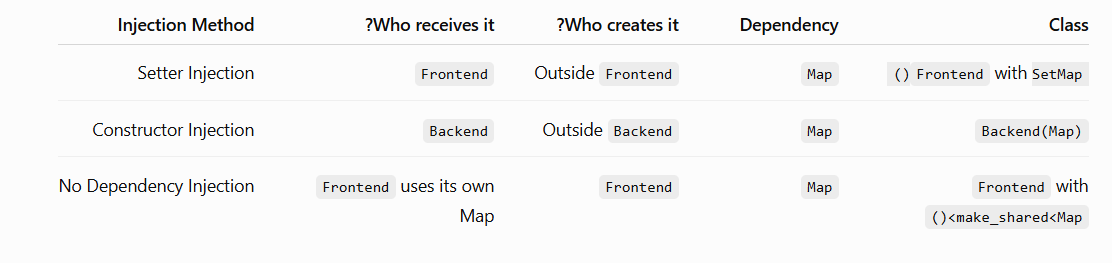

### **DI2 — Without Dependency Injection**

A small class that creates its own dependency.


**What does a class do when it creates its own dependency?**

**Scenario**

We have two classes:

Map **&** Frontend

Frontend needs a Map.

But instead of receiving a Map from outside, Frontend will create its own Map.

**The relationship will be:**

In [ ]:
Frontend
   │
   │ creates
   ▼
  Map

Your Task

**Write three files:**

map.h

frontend.h

main.cpp

No .cpp files are needed yet because everything can be very small for now.

**Step 1 — map.h**

Create a simple Map class.

It should have one function:

In [ ]:
void PrintInfo() const;

The function should print:

**This is the Map.**

You can implement the function directly inside the class for this exercise.

In [ ]:
%%writefile map.h

#pragma once
#include <iostream>

class Map
{
public:

    void PrintInfo() const
    {
        std::cout << "This is the Map." << std::endl;
    }
};

Overwriting map.h


**Step 2 — frontend.h**

Create a Frontend class.

It should contain:

In [ ]:
private:
    std::shared_ptr<Map> map_;

Its constructor should create its own Map:

In [ ]:
map_ = std::make_shared<Map>();

So your constructor will be something like:

In [ ]:
Frontend()
{
    ...
}

Add another function:

In [ ]:
void UseMap() const;

Inside it, call:

In [ ]:
map_->PrintInfo();

**Small hint** if you forget the headers 😏

Your frontend.h will need access to both:

Map

and:

std::shared_ptr

So think:

Which headers do I need to include?

In [ ]:
%%writefile frontend.h

#include "map.h"
#include <memory>

class Frontend
{
public:

    Frontend()
    {
        map_ = std::make_shared<Map>();
    }

    void UseMap() const
    {
        map_->PrintInfo();
    }

private:
    std::shared_ptr<Map> map_;
};

Overwriting frontend.h


**Step 3 — main.cpp**

Create a Frontend object:

In [ ]:
Frontend frontend;

Then call:

In [ ]:
frontend.UseMap();

Expected output:

**This is the Map.**

In [ ]:
%%writefile main.cpp

#include "frontend.h"

int main()
{
    Frontend frontend;

    frontend.UseMap();

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

This is the Map.


Important Questions — answer after running it

**Q1.**

What is the dependency of Frontend?

The dependency of Frontend is Map.

**Q2.**

Who creates the Map?

Frontend

**Q3.**

Who owns the Map?

**Hint:** Look at:

In [ ]:
std::shared_ptr map_;

Don't overthink this one—we're connecting it to your Smart Pointer knowledge.

The Map is managed by a std::shared_ptr. In this example, Frontend holds the only shared owner.

shared_ptr means that ownership can be shared, not that it is necessarily shared by multiple objects at every moment.

**Q4.**

Is Dependency Injection used here? Why?



No

Dependency Injection is not used because Frontend creates its own Map internally instead of receiving it from an external object.

**std::shared_ptr is a mechanism for managing a pointer and shared ownership of an object, whereas Dependency Injection is a design technique in which a class receives the dependencies it needs from outside.**

In [ ]:
shared_ptr
→ How is an object's lifetime/ownership managed?

Dependency Injection
→ How does an object receive the other objects it needs?


### **DI3 — Setter Injection**

Rewrite it so the dependency is injected through Set...().



**Goal**

Modify the previous example so that Frontend does not create its own Map.

Instead:

In [ ]:
An external object creates the Map
            ↓
The Map is injected into Frontend
            ↓
Frontend uses the Map

**Files**

In [ ]:
map.h
frontend.h
main.cpp

**map.h**

You can reuse the same Map class from DI2:

In [ ]:
#pragma once

#include <iostream>

class Map
{
public:
    void PrintInfo() const
    {
        std::cout << "This is the Map." << std::endl;
    }
};

**Your Task — frontend.h**

Create a Frontend class with:

**1. A member variable**

In [ ]:
std::shared_ptr<Map> map_;

**2. A setter function**

In [ ]:
void SetMap(std::shared_ptr<Map> map);

Inside this function, store the received Map in map_.

**3. A UseMap() function**

In [ ]:
void UseMap() const;


It should call:

In [ ]:
map_->PrintInfo();

**Important**

In this exercise, Frontend must not contain:

In [ ]:
std::make_shared<Map>()

because Frontend should not create the dependency.italicized text

**Your Task — main.cpp**

Create the Map outside Frontend:

In [ ]:
auto map = std::make_shared<Map>();

Then
1. Create the Map.
2. Create Frontend.
3. Inject the Map using SetMap().
4. Call UseMap().

Expected output:

This is the Map.

In [ ]:
main
 │
 │ creates
 ▼
 Map
 │
 │ SetMap()
 ▼
Frontend
 │
 │ uses
 ▼
 Map

In [ ]:
%%writefile map.h

#pragma once

#include <iostream>

class Map
{
public:

    void PrintInfo() const
    {
        std::cout << "This is the Map." << std::endl;
    }
};

In [ ]:
%%writefile frontend.h

#pragma once

#include <memory>
#include "map.h"

class Frontend
{
public:

    void SetMap(std::shared_ptr<Map> map)
    {
        map_ = map;
    }

    void UseMap() const
    {
        map_->PrintInfo();
    }

private:

    std::shared_ptr<Map> map_;
};

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <memory>

#include "map.h"
#include "frontend.h"

int main()
{
    // 1. Create the Map
    auto map = std::make_shared<Map>();

    // 2. Create Frontend
    Frontend frontend;

    // 3. Inject Map into Frontend
    frontend.SetMap(map);

    // 4. Use the Map
    frontend.UseMap();

    return 0;
}

In [ ]:
!g++ main.cpp -o out
!./out

**Questions**

**Q1.** What is the dependency of Frontend?


Map

because Frontend needs a Map in order to perform:

map_->PrintInfo();

**Q2.** Who creates the Map?


main() creates it.

**Q3.** Which object receives the dependency?


Map

**Q4.** What type of Dependency Injection is used?


Setter Injection

**Q5.** Why is this different from DI2?


So Frontend only uses the Map.

It doesn't create it.

That's the central idea of Dependency Injection:

The class receives what it needs instead of creating what it needs itself.

**Q6.** What happens if UseMap() is called before SetMap()?

Think about this carefully:

In [ ]:
std::shared_ptr<Map> map_;

What is its value before it receives a valid Map?

Because map_ is a default-initialized member of type std::shared_ptr<Map>, it is initially:

nullptr

So if we do:

Frontend frontend;

frontend.UseMap();

then inside UseMap():

map_->PrintInfo();

we are effectively trying to do:

nullptr -> PrintInfo()

That's invalid.

The program will typically crash / have undefined behavior.

To protect it

In [ ]:
void UseMap() const
{
    if (map_)
    {
        map_->PrintInfo();
    }
}

In [ ]:
             creates
main ──────────────────► Map
 │                        │
 │                        │
 │       injects          │
 └───────────────────────►│
          SetMap()        │
                          ▼
                      Frontend
                          │
                          │ uses
                          ▼
                         Map

In [ ]:
Map
 │
 └── provides functionality

main
 │
 └── creates the dependency

Frontend
 │
 └── receives and uses the dependency

### **DI4 — Constructor Injection**

Inject the dependency through the constructor.



**Goal**

Now inject the Map through the constructor.

The relationship should be:

In [ ]:
main()
  │
  ├── creates Map
  │
  └── gives Map to Frontend constructor
                 │
                 ▼
              Frontend

**Files**

map.h

frontend.h

main.cpp

You can reuse map.h.

**Your Task — frontend.h**

Create this structure:

In [ ]:
class Frontend
{
public:
    Frontend(std::shared_ptr<Map> map);

    void UseMap() const;

private:
    std::shared_ptr<Map> map_;
};

Implement the constructor using an initializer list.

The important part should look like:

In [ ]:
Frontend(std::shared_ptr<Map> map)
    : ...
{
}

Your job is to complete the ....

Remember:

In [ ]:
member variable ← constructor parameter

**Your Task — main.cpp**

Create the Map first:

In [ ]:
auto map = std::make_shared<Map>();

Then create Frontend and give it the Map during construction.

Finally:

In [ ]:
frontend.UseMap();

Expected output:

This is the Map.

In [ ]:
%%writefile map.h

#pragma once

#include <iostream>

class Map
{
public:

    void PrintInfo() const
    {
        std::cout << "This is the Map." << std::endl;
    }
};

In [ ]:
%%writefile frontend.h

#pragma once

#include <memory>
#include "map.h"

class Frontend
{
public:

    Frontend(std::shared_ptr<Map> map)
        : map_(map)
    {
    }

    void UseMap() const
    {
        map_->PrintInfo();
    }

private:

    std::shared_ptr<Map> map_;
};

In [ ]:
%%writefile main.cpp

#include <memory>

#include "map.h"
#include "frontend.h"

int main()
{
    // Create the dependency
    auto map = std::make_shared<Map>();

    // Inject Map through the constructor
    Frontend frontend(map);

    // Use Map
    frontend.UseMap();

    return 0;
}

In [ ]:
!g++ main.cpp -o out
!./out

**Questions**


**Q1.** What is the dependency of Frontend?


Map

**Q2.** Who creates the Map?


Main

**Q3.** When does Frontend receive the dependency?


The Map is passed directly to the Frontend constructor.

**Q4.** What type of Dependency Injection is used?


Constructor Injection

**Q5.** Explain this line:

In [ ]:
: map_(map)

Use this format:

In [ ]:
map_ = ...
map  = ...

Then explain the relationship between them.

In [ ]:
map_ = member variable
map  = constructor parameter

In [ ]:
: map_(map)

Initialize the member variable map_ with the Map received through the constructor parameter map.

In [ ]:
Outside
   │
   │ map
   ▼
Frontend constructor
   │
   │ map_(map)
   ▼
Frontend
   │
   └── map_

**Q6. Compared with Setter Injection, what is one advantage of Constructor Injection?**

Hint: Think about whether the object can exist without receiving its required dependency.

With Constructor Injection, the Frontend cannot be normally constructed without providing its required Map.

For example:

Frontend frontend(map);

is valid.

But:

Frontend frontend;

is not valid because we don't have a default constructor.

This helps guarantee that a Frontend always has the dependency it requires.

With Setter Injection:

Frontend frontend;

is possible, and then:

frontend.SetMap(map);

must happen later.

So Constructor Injection makes the required dependency more explicit and helps prevent an incompletely initialized object.

### **DI5 — Mini SLAM Architecture ⭐**

Map, Frontend, and Backend sharing dependencies.

This one is the important one. 😎🌿

Now we will build a tiny SLAM-style architecture.

We have:

In [ ]:
Map
Frontend
Backend

Both Frontend and Backend need the **same** Map.

The architecture should look like this:

In [ ]:
                   main()
                      │
                      │ creates
                      ▼
                     Map
                    /   \
                   /     \
          injects /       \ injects
                 ▼         ▼
            Frontend     Backend
                 │         │
                 └────┬────┘
                      │
                  same Map

**Files**

In [ ]:
map.h
frontend.h
backend.h
main.cpp

**Step 1 — map.h**

Create:

In [ ]:
class Map
{
public:
    void PrintInfo() const;
};

PrintInfo() should print:

I am the shared SLAM Map.

You can implement it directly inside the class.

**Step 2 — frontend.h**

Create a Frontend class.

It should contain:

In [ ]:
std::shared_ptr<Map> map_;

Use Setter Injection:

In [ ]:
void SetMap(std::shared_ptr<Map> map);

# and

void UseMap() const;

Its output should be:

**Frontend is using the Map:**

**I am the shared SLAM Map.**

So UseMap() can first print:

**Frontend is using the Map:**

and then call:

In [ ]:
map_->PrintInfo();

**Step 3 — backend.h**

Create a Backend class.

It should also contain:

In [ ]:
std::shared_ptr<Map> map_;

But this time use **Constructor Injection:**

In [ ]:
Backend(std::shared_ptr<Map> map)
    : map_(map)
{
}

# and

void UseMap() const;

Expected output:

**Backend is using the Map:**

**I am the shared SLAM Map.**

**Step 4 — main.cpp**

Your job is to create only one Map object:

In [ ]:
auto map = std::make_shared<Map>();

Then

1. Create one shared Map.
2. Create Frontend.
3. Inject the Map into Frontend using Setter Injection.
4. Create Backend.
5. Inject the SAME Map into Backend using Constructor Injection.
6. Call Frontend::UseMap().
7. Call Backend::UseMap().

Expected output:

**Frontend is using the Map:**

**I am the shared SLAM Map.**

.

**Backend is using the Map:**

**I am the shared SLAM Map.**

In [ ]:
                 main()
                   │
                   ▼
                  Map
                 /   \
                /     \
               ▼       ▼
          Frontend   Backend

In [ ]:
%%writefile map.h

#pragma once

#include <iostream>

class Map
{
public:

    void PrintInfo() const
    {
        std::cout << "I am the shared SLAM Map." << std::endl;
    }
};

Writing map.h


In [ ]:
%%writefile frontend.h

#pragma once

#include <iostream>
#include <memory>

#include "map.h"

class Frontend
{
public:

    void SetMap(std::shared_ptr<Map> map)
    {
        map_ = map;
    }

    void UseMap() const
    {
        std::cout << "Frontend is using the Map:" << std::endl;

        map_->PrintInfo();
    }

private:

    std::shared_ptr<Map> map_;
};

Writing frontend.h


In [ ]:
%%writefile backend.h

#pragma once

#include <iostream>
#include <memory>

#include "map.h"

class Backend
{
public:

    Backend(std::shared_ptr<Map> map)
        : map_(map)
    {
    }

    void UseMap() const
    {
        std::cout << "Backend is using the Map:" << std::endl;

        map_->PrintInfo();
    }

private:

    std::shared_ptr<Map> map_;
};

Writing backend.h


In [ ]:
%%writefile main.cpp

#include <memory>

#include "map.h"
#include "frontend.h"
#include "backend.h"

int main()
{
    // 1. Create ONE shared Map
    auto map = std::make_shared<Map>();

    // 2. Create Frontend
    Frontend frontend;

    // 3. Inject Map using Setter Injection
    frontend.SetMap(map);

    // 4. Create Backend
    // 5. Inject the SAME Map using Constructor Injection
    Backend backend(map);

    // 6. Frontend uses the Map
    frontend.UseMap();

    std::cout << std::endl;

    // 7. Backend uses the Map
    backend.UseMap();

    return 0;
}

Writing main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

Frontend is using the Map:
I am the shared SLAM Map.

Backend is using the Map:
I am the shared SLAM Map.


**DI5 — Questions ⭐**


**Q1.** How many Map objects are created?


One.

Because we only call:

std::make_shared<Map>()

once.

We don't have:

std::make_shared<Map>()

inside Frontend.

And we don't have:

std::make_shared<Map>()

inside Backend.

So:

Map objects = 1

**Q2.** How many std::shared_ptr<Map> objects exist after map has been injected into both modules?

Think about:

In [ ]:
auto map = std::make_shared<Map>();

# then

frontend.SetMap(map);

# and

Backend backend(map);

We have:

auto map = std::make_shared<Map>();

That's one shared_ptr.

Then:

frontend.SetMap(map);

The Frontend has its own shared_ptr member:

map_

And:

Backend backend(map);

The Backend also has:

map_

So conceptually we have three shared_ptr instances referring to the same Map:

In [ ]:
                    Map
                  /  |  \
                 /   |   \
                ▼    ▼    ▼
              map  Front  Back

However, there's an important detail: the constructor parameter in Backend is itself also a shared_ptr parameter:

Backend(std::shared_ptr<Map> map)

So while the constructor is executing, there is temporarily another shared_ptr copy.

After construction, the important long-lived owners are:

main's map
Frontend's map_
Backend's map_

So the practical answer for the objects that remain after construction is:

3 shared_ptr instances, all referring to the same Map.

And the reference count would normally be:

map.use_count()

equal to:

3

at that point.

**Q3.** Are Frontend and Backend using the same Map object or different Map objects?

Explain why.



Same Map. ✅

Because we created only one:

auto map = std::make_shared<Map>();

and passed that same pointer to both:

frontend.SetMap(map);

and:

Backend backend(map);

**Q4.** Which injection method is used by Frontend?


Setter Injection

**Q5.** Which injection method is used by Backend?


Constructor Injection

**Q6.** What is the advantage of this design compared with this one?

Frontend → creates Map A

Backend → creates Map B

Write your answer in your own words.

both modules need to work with the same SLAM state.

Imagine Map contains:

landmarks
keyframes
map points

If Frontend creates its own Map:

Frontend → Map A

and Backend creates another:

Backend → Map B

then the Frontend and Backend would be working with different maps.

That's not what we want in a typical SLAM architecture.

**Q7.** Complete this sentence:

Dependency Injection is especially useful in SLAM because different modules can receive and use __________ instead of creating __________.

**Dependency Injection is especially useful in SLAM because different modules can receive and use shared dependencies instead of creating their own dependencies.**

Or, more specifically for this exercise:

**Dependency Injection is especially useful in SLAM because different modules can receive and use the same Map instead of creating separate Map objects.**

### **Final Challenge**


After finishing all, try to explain this architecture in 4–6 sentences:

In [ ]:
main()
  │
  ▼
creates one Map
  │
  ├──────────────► Frontend
  │                 Setter Injection
  │
  └──────────────► Backend
                    Constructor Injection

Try to use these **words**:

dependency

inject

shared

Frontend

Backend

Map

**main() creates one shared Map object.**

**The Map is injected into the Frontend using Setter Injection.**

**The same Map is injected into the Backend using Constructor Injection.**

**Therefore, both the Frontend and Backend use the same shared Map dependency.**

**Dependency Injection prevents these modules from creating their own separate Map objects.**

## **Debugging**

**Why do we need it?**

Bugs are inevitable. Debugging helps locate, understand, and fix them efficiently.

**What is it?**

The process of inspecting program execution to identify errors.

**Syntax**

**Example**

**Common Mistakes**

* Relying only on std::cout
* Ignoring compiler warnings
* Debugging without understanding the bug

**SLAM Example**


Checking why tracking is lost, why a pointer is nullptr, or why Bundle Adjustment diverges.

**Key Takeaways**

* Use the debugger, not only print statements.
* Read compiler warnings carefully.
* Reproduce bugs before fixing them.

In [ ]:
# اینجا می‌خوایم مثل یک مهندس واقعی Debug کنیم.

# نه فقط cout.

# تمرین‌ها:

# assert
# LOG(INFO)
# LOG(ERROR)
# Debug Build
# gdb
# Breakpoint
# Backtrace
# Watch Variables

# و بعد یک Bug واقعی از SLAM رو با هم پیدا می‌کنیم.

This topic is extremely important for us because soon, when we're working inside SLAM code, debugging will not be a separate subject anymore—it will be part of our daily work.

We will learn it practically, not like a boring theory chapter. 😈

**Our Debugging Roadmap**

We will cover:

1. What is debugging?
2. Compiler errors vs runtime errors vs logical errors
3. std::cout / logging
4. Assertions: assert(...)
5. Debug builds vs Release builds
6. Basic gdb
    * compile with -g
    * break
    * run
    * next
    * step
    * print
    * backtrace
7. A small SLAM-style debugging exercise ⭐

We do not need to become gdb experts today. The goal is:

**When something goes wrong in a C++/SLAM project, you know how to investigate it systematically.**

In [ ]:
std::cout
→ Where am I? What are the values?

assert()
→ This MUST be true.

-g
→ Compile with debugging information.

gdb
→ Debugger: control and inspect execution.

break
→ Stop HERE.

run
→ Start execution.

next
→ Execute this line; don't enter function.

step
→ Execute this line; enter function.

print
→ What is this value?

backtrace / bt
→ How did the program get here?

### **1. What Is Debugging?**

Very simply:

**Debugging is the process of finding, understanding, and fixing problems in a program.**

The key word here is not just fixing.

A good debugging process is:

In [ ]:
Something is wrong
       ↓
Observe the problem
       ↓
Find where it happens
       ↓
Understand why it happens
       ↓
Fix the cause
       ↓
Verify the fix

This is especially important in SLAM.

For example:

In [ ]:
Camera trajectory looks wrong
        ↓
Where did the error start?
        ↓
Pose estimation?
Feature matching?
PnP?
Optimization?
Coordinate transformation?
        ↓
Inspect intermediate values
        ↓
Find the actual cause

So debugging is basically **structured investigation**. 🔍

### **2. Three Main Types of Errors**
A. Compile-Time Error

The program cannot be compiled.

Example:

In [ ]:
int main()
{
    int x = 10

    return 0;
}

We forgot:

;

The compiler tells us something is wrong.

**Example output**

error: expected ';' before 'return'

The program does not even start.

**B. Runtime Error**

The program compiles successfully, starts running, but fails while executing.

Example:

In [ ]:
int* p = nullptr;

std::cout << *p << std::endl;

The code may compile, but:

*p

tries to dereference a null pointer.

**💥 Runtime crash.**

In SLAM, a common conceptual example could be:

In [ ]:
current_frame_->pose_

when:

In [ ]:
current_frame_ == nullptr

**C. Logical Error**

This is the sneaky one 😈

The program:

compiles successfully
runs successfully
does not crash

But produces the wrong result.

Example:

In [ ]:
int add(int a, int b)
{
    return a - b;
}

Then:

std::cout << add(5, 3);

Output:

2

But we expected:

8

Nothing crashes.

The compiler sees no problem.

But our **algorithm is wrong.**

In SLAM, logical errors are extremely important.

For example:

Wrong coordinate transformation

Wrong pose composition

Wrong camera matrix

Wrong optimization edge

Wrong reprojection calculation

The program may run perfectly...

but your trajectory may look like a spaghetti monster 😂🍝

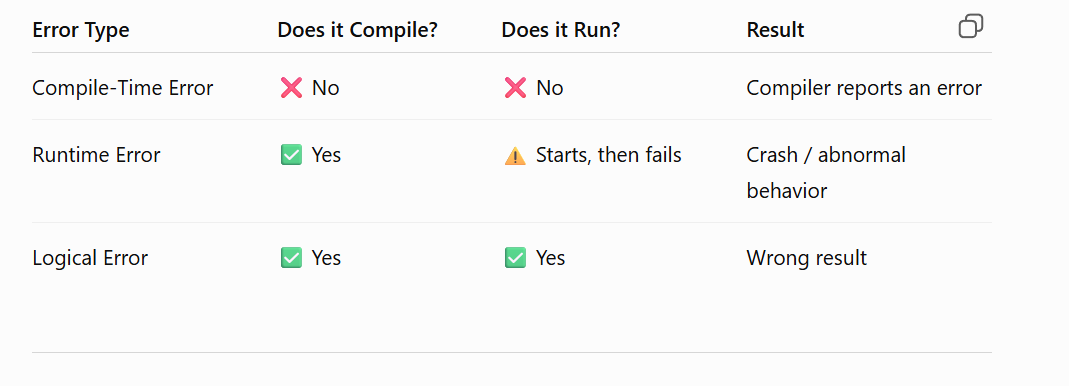

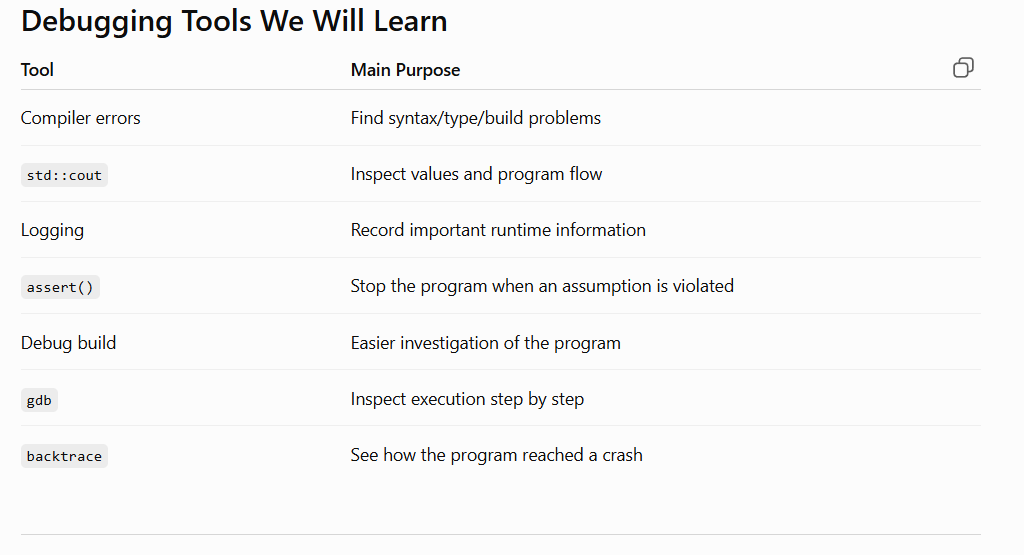

**Compile-time error** → compiler stops you before the program runs.

**Runtime error** → program compiles, but something goes wrong while running.

**Logical error** → program runs, but produces the wrong result.

### **D1 — First Debugging Exercise 🔍**

For now, let's start very small.

Read this code:

In [ ]:
#include <iostream>

int main()
{
    int x = 10;
    int y = 0;

    int result = x / y;

    std::cout << "Result = " << result << std::endl;

    return 0;
}

**Questions**

**Q1.** What type of error is this?

Choose one:

Compile-time error

Runtime error

Logical error

**Runtime error. ✅**

More precisely, the program attempts to perform integer division by zero while it is running.

**Q2.** Does the code compile successfully?

Yes. ✅

The compiler generally accepts:

int result = x / y;

because dividing integers is a valid C++ operation syntactically.

The problem occurs when the program actually executes the division with y == 0.

**Q3.** At which line does the problem happen?


int result = x / y;

**Q4.** Why does the problem happen?

Because division by zero is not valid for integer arithmetic.

**Q5.** Before fixing the problem, what could you print using std::cout to investigate the values?

Before the problematic line, we could print the values of both variables

### **D2 — std::cout Debugging**

**Goal**

Use std::cout to investigate program flow and variable values.

Consider:

In [ ]:
#include <iostream>

int main()
{
    int x = 10;
    int y = 5;

    std::cout << "Program started." << std::endl;

    int sum = x + y;

    std::cout << "Sum calculated." << std::endl;

    int result = sum / y;

    std::cout << "Result = " << result << std::endl;

    return 0;
}

**Questions**


**Q1.** What information does this print statement help us inspect?

std::cout << "Program started." << std::endl;

It helps us inspect program flow.

It tells us that execution has successfully reached this point.

So if we see:

Program started.

we know the program reached that line.

**Q2.** If the program crashes before printing:

Sum calculated.

Between which parts of the code should you investigate?

**We should investigate the code between these two points:**

std::cout << "Program started." << std::endl;

int sum = x + y;

std::cout << "Sum calculated." << std::endl;

**So we should investigate:**

int sum = x + y;

and the values of:

x
y:

**Q3.** Add std::cout statements to print the values of:

x
y
sum
result

Write the modified code.

In [ ]:
#include <iostream>

int main()
{
    int x = 10;
    int y = 5;

    std::cout << "Program started." << std::endl;

    std::cout << "x = " << x << std::endl;
    std::cout << "y = " << y << std::endl;

    int sum = x + y;

    std::cout << "sum = " << sum << std::endl;
    std::cout << "Sum calculated." << std::endl;

    int result = sum / y;

    std::cout << "result = " << result << std::endl;
    std::cout << "Result = " << result << std::endl;

    return 0;
}

The important debugging idea is:

Print → execute → print → execute

This lets us discover where execution stops and what the variables contained at that point.

### **D3 — Debugging Program Flow**

Goal

Use printed messages to find where execution stops.

Consider:

In [ ]:
#include <iostream>

void ProcessFrame()
{
    std::cout << "1. Entering ProcessFrame" << std::endl;

    int num_features = 100;

    std::cout << "2. Features detected" << std::endl;

    int matches = num_features / 0;

    std::cout << "3. Matching finished" << std::endl;
}

int main()
{
    std::cout << "A. Program started" << std::endl;

    ProcessFrame();

    std::cout << "B. Program finished" << std::endl;

    return 0;
}

**Questions**


**Q1.** Write the expected output until the program fails.


A. Program started
1. Entering ProcessFrame
2. Features detected



**Q2.** Which messages will never be printed?


3. Matching finished

B. Program finished

**Q3.** Where is the failure located?



In [ ]:
int matches = num_features / 0;

**Q4.** What does this exercise teach us about debugging with logging or std::cout?

std::cout can be used as a simple execution trace.

For example:

1. Entering ProcessFrame
2. Features detected
3. Matching finished

If we only see:

1. Entering ProcessFrame
2. Features detected

we immediately know execution stopped somewhere between message 2 and message 3.

This is extremely useful when debugging a large SLAM pipeline.

### **D4 — Assertions**

First, remember:

In [ ]:
#include <cassert>

An assertion means:

I believe this condition must be true at this point in the program.

Example:

In [ ]:
assert(y != 0);

If the condition is false, the program stops and reports an assertion failure.

Your Task

Consider:

In [ ]:
#include <iostream>
#include <cassert>

int main()
{
    int x = 10;
    int y = 0;

    assert(y != 0);

    int result = x / y;

    std::cout << result << std::endl;

    return 0;
}

**Questions**


**Q1.** Does the assertion pass or fail?


It fails.


**Q2.** Does the program reach:

In [ ]:
int result = x / y;

No.

The assertion stops the program before that line is executed.

**Q3.** Why can assert() be useful here?


Because it checks our assumption before the dangerous operation.

We are saying:

"At this point, I expect y to be non-zero."

If that assumption is wrong, the program stops immediately at the assertion instead of continuing toward the division by zero.

**Q4.** Complete this sentence:

An assertion checks whether __________. If the condition is false, __________.

An assertion checks whether **a condition is true**. If the condition is false, **the program stops and reports an assertion failure**.

### **D5 — SLAM-Style Assertion ⭐**

In [ ]:
void ProcessFrame(std::shared_ptr<Frame> frame)
{
    assert(frame != nullptr);

    std::cout << "Processing frame." << std::endl;

    // Continue processing...
}

**Questions**



**Q1.** What assumption is being checked?


The assumption is:

frame must point to a valid Frame object.

In other words:

frame != nullptr

must be true.


**Q2.** What happens if:

In [ ]:
frame == nullptr

The assertion fails and the program stops

**Q3.** Why is this better than immediately writing code that blindly uses:

In [ ]:
frame->...

Because:

frame->...

requires frame to point to a valid object.

If it is nullptr, accessing the object through -> can cause a runtime crash.

The assertion makes our assumption explicit and helps us detect the problem at the point where it occurs.

**Q4.** Complete:

Before processing the frame, the program verifies that __________.

Before processing the frame, the program verifies that the frame pointer is not null.

### **D6 — Debug Build vs Release Build**

Concept

Usually:

In [ ]:
Debug Build
→ easier to investigate
→ includes debugging information
→ often less optimized

In [ ]:
Release Build
→ optimized for performance
→ intended for normal/final execution

**Questions**



**Q1.** Which build type would you prefer while investigating a bug?


Debug Build. ✅


**Q2.** Which build type would you normally use for final performance testing?


Release Build. ✅

Because we usually want to measure the performance of the optimized program.

**Q3.** Why can a Debug build be easier to investigate?


Because it usually contains debugging information and uses less optimization, which makes it easier for tools such as gdb to show useful source-level information.


**Q4.** Complete:

A Debug build prioritizes __________, while a Release build prioritizes __________.

A Debug build prioritizes **debugging and investigation**, while a Release build prioritizes **performance and optimization**.

### **D7 — First gdb Session 🔍**

Suppose your program is:

In [ ]:
#include <iostream>

int Add(int a, int b)
{
    int result = a + b;
    return result;
}

int main()
{
    int x = 10;
    int y = 20;

    int sum = Add(x, y);

    std::cout << "Sum = " << sum << std::endl;

    return 0;
}

**Step 1 — Compile with debugging information**

g++ -g main.cpp -o app

**Q1.** What does -g do?

The -g option tells the compiler to include debugging information in the executable.

This allows gdb to connect things like:

In [ ]:
machine instructions
        ↓
source code
        ↓
line numbers
        ↓
variables

**Step 2 — Start gdb**

gdb ./app

**Q2.** What does this command do?

It starts the GNU Debugger (gdb) and loads the executable:

app

so we can investigate and control its execution.

**Step 3 — Set a breakpoint**

break main

**Q3.** What is a breakpoint?

A breakpoint tells the debugger:

Stop the program when execution reaches this location.

For example:

break main

means:

Stop when execution reaches main().

**Step 4 — Run the program**

run

**Q4.** What happens when the program reaches main?


The program starts running.

When it reaches the breakpoint at main, gdb pauses execution there.

So instead of the program immediately running to completion, we get control over it.

**Step 5 — Execute the next line**
next

**Q5.** What does next generally do?


next generally executes the current source line and moves to the next line.

An important point:

If the current line calls a function, next normally executes that function without stepping inside it.

We'll compare this with step in D8.

**Step 6 — Inspect a variable**

print x

**Q6.** What information does this show?

It shows the current value of variable x.

### **D8 — next vs step**

Use the same program:

In [ ]:
int Add(int a, int b)
{
    int result = a + b;
    return result;
}

int main()
{
    int x = 10;
    int y = 20;

    int sum = Add(x, y);

    return 0;
}

Suppose execution is stopped at:

In [ ]:
int sum = Add(x, y);

**Q1.** What generally happens if you use:

next


executes the current line without entering the implementation of Add().

So it moves past the function call.


**Q2.** What generally happens if you use:

step



can enter the function being called.

**Q3.** Which command would you choose if you want to inspect the internal execution of Add()?



step

because we want to enter the function.

**Q4.** Complete:

next generally executes the current line without entering __________, while step can enter __________.

next generally executes the current line without entering a function, while step can enter **a function**.

### **D9 — backtrace**

Consider:

In [ ]:
#include <iostream>

void FunctionC()
{
    int* p = nullptr;
    std::cout << *p << std::endl;
}

void FunctionB()
{
    FunctionC();
}

void FunctionA()
{
    FunctionB();
}

int main()
{
    FunctionA();

    return 0;
}

The call chain is:

In [ ]:
main()
  ↓
FunctionA()
  ↓
FunctionB()
  ↓
FunctionC()
  ↓
CRASH

After the crash, inside gdb, you run:

In [ ]:
backtrace

**Questions**



**Q1.** What information do you expect backtrace to show?

It shows the call stack — the sequence of function calls that led to the current location.

Something conceptually like:

* FunctionC()
* FunctionB()
* FunctionA()
* main()

**Q2.** Why is backtrace especially useful when a program crashes deep inside a large project?

Imagine your SLAM program contains:

In [ ]:
main
 ↓
SLAM
 ↓
Backend
 ↓
Optimizer
 ↓
PoseGraph
 ↓
FunctionC
 ↓
CRASH


You might not immediately know:

"How did I get here?"

backtrace helps answer exactly that.

It tells you the chain of function calls leading to the crash.

**Q3.** Put these functions in the expected order from the crash location back toward the original caller:

FunctionA
FunctionB
FunctionC
main

The crash occurs in:

FunctionC

Then its caller is:

FunctionB

then:

FunctionA

then:

main

So:

* FunctionC
* FunctionB
* FunctionA
* main

### **D10 — SLAM Debugging Scenario ⭐⭐⭐**

This is our final and most important debugging exercise.

Suppose your SLAM program runs, but suddenly crashes here:

In [ ]:
current_frame_->SetPose(pose);

You know that:

In [ ]:
std::shared_ptr<Frame> current_frame_;

is used.

**Questions**

**Q1.** What is one possible reason for the crash?



current_frame_ might be:

nullptr

Then:

current_frame_->SetPose(pose);

attempts to access a Frame through a null pointer.

**Q2.** Write one assert() statement you could add before this line.


In [ ]:
assert(current_frame_ != nullptr);

**Q3.** Write one std::cout statement that could help investigate the problem.


In [ ]:
std::cout << "current_frame_ is null: "
          << (current_frame_ == nullptr)
          << std::endl;

In [ ]:
std::cout << "About to set pose." << std::endl;

**Q4.** If you wanted to investigate this crash using gdb, what are two useful things you could do?

Choose from:

break
run
next
step
print
backtrace

Explain why you chose them.


**I'd choose:**

break
run

**or, after the crash:**

backtrace
print

**For this particular crash, a very useful sequence would be:**

break current_frame_->SetPose
run

**if the debugger can place the breakpoint appropriately, and then inspect the pointer with:**

print current_frame_

**After an actual crash, I'd especially want:**

backtrace

**because it tells us how we arrived at the crash.**

**So the two most useful commands after the crash are:**

backtrace
print current_frame_

**Q5.** Classify this problem:

Is it necessarily:

a compile-time error?
a runtime error?
a logical error?

Explain your answer.

This situation is a runtime error if the program actually crashes because current_frame_ is null.

It is not a compile-time error because the code can compile successfully.

There can also be a logical error behind it if the real problem is that somewhere earlier in the program we failed to initialize or assign current_frame_.

So:

Immediate crash → Runtime error
Underlying cause → potentially a logical/programming error

That's an important distinction.

### **Final Challenge — Debugging Strategy ⭐⭐⭐**

Write a short debugging strategy for this situation:

**My SLAM program compiles successfully, starts running, processes several frames, and then crashes.**

Try to use these words:

* reproduce
* output / logs
* values
* assert
* gdb
* backtrace
* cause
* fix

Aim for about 5–8 sentences in English.

**First**, I would reproduce the crash and identify the frame where the problem occurs.

**Then** I would add output or logs to inspect the program flow and the values of important variables.

**I** would use an assert to check important assumptions, such as whether a shared_ptr is null.

**If** the program still crashes, I would use gdb to stop at the problematic location and inspect the relevant variables.

**I** would use backtrace to see the function call chain that led to the crash.

**Then** I would use the information from the logs, values, assertions, and gdb to identify the actual cause.

**Finally**, I would fix the cause rather than only hiding the crash.

**What you will know after these exercises**

Once you finish these, you'll have a very practical foundation:

In [ ]:
Compiler error
     ↓
Read and fix build/type/syntax problems

Program crashes
     ↓
Inspect flow and values
     ↓
Add assertions
     ↓
Use gdb
     ↓
Check the backtrace

Program runs but results are wrong
     ↓
Investigate intermediate values
     ↓
Compare expected vs actual behavior
     ↓
Find the logical error

### **Debugging Example in a SLAM System**

Suppose a SLAM program crashes at:

In [ ]:
current_frame_->SetPose(pose);

A systematic debugging process could look like this.

**1. Check the Program Flow with std::cout**

First, add a message before the suspicious line:

In [ ]:
std::cout << "Before SetPose" << std::endl;

current_frame_->SetPose(pose);

std::cout << "After SetPose" << std::endl;

If the program prints:

Before SetPose

but never prints:

After SetPose

the problem is likely happening during the execution of:

current_frame_->SetPose(pose);

This helps us identify **where the program stops or crashes.**

**2. Check Important Assumptions with assert()**

Before dereferencing current_frame_, we expect it to point to a valid object:

In [ ]:
assert(current_frame_ != nullptr);

current_frame_->SetPose(pose);

This explicitly checks an important assumption:

current_frame_ must not be nullptr before calling SetPose().

If the condition is false, the assertion fails immediately, helping us detect the problem before blindly dereferencing an invalid pointer.

**3. Use gdb for More Detailed Investigation**

Compile the program with debugging information:

In [ ]:
g++ -g main.cpp -o app

Then start the debugger:

In [ ]:
gdb ./app

Suppose we want to investigate the tracking function:

In [ ]:
break Frontend::Track
run

The program will run and stop when it reaches Frontend::Track().

**4. Execute the Code Step by Step**

Use:

Use:

**next**

to execute the current line without entering called functions.

Use:

**step**

when we want to enter a function and investigate its internal execution.

For example, if the current line is:

**current_frame_->SetPose(pose);**

using step may allow us to enter SetPose() and inspect what happens inside it.

**5. Inspect Important Variables**

We can inspect the current value of a variable or pointer using:

print current_frame_

For example, this can help us check whether current_frame_ is valid or whether it is nullptr.

We can also inspect other relevant values:

print pose

or:

print num_features

This helps answer:

**What is the state of the program at this point?**

**6. Use backtrace After a Crash**

If the program crashes, we can run:

backtrace

or the shorter command:

bt

This shows the call stack, meaning the sequence of function calls that led to the current location.

For example:

In [ ]:
#0 Frame::SetPose()        ← crash happened here
#1 Frontend::Track()
#2 Frontend::AddFrame()
#3 main()

This tells us:

In [ ]:
main()
   ↓
Frontend::AddFrame()
   ↓
Frontend::Track()
   ↓
Frame::SetPose()
   ↓
CRASH

backtrace is particularly useful in large projects because the program may crash deep inside one function, while the chain of calls that led to that point started somewhere else.

It helps answer:

**How did the program get here?**

### **A Simple Debugging Strategy**

When a SLAM program crashes, I can follow these steps:

In [ ]:
1. Identify where the program stops using std::cout or logs.
2. Check important variable values.
3. Add assert() statements for assumptions that must be true.
4. Compile with debugging information using -g.
5. Use gdb and set a breakpoint near the suspicious code.
6. Use next to move over function calls or step to enter them.
7. Use print to inspect important variables.
8. If the program crashes, use backtrace to inspect the call stack.
9. Find the root cause of the problem and then fix it.

### **Key Idea**

**Debugging is not just about finding the line where the program crashes. It is about understanding the program state, the execution flow, and the chain of events that caused the problem.**

### **🧠 The debugging workflow I want you to remember**

This is the really important part for your SLAM work:

In [ ]:
SLAM program crashes
        │
        ▼
1. Reproduce the problem
        │
        ▼
2. Find where execution stops
        │
        ├── std::cout / logs
        │
        ▼
3. Inspect values
        │
        ▼
4. Check assumptions
        │
        └── assert(...)
        │
        ▼
5. Use gdb
        │
        ├── break
        ├── run
        ├── next
        ├── step
        ├── print
        └── backtrace
        │
        ▼
6. Find the cause
        │
        ▼
7. Fix the cause

And one distinction is very worth memorizing:

In [ ]:
Compile-time error
    ↓
Program doesn't compile

Runtime error
    ↓
Program compiles but crashes/fails while running

Logical error
    ↓
Program runs but does the wrong thing

For SLAM, you'll use all three—but when you see something like:

In [ ]:
current_frame_->SetPose(pose);

and the program suddenly dies, your first thought should be:

**"What assumption am I making about current_frame_, and can I verify that assumption?"**

That's exactly the mindset that makes debugging much easier. 🌱

## **Heap**

**Why do we need it?**

Objects sometimes need to live longer than the current function. Heap allocation allows dynamic lifetime management.

**What is it?**

The heap is the memory area used for dynamically allocated objects.

**Syntax**

In [ ]:
new

delete

make_shared()

make_unique()

**Example**

In [ ]:
auto frame = std::make_shared<Frame>();

**Common Mistakes**

* Memory leaks
* Double delete
* Manual memory management

**SLAM Example**


Frames and MapPoints are usually allocated on the heap.

**Key Takeaways**

* Stack → automatic lifetime
* Heap → dynamic lifetime

**Interview Questions**

* Stack vs Heap?




### **H1 — Stack vs Heap**

Consider

In [ ]:
int main()
{
    int x = 10;

    int* p = new int(20);

    return 0;
}

**Questions**

**Q1.** Where is x typically stored?

Stack
Heap

x is a local variable, so it is typically stored on the stack.

**Q2.** Where is the integer with value 20 stored?

Stack
Heap

new dynamically allocates an int on the heap.

In [ ]:
int* p = new int(20);

There are two things here:

In [ ]:
p
│
│ contains an address
▼
[ 20 ]

p itself is a local variable, so it is typically on the stack.

The int containing 20 is on the heap.

**Q3.** Where is the pointer variable p itself typically stored?

Stack
Heap

p contains the memory address of the dynamically allocated integer.

Conceptually:

p = 0x1234...

The exact address isn't important.

**Q4.** What does p contain?

p contains the memory address of the dynamically allocated integer.

**Q5.** What does *p represent?

*p means:

Go to the address stored in p and access the object there.

So:

*p

represents the actual integer:

20

Think:

p   **→ address**

*p  → value at that address **bold text**

### **H2 — Dynamic Allocation with new**

In [ ]:
int* p = new int(42);

**Questions**


**Q1.** What is created?



An int object containing:

42

is dynamically created.

**Q2.** Where is the integer object allocated?


On the heap.

**Q3.** What does p store?



p stores the address of the integer object.

**Q4.** What does *p return?

Complete:

p is __________, while *p is __________.

It gives us the value stored in that object:

42

So:

p is **a pointer containing an address**, while *p is
**the value of the object at that address**.

This distinction is extremely important.

### **H3 — Manual Memory Management**

In [ ]:
int* p = new int(42);

delete p;

**Questions**

**Q1.** Why do we need delete p?

Because we manually allocated the object using:

new

The dynamically allocated memory needs to be released.

With a raw pointer, C++ does not automatically know when you are finished with that heap object.

**Q2.** What happens to the dynamically allocated integer after delete p?


The dynamically allocated integer's lifetime ends and its memory is released.

**Q3.** Is p automatically changed to nullptr after delete p?


No. ❌

This is very important.

After:

delete p;

p still contains the old address.

But that address no longer refers to a valid object.

We call this a dangling pointer.

**Q4.** Why can this be dangerous?

Consider:

In [ ]:
delete p;

std::cout << *p << std::endl;

What is the problem here?

Because this:

In [ ]:
delete p;

std::cout << *p << std::endl;

tries to access an object that has already been destroyed.

That's undefined behavior.

Conceptually:

In [ ]:
Before delete:

p ──────► [ 42 ]


After delete:

p ──────► [ memory no longer belongs to your object ]

So p still has an address, but the object at that address is gone.

### **H4 — Memory Leak**

In [ ]:
void CreateMap()
{
    Map* map = new Map();
}

**Questions**


**Q1.** Where is the Map object allocated?


The Map object is allocated on the heap.

**Q2.** What happens when CreateMap() finishes?

The local pointer variable:

map

goes out of scope.

But the Map object on the heap is still there.

So we have a problem:

In [ ]:
map pointer → disappears

Map object → still exists
             ↑
       nobody knows its address

**Q3.** Is map automatically deleted?


In [ ]:
No.

The pointer going out of scope does not automatically delete the heap object.

**Q4.** What problem can this cause?


A memory leak.

The memory remains allocated but your program has lost the pointer needed to release it.

If this happens repeatedly, the program can consume more and more memory.

**Q5.** Write the missing line needed to manually release the memory

In [ ]:
delete map;


So:

In [ ]:
# With raw pointers:

void CreateMap()
{
    Map* map = new Map();

    delete map;
}


But this is exactly one of the reasons modern C++ prefers smart pointers.

### **H5 — Heap and unique_ptr**

In [ ]:
auto frame = std::make_unique<Frame>();

**Questions**


**Q1.** Is the Frame object dynamically allocated?


Yes. ✅

std::make_unique creates the Frame dynamically.

**Q2.** Where is the Frame object stored?


The Frame object is on the heap.

The unique_ptr object itself is a local variable and is typically on the stack.

Conceptually:

In [ ]:
Stack                         Heap

frame ─────────────────────► Frame object
(unique_ptr)

**Q3.** What manages the lifetime of the Frame?


In [ ]:
std::unique_ptr<Frame>

manages the lifetime of the Frame.

When the unique_ptr is destroyed, it automatically destroys the Frame.

**Q4.** Do you normally need to write

In [ ]:
delete frame;

Why or why not?

No. ❌

frame is a unique_ptr, not a raw pointer.

It automatically manages the lifetime of the object.



### **H6 — Heap and shared_ptr**

In [ ]:
auto map = std::make_shared<Map>();

Then

In [ ]:
std::shared_ptr<Map> frontend_map = map;
std::shared_ptr<Map> backend_map = map;

**Questions**


**Q1.** How many Map objects are created?


One. ✅

Only this creates the Map:

std::make_shared<Map>();

**Q2.** How many shared_ptr<Map> objects exist?


There are three:

* map
* frontend_map
* backend_map

All three are shared_ptr<Map> objects.

**Q3.** Are they pointing to the same Map or different Map objects?


The same Map object. ✅

Conceptually:

In [ ]:
                 ┌── map
                 │
                 ├── frontend_map
                 │
                 └── backend_map
                         │
                         ▼
                    [ ONE Map ]

**Q4.** When is the Map memory released?

When the last owning shared_ptr is destroyed or reset.

**Q5.** Complete:

shared_ptr allows __________ ownership of an object, while unique_ptr provides __________ ownership

shared_ptr allows **shared** ownership of an object, while unique_ptr provides **exclusive** ownership.

### **H7 — Mini SLAM Memory Architecture ⭐**

In [ ]:
class Frontend
{
public:
    Frontend(std::shared_ptr<Map> map)
        : map_(map)
    {
    }

private:
    std::shared_ptr<Map> map_;
};

and

In [ ]:
int main()
{
    auto map = std::make_shared<Map>();

    Frontend frontend(map);

    return 0;
}

**Questions**

**Q1.** Where is the Map object allocated?


On the heap.

Because:

std::make_shared<Map>()

dynamically creates the Map.

**Q2.** Is Map created manually with new in this code?


No.

We don't write:

new Map()

Instead:

std::make_shared<Map>()

handles the allocation and ownership management for us.

**Q3.** Who manages the lifetime of Map?


The std::shared_ptr<Map> objects manage its lifetime through shared ownership.

**Q4.** After Frontend receives map, how many shared_ptr owners exist?


Think about

In [ ]:
map

# and:

map_

Two:

main:
map

Frontend:
map_

So conceptually:

In [ ]:
             map
              │
              ▼
          ┌─────────┐
          │  Map    │
          └─────────┘
              ▲
              │
             map_

Both map and map_ own the same Map.

**Q5.** What happens when the last shared_ptr owning the Map is destroyed?

The reference count reaches zero.

Then the Map object is automatically destroyed and its memory is released.

### **H8 — Final Comparison ⭐**

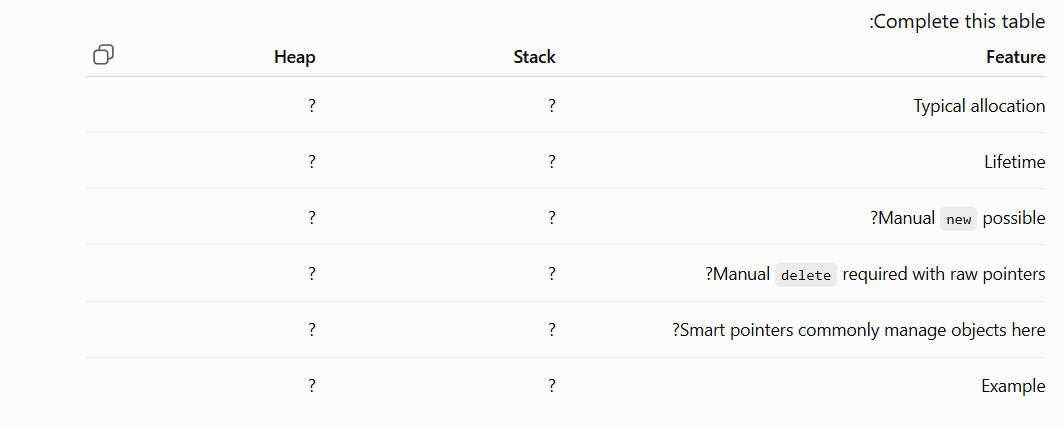

One important clarification:

The stack/heap distinction is about **where the object is stored**, while smart pointers are about **how dynamically allocated objects are managed**.

For example:

In [ ]:
auto frame = std::make_unique<Frame>();

Conceptually:

In [ ]:
Stack                         Heap
─────                         ────

frame ─────────────────────► Frame
unique_ptr                     object


**Q1.**

Why are smart pointers particularly useful for dynamically allocated objects?



Because they provide automatic lifetime management for dynamically allocated objects.

Instead of manually doing:

**new**

and later:

**delete**

we can use:



In [ ]:
std::make_unique<T>()

or:

std::make_shared<T>()

and let RAII manage the object's lifetime.

**Q2.**

Why is modern C++ generally safer when we prefer:

In [ ]:
std::make_unique<T>()

and

In [ ]:
std::make_shared<T>()

instead of manually writing:

In [ ]:
new T

# and:

delete

Because they make ownership and lifetime management safer and clearer.

Then C++ automatically manages the object's lifetime.

### **🧠 The mental model I want you to keep**

This is probably the most useful summary of the whole exercise:

**Raw pointer** + new

In [ ]:
Map* map = new Map();

#  means:

Create Map on heap
       ↓
give me its address
       ↓
store address in map
       ↓
I am responsible for deleting it

**unique_ptr**

In [ ]:
auto map = std::make_unique<Map>();

means:

Create Map on heap
       ↓
unique_ptr owns it
       ↓
one owner
       ↓
automatic destruction

**shared_ptr**

In [ ]:
auto map = std::make_shared<Map>();

# means:

Create Map on heap
       ↓
shared_ptr owns it
       ↓
ownership can be shared
       ↓
last owner disappears
       ↓
Map is automatically destroyed

And this connects **directly** to the Dependency Injection work we just did:

In [ ]:
                    main()
                      │
                      │ creates
                      ▼
               shared_ptr<Map>
                      │
                ┌─────┴─────┐
                ▼           ▼
           Frontend      Backend
             map_          map_
                │           │
                └─────┬─────┘
                      ▼
                 ONE Map

That's a very typical pattern you'll encounter in a SLAM architecture: **one dynamically allocated object, managed by shared_ptr, with multiple modules sharing ownership of it.**

## **CMAke**

**Why do we need it?**

Large C++ projects need an automated, portable build system.

**What is it?**

CMake generates platform-specific build files.

**Syntax**

**Example**

**Common Mistakes**

* Confusing CMake with a compiler
* Forgetting to link required libraries

**SLAM Example**


In [ ]:
find_package(OpenCV)

target_link_libraries(...)

**Key Takeaways**

CMake generates build systems—it does not compile code itself.

**Interview Questions**

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

**CMake does not compile your code.**

**CMake generates the build system that knows how to compile your project.**

### **Exercise C0** — Why Do We Need CMake?

**Question**

Suppose your project contains only one file:

In [ ]:
main.cpp

You can compile it using:

In [ ]:
g++ main.cpp -o app

Now imagine your project grows to:

In [ ]:
main.cpp
pose.cpp
camera.cpp
frame.cpp
frontend.cpp
backend.cpp
map.cpp

**Questions**

1. What problems would you face if you compiled everything manually?

2. Why is CMake useful for large C++ projects?

3. Does CMake compile your code?

**1.**

As the project grows, compiling manually becomes error-prone. We may forget to compile a source file, include the correct header paths, or link the required libraries.

**2.**

CMake automates the build process for large C++ projects. It generates platform-specific build files and manages source files, include directories, libraries, and compiler options from a single configuration file.

**3.**

CMake does not compile your code. It generates the build system that compiles your code.

### **Exercise C1** — First CMakeLists.txt

The project we have:

In [ ]:
project/
│
├── main.cpp
└── CMakeLists.txt

in main.cpp

In [ ]:
#include <iostream>

int main()
{
    std::cout << "Hello CMake!" << std::endl;
}

**Question:**

What's in a basic CMakeLists.txt

cmake_minimum_required(VERSION 3.16)

project(MySLAM)

add_executable(my_slam main.cpp)


### **Exercise C2**

Write the complete add_executable(...) command for a project containing:

In [ ]:
main.cpp
pose.cpp
camera.cpp
frame.cpp

We had:

In [ ]:
g++ main.cpp pose.cpp camera.cpp frame.cpp -o app

so, in cmake:

In [ ]:
add_executable(
    app
    main.cpp
    pose.cpp
    camera.cpp
    frame.cpp
)

### **Exercise C3** — Why do we need include?

**Goal:**

Understand why CMake needs to know where header files are located.


In [ ]:
project/

├── CMakeLists.txt
├── main.cpp
├── pose.cpp
├── pose.h
├── tracker.cpp
└── tracker.h

In main.cpp:

In [ ]:
#include "tracker.h"

int main()
{
    return 0;
}

In tracker.cpp:

In [ ]:
#include "tracker.h"

So ...

In [ ]:
project/

├── CMakeLists.txt
├── src/
│   ├── main.cpp
│   ├── pose.cpp
│   └── tracker.cpp
│
└── include/
    ├── pose.h
    └── tracker.h

**Question 1**

In [ ]:
#include "tracker.h"

**Question 2**

In [ ]:
fatal error:
tracker.h: No such file or directory

**Question 3 (Important ⭐)**

**Questions:**
1. Why can't the compiler automatically find headers in another folder?
2. What happens if the include directory is not specified?
3. Which CMake command tells the compiler where to search for header files?

**1.**

There is no reason for the compiler to search every folder. There may even be multiple files with the same name in different directories, so we must explicitly tell it where to look.

**2.**

If we don't provide the path, the compiler won't find the header file.

**Typical error:**

fatal error:
tracker.h: No such file or directory

**3.**

include_directories(...)

or

target_include_directories(...)

**Why "target"?**

Modern CMake prefers target-specific commands.

Instead of applying include directories globally,
we specify them for each target.

This improves modularity,
reduces name conflicts,
and makes dependencies explicit.

### **Exercise C4 — Libraries**

**Question 1**

Why do C++ projects use libraries?

(Just your own opinion.)

**Question 2**

Suppose we have

In [ ]:
camera.cpp
frame.cpp
map.cpp
frontend.cpp
backend.cpp

Is it logic to have all **executable**?

Or,

it may be much better to have some in a library gathered and then have the library **executable**?

**Answers**

**Q1:** Libraries improve modularity and code reuse. Different executables can use the same library without recompiling or duplicating code.

**Q2:** They should be inside one library.
* Better organization
* Code reuse
* Easier maintenance
* Faster builds (in large projects)

### **Exercise C5 — Linking**

Assume, we only have:

In [ ]:
add_library(...)
// and
add_executable(...)

How does **executable** know which **Library** need to be applied?

Creating a library and creating an executable are two independent steps. The executable does not automatically know which libraries it should use. We must explicitly link the library to the executable.

In [ ]:
target_link_libraries(...)

**CMake** up to now:

In [ ]:
MySLAM/

src/
    main.cpp
    camera.cpp
    frame.cpp
    map.cpp

include/
    camera.h
    frame.h
    map.h

CMakeLists.txt

In [ ]:
cmake_minimum_required(VERSION 3.16)

project(MySLAM)

// Generate a library named `myslam` from these files.
add_library(myslam
    src/camera.cpp
    src/frame.cpp
    src/map.cpp
)

// Create an executable named `run_slam` from `main.cpp`.
add_executable(run_slam
    src/main.cpp
)

// Find 'header files' inside the 'include' folder.
target_include_directories(myslam PUBLIC include)

// Link this executable to this library.
target_link_libraries(run_slam myslam)


**target_include_directories(myslam PUBLIC include)**

**Examples:**

**PRIVATE**

In [ ]:
target_include_directories(
    myslam
    PRIVATE
    include
)

In [ ]:
include/
      │
      ▼
  myslam

**PUBLIC**

In [ ]:
target_include_directories(
    myslam
    PUBLIC
    include
)

In [ ]:
include/
      │
      ▼
  myslam
      │
      ▼
 run_slam

**INTERFACE**

In [ ]:
target_include_directories(
    myslam
    INTERFACE
    include
)

**PRIVATE:**

Only the current target can use these include directories.

**PUBLIC:**

The current target and any target linked against it can use these include directories.

**INTERFACE:**

Only targets linked against this target can use these include directories.
The current target does not use them.

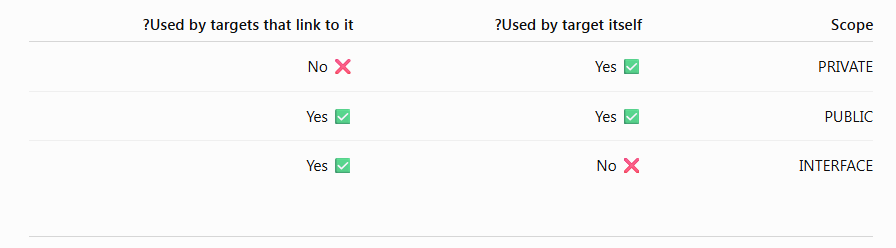

In [ ]:
camera.cpp
frame.cpp
map.cpp
        │
        ▼
   add_library()
        │
        ▼
     myslam
        │
        ▼
target_link_libraries()
        │
        ▼
   run_slam (main.cpp)

### **Exercise C6 — External Libraries**

Is it enough to have

In [ ]:
#include <opencv2/opencv.hpp>

in main.cpp?

Including a header file only tells the compiler about the declarations. The compiler and linker still need to know where the OpenCV headers and libraries are located.

### **Exercise C7 — Reading a Real CMakeLists.txt**

In [ ]:
cmake_minimum_required(VERSION 3.10)

project(MySLAM)

find_package(OpenCV REQUIRED)

add_library(myslam
    src/frame.cpp
    src/map.cpp
    src/frontend.cpp
)

target_include_directories(myslam PUBLIC include)

add_executable(run_slam src/main.cpp)

target_link_libraries(run_slam
    myslam
    ${OpenCV_LIBS}
)

**find_package(OpenCV REQUIRED)**

Searches for an installed package and loads its configuration (include directories, libraries, compile definitions, etc.).

REQUIRED means CMake will stop with an error if the package is not found.

**add_library(...)**

Other executables or libraries can reuse it.

Headers tell the compiler what exists.

Libraries provide the actual implementation.

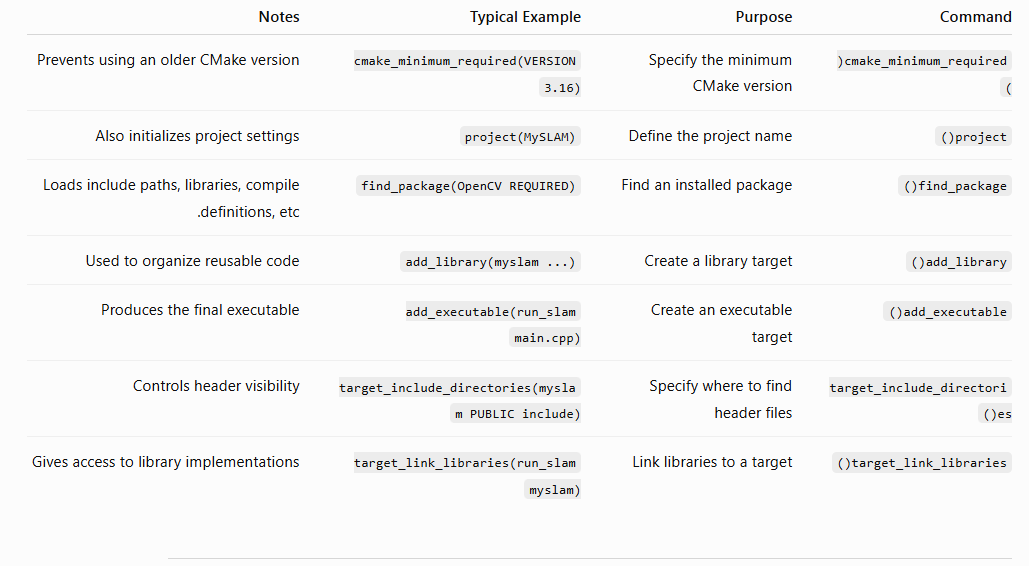

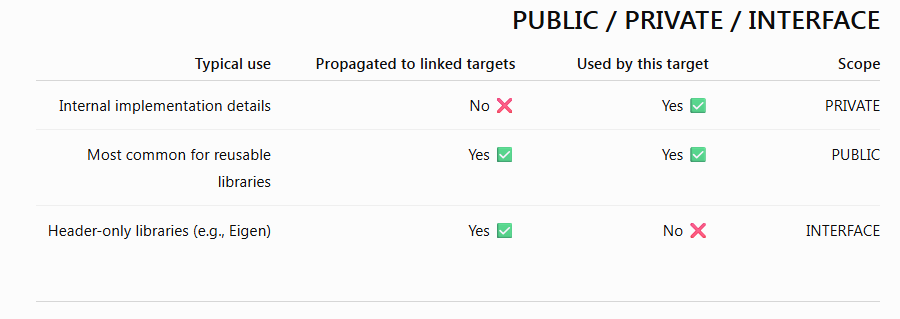

**Build Pipeline (Very Important)**

In [ ]:
Source Files (.cpp)
        │
        ▼
 add_library()
        │
        ▼
    myslam
        │
        ▼
target_include_directories()
        │
        ▼
Headers become visible
        │
        ▼
target_link_libraries()
        │
        ▼
Executable uses the library

# **Chapter 2 — SLAM Mathematics**

In [ ]:
SLAM
 ├── Localization → Where is the camera?
 └── Mapping      → Where are the 3D points?

**Estimate the camera trajectory + build a 3D map.**

### **Step 1 — Initialization**

PnP is not possible; so,

In [ ]:
Frame 1                 Frame 2
   ●                        ●
    \                      /
     \                    /
      \                  /
       \                /
          3D point

Match Features

Apply **geometry of two views** to get the **relative camera pose.**

In [ ]:
Camera poses
+
3D MapPoints

**Then**

Triangulation → initial 3D MapPoints

In [ ]:
START
  ↓
Two-view initialization
  ↓
Initial Camera Poses + Initial 3D Map
  ↓
─────────────────────────────────
        SLAM LOOP
─────────────────────────────────
  ↓
New Frame
  ↓
PnP → New Camera Pose
  ↓
Triangulation → New MapPoints
  ↓
Reprojection Error
  ↓
Optimization / BA
  ↓
Updated Map + Pose
  ↓
Next Frame
  ↺

### **Step 2 — New Frame arrives**

We already have

In [ ]:
Map
 ├── MapPoint 1
 ├── MapPoint 2
 ├── MapPoint 3
 └── ...

3D MapPoint  ←→  2D feature in Frame 3

In [ ]:
Existing 3D MapPoints
        +
2D observations in new frame
        ↓
       PnP
        ↓
New Camera Pose

### **Step 3 — Now we can create MORE MapPoints**

In [ ]:
Frame 2              Frame 3
   ●                     ●
    \                   /
     \                 /
       \             /
          unknown

In [ ]:
2D observation
+
2D observation
+
camera poses
        ↓
Triangulation
        ↓
NEW MapPoint

Map is extending.

### **Step 4 — Reprojection Error**

For an existing MapPoint we have:

In [ ]:
3D MapPoint
+
Camera Pose
+
K

Project it againg.

In [ ]:
3D MapPoint
      ↓
   Projection
      ↓
Predicted pixel

Compare with true features

In [ ]:
Observed pixel
      vs
Predicted pixel

To get the **Reprojection Error**

### **Step 5 — Optimization**

For High Error

In [ ]:
Camera poses
     +
3D MapPoints
     ↓
Bundle Adjustment
     ↓
Better poses
+
Better Map

In [ ]:
             New Frame
                 ↓
        Feature Extraction
                 ↓
        Feature Matching
                 ↓
    Existing 3D MapPoints?
                 ↓
                PnP
                 ↓
       Estimate Camera Pose
                 ↓
      Add / Triangulate new
           MapPoints
                 ↓
       Reprojection Errors
                 ↓
          Optimization
                 ↓
          Update Map
                 ↓
             New Frame
                 ↺

### **So**

**Initialization** is an exception

PnP is not possible

We apply two view geometry

In [ ]:
relative pose
     +
triangulation
     ↓
initial Map

Then

start a chain

In [ ]:
START
  ↓
Two-view initialization
  ↓
Initial Camera Poses + Initial 3D Map
  ↓
─────────────────────────────────
        SLAM LOOP
─────────────────────────────────
  ↓
New Frame
  ↓
PnP → New Camera Pose
  ↓
Triangulation → New MapPoints
  ↓
Reprojection Error
  ↓
Optimization / BA
  ↓
Updated Map + Pose
  ↓
Next Frame
  ↺

## **Camera Model & Projection 📷**


3D MapPoint یادم نی چی بود؟
لندمارکز بود درسته؟ و پوز هم موقعیت دوربین؟
پس برای ما داشتن مدل دوربین در slam مهمه تا ...
فرضا که موقعیت دوربین و نقاط سه بعدی رو داریم
موقعیت نقاط 3d رو به صورت 2d و همچنین پیکسلی تخمین بزنیم
همزمان این پیکسلهارو هم در feature extraction داریم پیدا میکنیم
حالا میتونیم reprojection error رو هم محاسبه کنیم.
حالا Bundle Adjustment هم میاد اینو حداقل میکنه برامون

بله، دقیقاً. ❤️

در SLAM:

MapPoint = 3D landmark

یعنی یک نقطه‌ی سه‌بعدی در محیط که SLAM آن را در map نگه می‌دارد.

مثلاً:

In [ ]:
Map
 ├── MapPoint 1 → (X₁, Y₁, Z₁)
 ├── MapPoint 2 → (X₂, Y₂, Z₂)
 ├── MapPoint 3 → (X₃, Y₃, Z₃)
 └── ...

و هر MapPoint معمولاً از یک feature مشاهده‌شده در یک یا چند image به وجود می‌آید.

و Pose چی بود؟

تقریباً درست گفتی، فقط دقیق‌تر:

**Camera pose describes the position AND orientation of the camera.**

یعنی فقط location نیست.

مثلاً:

In [ ]:
Position     → Where is the camera?
Orientation  → Which direction is it looking?

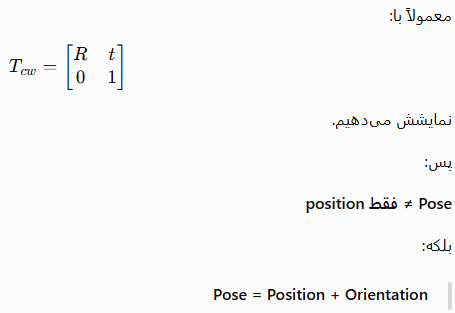

فرضاً که موقعیت دوربین و نقاط سه‌بعدی رو داریم، موقعیت نقاط 3D رو به صورت 2D و همچنین پیکسلی تخمین بزنیم.

بله! فقط یک اصلاح کوچک:

ما اول 3D point را به camera coordinates تبدیل می‌کنیم، بعد آن را روی image plane و در نهایت روی pixel coordinates projection می‌کنیم.

یعنی:

In [ ]:
3D MapPoint in World
        ↓
   Camera Pose
        ↓
3D Point in Camera
        ↓
 Perspective Projection
        ↓
Normalized Image Point
        ↓
Camera Intrinsics
        ↓
Pixel (u, v)

In [ ]:
و Feature Extraction چی؟

دقیقاً نکته‌ی زیبای ماجرا همین‌جاست.

ما در image واقعاً feature را observe می‌کنیم:

Image
  ↓
Feature Extraction
  ↓
Observed pixel
(u_obs, v_obs)

از طرف دیگر، با استفاده از:

MapPoint
+
Camera Pose
+
Camera Model

پیش‌بینی می‌کنیم feature باید کجا دیده شود:

MapPoint
   +
Camera Pose
   ↓
Projection
   ↓
Predicted pixel
(u_pred, v_pred)

و این می‌شود reprojection error.

🔥 و بله:

**Bundle Adjustment tries to minimize these reprojection errors by optimizing camera poses and 3D MapPoints.**

پس زنجیره‌ای که خودت ساختی کاملاً درست بود:

In [ ]:
MapPoint
   +
Camera Pose
   +
Camera Model
       ↓
Predicted Pixel
       ↓
Compare with Observed Feature
       ↓
Reprojection Error
       ↓
Bundle Adjustment
       ↓
Optimization

In [ ]:

اول می‌فهمیم:

Pinhole camera model
Intrinsic parameters
Extrinsic parameters
World → Camera → Image
Homogeneous coordinates
Perspective projection

بعد یک implementation کوچک C++ می‌نویسیم.

### **1. Why do we need a Camera Model?**

A camera observes the 3D world, but an image contains 2D pixels.

So SLAM constantly needs to answer:

**How does a 3D point in the world become a 2D point in the image?**

For example:

In [ ]:
3D world point
      ↓
   Camera
      ↓
  2D image
      ↓
   pixel (u, v)

This process is called projection.

And the reverse problem is also extremely important:

In [ ]:
2D image point
      +
camera information
      ↓
3D information

This is where things like **triangulation** will come later.

### **2. The Pinhole Camera Model**

The simplest camera model used in SLAM is the pinhole camera model.

Imagine a tiny hole between the 3D world and the image plane:

In [ ]:
       3D point P
           ●
          /|
         / |
        /  |
       /   |
      /    |
     ●-----|----------------
   Camera  |
      C    |
            \
             \
              ● Image point

The key idea is:

**A 3D point is projected onto a 2D image plane along a straight line passing through the camera center.**

Because of perspective, objects farther away appear smaller.

That's why projection is not simply:

In [ ]:
x → u
y → v

There is a division by depth.

### **3. Camera Coordinate System**

Before projection, the point needs to be expressed in the camera coordinate system.

Suppose a point is:

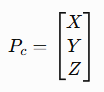

where:

* **\(X\)** → horizontal position relative to camera
* **\(Y\)** → vertical position
* **\(Z\)** → depth

So:

In [ ]:
          Y
          ↑
          |
          |
          ● P
         /
        /
       /
      O────────→ X
     Camera
       |
       |
       ↓
       Z

The exact axis convention can vary between systems, but the important concept is:

**\(P_c\)** describes the point relative to the camera.

### **4. Perspective Projection**

From similar triangles, we get:

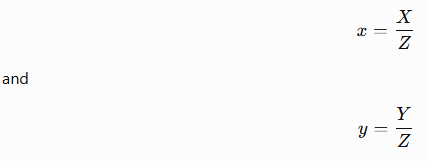

These are the normalized image coordinates.

Notice the important thing:

Depth **\(Z\)** is in the denominator.

So if the same object moves farther away:

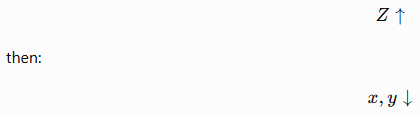

and the object appears smaller.

That's perspective projection.

### **5. From Normalized Coordinates to Pixels**

But our image doesn't usually use coordinates like:

In [ ]:
x = 0.25
y = -0.13

It uses pixels:

In [ ]:
u = 735
v = 421

So we need the camera's intrinsic parameters.

The camera matrix is:

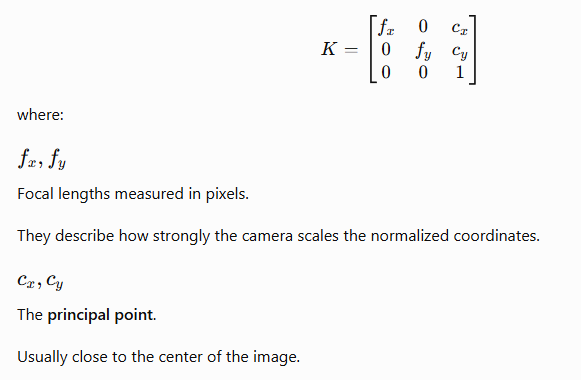

**Focal length = how strongly the camera scales the projected image.**

**Principal point = where the camera's optical axis hits the image.**

In [ ]:
fx → horizontal scaling
fy → vertical scaling

cx → horizontal location of image center / principal point
cy → vertical location of image center / principal point

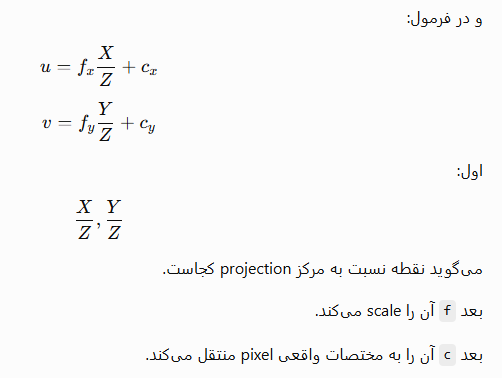

### **6. The Full Projection Equation ⭐**

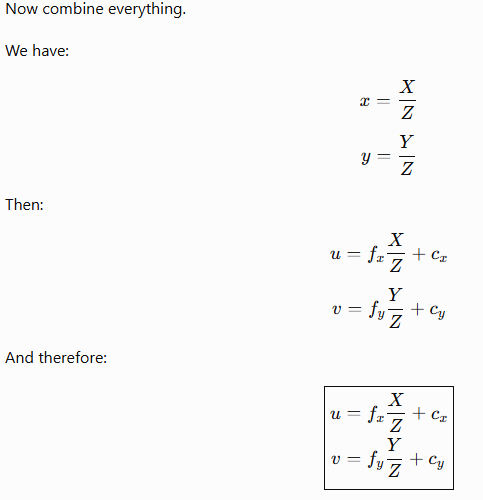

This is one of the equations you will see **everywhere in visual SLAM.**

### **7. Why is this important for SLAM?**

Suppose SLAM has estimated:

In [ ]:
Camera pose
      +
3D MapPoint

It can use the camera model to predict:

**Where should this 3D MapPoint appear in the image?**

That's called **reprojection**.

In [ ]:
3D MapPoint
     ↓
Camera pose
     ↓
Camera coordinates
     ↓
Projection
     ↓
Predicted pixel (u, v)

Then we compare the predicted pixel with the actual observed feature.

For example:

In [ ]:
Observed point:
(735, 421)

Predicted point:
(739, 418)

The difference is the reprojection error.

And guess what?

**Bundle Adjustment minimizes these reprojection errors. 🔥**

So this seemingly simple camera equation eventually connects directly to:

In [ ]:
Camera Model
      ↓
Projection
      ↓
Reprojection Error
      ↓
Bundle Adjustment
      ↓
g2o / Optimization
      ↓
SLAM

That's why we're starting here.

### **8. One very important distinction**

There are actually two different transformations hiding in our pipeline.

**A. World → Camera**

We have a world point:

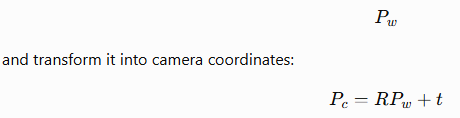

This involves **the camera pose / extrinsic parameters.**

**B. Camera → Image**

Then:

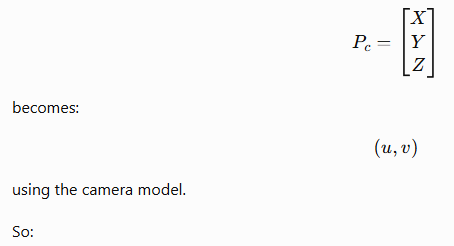

In [ ]:
World Point
    │
    │  Extrinsics / Pose
    ↓
Camera Point
    │
    │  Projection + Intrinsics
    ↓
Image Pixel

**This distinction is VERY important.**

**Extrinsics tell us where the camera is.**

**Intrinsics tell us how the camera sees the world.**

### **🧠 Mini Check — Don't look anything up**

**Q1.**

What is the main purpose of a camera projection model?








**The camera projection model allows us to project a 3D point onto the image and determine its corresponding pixel coordinates.**

**Q2.**

If a 3D point in camera coordinates is:

$$ P_c = (X,Y,Z) $$

what are its normalized image coordinates?



x=
Z/X
	​

y=
Z/Y
	​


**Q3.**

Why do we divide by \(Z\)?



چون perspective projection باعث می‌شود اندازه‌ی ظاهری یک object به فاصله‌اش از دوربین وابسته باشد.

اگر:

$$ x=\frac{X}{Z} $$

وقتی \(Z\) زیاد شود، \(x\) کوچک‌تر می‌شود.

**We divide by \(Z\) to model perspective: objects farther from the camera appear smaller in the image.**

**Q4.**

What do \(f_x\) and \(f_y\) represent?

the camera's focal lengths in pixel units


**Q5.**

What do \(c_x\) and \(c_y\) represent?

The coordinates of the principal point, usually close to the center of the image.

**Q6.**

What is the difference between intrinsic and extrinsic parameters?

**Extrinsic parameters** transform a 3D point from the world coordinate system to the camera coordinate system.

nd

**Intrinsic parameters** project a 3D point in the camera coordinate system onto the 2D image plane and convert it to pixel coordinates.

**Q7.**

Complete the pipeline:

In [ ]:
World Point
     ↓
__________
     ↓
Camera Point
     ↓
__________
     ↓
Image Pixel

In [ ]:
World Point
     ↓
Extrinsics / Camera Pose
     ↓
Camera Point
     ↓
Projection + Intrinsics
     ↓
Image Pixel

Q8. ⭐

Suppose a MapPoint is at:

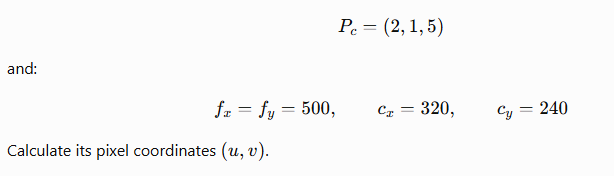

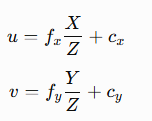

**1. MapPoint**

3D landmark

**2. Pose**

Where is the camera?
+
Which direction is it facing?

**3. Camera Model**

How does a 3D point
appear as a 2D pixel?

In [ ]:
MapPoint + Pose + Camera Model
                  ↓
            Predicted Pixel
                  ↓
       compare with Feature
                  ↓
          Reprojection Error
                  ↓
          Bundle Adjustment

### **Homogeneous Coordinates + Camera Matrix**

**1. Why do we need homogeneous coordinates?**

It is much easier to have a matrix multiplication instead of equations containing divisions.

**2. Ordinary 2D point**

In homogeneous coordinates we have

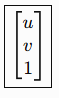

Instead of (u,v)

**3. 3D point**

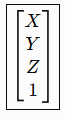

**4. Camera Matrix ⭐**

camera intrinsic matrix

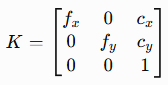

**5. What does K do?**

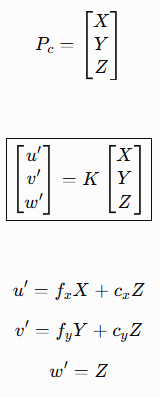

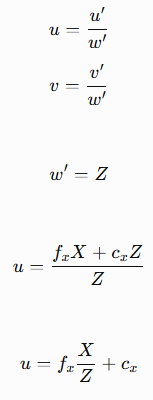

**So the whole thing is:**

In [ ]:
3D point in camera coordinates
              ↓
        [ X ]
        [ Y ]
        [ Z ]
              ↓
              K
              ↓
        [ u' ]
        [ v' ]
        [ w' ]
              ↓
       divide by w'
              ↓
        pixel (u,v)

**Homogeneous coordinates allow us to represent transformations and projection using matrix multiplication.**

**The intrinsic matrix \(K\) converts camera-coordinate information into image/pixel coordinates.**

**Q1.** Why do we use homogeneous coordinates?

Homogeneous coordinates allow us to represent projection and transformations using matrix multiplication, which makes the mathematical formulation more convenient.

**Q2.** Write the intrinsic camera matrix \(K\).

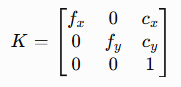

**Q3.** If

$$ P_c=(X,Y,Z) $$

what is:

$$ K P_c $$

in terms of \(u',v',w'\)?


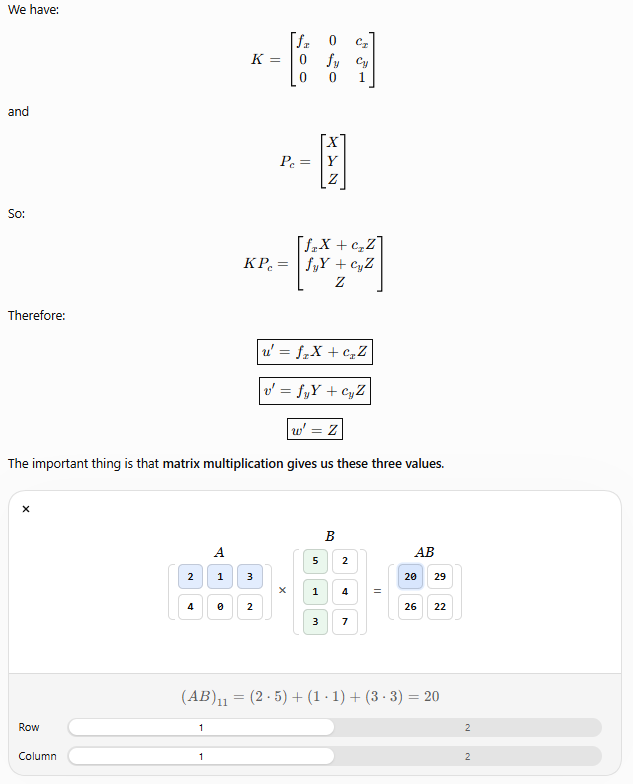


**Q4.** Why do we divide \(u'\) and \(v'\) by \(w'\) at the end?

After multiplication, we have homogeneous image coordinates:

(u',v',w')

To convert them into ordinary 2D image/pixel coordinates, we divide by \(w'\):


**We divide by \(w'\) to convert homogeneous image coordinates into ordinary 2D pixel coordinates.**

And because here:

 w'=Z

we get:

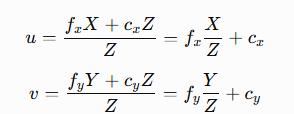

🎯 We're back exactly at the projection equations we learned before.

In [ ]:
3D point in Camera Coordinates
          (X, Y, Z)
                ↓
             K × P
                ↓
      (u', v', w')
                ↓
       divide by w'
                ↓
           (u, v)
                ↓
         Pixel coordinates

**The Camera Matrix \(K\) didn't magically do the perspective division.**

It gave us:

(u',v',w')

and the normalization step gave us:

(u,v)

That's a small detail, but an important one.

### **📷 Camera Projection — C++ Implementation**

We want a function that takes:

* a **3D point in camera coordinates**
* the **intrinsic matrix \(K\)**

and returns:

the corresponding **pixel coordinates** \((u,v)\).

The mathematical pipeline is:

In [ ]:
3D point
   ↓
K × P
   ↓
(u', v', w')
   ↓
normalize by w'
   ↓
(u, v)

#### **Step 1 — The function**

We'll use Eigen because that's what we're using throughout our SLAM code.

In [ ]:
Eigen::Vector2d project(
    const Eigen::Vector3d& point,
    const Eigen::Matrix3d& K
)

Notice something we've already learned:

**Why** const &?

In [ ]:
const Eigen::Vector3d& point

We don't want to copy the 3D point, and we don't want the function to modify it.

Same for K.


#### **Step 2 — Your first task**

Don't look for a complete solution yet. I want you to write the function.

Start with:

In [ ]:
#include <iostream>
#include <Eigen/Core>

Eigen::Vector2d project(
    const Eigen::Vector3d& point,
    const Eigen::Matrix3d& K
)
{
    // Your code here
}

You need to do three things inside it.

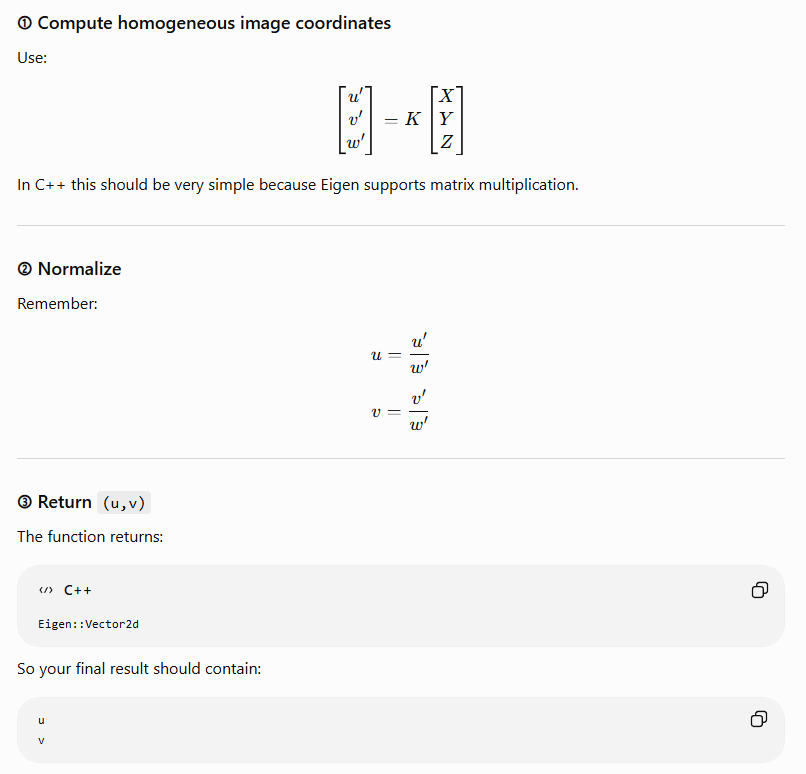

### **Exercise 1 — Basic Projection**

Use:

In [ ]:
Eigen::Matrix3d K;

K << 500, 0, 320,
     0, 500, 240,
     0,   0,   1;

and:

In [ ]:
Eigen::Vector3d point(2, 1, 5);

Then call your function and print the result.

We already know mathematically the answer should be:

u = 520
v = 340

But don't hard-code 520 and 340. 😈

The function itself must calculate them.

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <Eigen/Core>

Eigen::Vector2d project(
    const Eigen::Vector3d& point,
    const Eigen::Matrix3d& K
)
{
    // 1. Project 3D point using camera intrinsic matrix
    Eigen::Vector3d projected = K * point;

    // 2. Normalize by the third coordinate
    double u = projected(0) / projected(2);
    double v = projected(1) / projected(2);

    return Eigen::Vector2d(u, v);
}

int main()
{
    // Camera intrinsic matrix
    Eigen::Matrix3d K;

    K << 500, 0, 320,
         0, 500, 240,
         0, 0, 1;

    // 3D point
    Eigen::Vector3d point(2, 1, 5);

    // Project 3D point to image
    Eigen::Vector2d pixel = project(point, K);

    // Print result
    std::cout << "3D point:" << std::endl;
    std::cout << point << std::endl;

    std::cout << "\nProjected 2D point (u, v):" << std::endl;
    std::cout << pixel << std::endl;

    return 0;
}

Writing main.cpp


In [ ]:
!g++ main.cpp -o out
!./out

main.cpp:3:10: fatal error: Eigen/Core: No such file or directory
    3 | #include <Eigen/Core>
      |          ^~~~~~~~~~~~
compilation terminated.
/bin/bash: line 1: ./out: No such file or directory


### **Exercise 2 — Change the 3D point**

After Exercise 1 works, change:

point(2, 1, 5)

to:

point(4, 2, 10)

Before running the program, predict:

Will the pixel coordinates change?

Think about:

**X/Z** and **Y/Z**

Then run it.

This is a very important little observation about perspective projection.

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <Eigen/Core>

Eigen::Vector2d project(
    const Eigen::Vector3d& point,
    const Eigen::Matrix3d& K
)
{
    // 1. Project 3D point using camera intrinsic matrix
    Eigen::Vector3d projected = K * point;

    // 2. Normalize by the third coordinate
    double u = projected(0) / projected(2);
    double v = projected(1) / projected(2);

    return Eigen::Vector2d(u, v);
}

int main()
{
    // Camera intrinsic matrix
    Eigen::Matrix3d K;

    K << 500, 0, 320,
         0, 500, 240,
         0, 0, 1;

    // 3D point
    Eigen::Vector3d point(4, 2, 10);

    // Project 3D point to image
    Eigen::Vector2d pixel = project(point, K);

    // Print result
    std::cout << "3D point:" << std::endl;
    std::cout << point << std::endl;

    std::cout << "\nProjected 2D point (u, v):" << std::endl;
    std::cout << pixel << std::endl;

    return 0;
}

For Exercise 2:

P=(4,2,10)

So the pixel stays exactly the same.

Exercise 2:
The pixel coordinates stay the same because both \(X\) and \(Y\) are doubled together with \(Z\). Therefore, the ratios \(X/Z\) and \(Y/Z\) remain unchanged.

### **Exercise 3 — Change the depth**

Now use:

In [ ]:
point(2, 1, 10);

Predict the result before running the code.

Then explain in English:

Why did the pixel coordinates move closer to the principal point?

In [ ]:
%%writefile main.cpp

#include <iostream>
#include <Eigen/Core>

Eigen::Vector2d project(
    const Eigen::Vector3d& point,
    const Eigen::Matrix3d& K
)
{
    // 1. Project 3D point using camera intrinsic matrix
    Eigen::Vector3d projected = K * point;

    // 2. Normalize by the third coordinate
    double u = projected(0) / projected(2);
    double v = projected(1) / projected(2);

    return Eigen::Vector2d(u, v);
}

int main()
{
    // Camera intrinsic matrix
    Eigen::Matrix3d K;

    K << 500, 0, 320,
         0, 500, 240,
         0, 0, 1;

    // 3D point
    Eigen::Vector3d point(2, 1, 10);

    // Project 3D point to image
    Eigen::Vector2d pixel = project(point, K);

    // Print result
    std::cout << "3D point:" << std::endl;
    std::cout << point << std::endl;

    std::cout << "\nProjected 2D point (u, v):" << std::endl;
    std::cout << pixel << std::endl;

    return 0;
}

The pixel coordinates move closer to the principal point because the depth \(Z\) increases while \(X\) and \(Y\) stay the same. Due to perspective projection, a point that is farther from the camera appears closer to the center of the image.

**In general:**

As \(Z\) increases, \(X/Z\) and \(Y/Z\) become smaller, so the projected point moves toward the principal point \((c_x,c_y)\).

In [ ]:
Same X/Z and Y/Z
      ↓
Same pixel

Larger Z, same X/Y
      ↓
Smaller X/Z and Y/Z
      ↓
Point moves toward (cx, cy)

## **Triangulation 📐**

In [ ]:
می‌ریم سراغ:

Two-view geometry
Corresponding points
Stereo geometry
Recovering 3D points
Why depth can be estimated

و بعد implementation.

### **1. Why do we need Triangulation?**

With our **camera model**, we learned:

**3D point → 2D pixel**

But in SLAM, we often have the opposite situation.

We observe the same feature in two images, and we want to recover its 3D position.

So:

In [ ]:
3D Point
   ↓
Camera 1 ─────→ Image 1 → pixel 1
   │
   ↓
Camera 2 ─────→ Image 2 → pixel 2

We know:

* Camera 1's pose
* Camera 2's pose
* The pixel observation in Camera 1
* The corresponding pixel observation in Camera 2

And we want:

Where is the 3D point?

That's triangulation.

### **2. The basic intuition 🎯**

Imagine two cameras looking at the same object:

In [ ]:
Camera 1                         Camera 2
   ●                                ●
    \                              /
     \                            /
      \                          /
       \                        /
        \                      /
         \                    /
          \                  /
           \                /
             \            /
                ●
             3D Point

Each camera gives us a ray going from the camera center through the observed pixel.

If everything were perfect, the two rays would intersect at exactly one point.

That intersection is the 3D point.

So the fundamental idea is:

**Triangulation finds the 3D point from the intersection of two viewing rays.**

### **3. Why one camera is not enough**

This is very important.

Suppose Camera 1 observes a feature at pixel (520, 340).

Can we determine its exact 3D position?

**No. ❌**

**Why?**

Because that pixel corresponds to an **entire 3D ray**.

In [ ]:
                 ● P3
                /
               ● P2
              /
             ● P1
            /
Camera ●───●──────────────
         same pixel ray

All of these 3D points could project to the same pixel.

For example:

In [ ]:
(2, 1, 5)
(4, 2, 10)
(6, 3, 15)

They have the same:

X/Z

and:

Y/Z

Therefore, they can produce the same pixel.

This is exactly the depth ambiguity we saw in perspective projection.

### **4. A second camera solves the ambiguity**

Now introduce another camera from a different position.

The same 3D point produces another viewing ray.

In [ ]:
Camera 1
   ●
    \
     \
      \
       ●  ← 3D point
      /
     /
    /
   ●
Camera 2

Now the two rays constrain the point.

This is why we need multiple views.

### **5. What does "corresponding points" mean?**

Suppose we have two images:

In [ ]:
Image 1                  Image 2

   ● feature                ● feature
   (u1,v1)                  (u2,v2)

These two features must correspond to the same physical point in the world.

For example:

In [ ]:
Image 1                    Image 2

Person's eye               Person's eye
     ●                          ●

Then we have:

p_1 <-> p_2

This correspondence is an important input to triangulation.

### **6. What information do we need?**

To triangulate a 3D point, we generally need:

**From Camera 1:**
* Intrinsics K_1
* Pose T_1
* Pixel observation p_1

**From Camera 2:**
* Intrinsics K_2
* Pose T_2
* Pixel observation \(p_2)

Then:

In [ ]:
Camera 1                         Camera 2
   │                                │
   ├── K₁                           ├── K₂
   ├── T₁                           ├── T₂
   └── pixel p₁                     └── pixel p₂
            \                      /
             \                    /
              \                  /
               \                /
                  Triangulation
                       ↓
                    3D Point

In many SLAM systems, the cameras may have the same intrinsics, but conceptually we can keep them separate.

### **7. The connection to what we just learned ⭐**

Remember our projection equation:

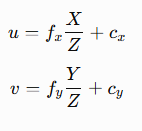

Projection says:

In [ ]:
3D → 2D

Triangulation essentially uses observations from multiple cameras/views to recover:

In [ ]:
2D + 2D + camera geometry → 3D

So:

In [ ]:
                  Camera Model
                       │
          ┌────────────┴────────────┐
          ↓                         ↓
      Projection              Triangulation
          ↓                         ↓
       3D → 2D                 2D + 2D → 3D

🔥 This connection is very important for SLAM.

### **8. What happens in real life?**

Here's one subtle but important point.

In our perfect drawing, the two rays intersect exactly.

But real measurements aren't perfect.

We have:

* feature detection error
* image noise
* imperfect camera calibration
* imperfect camera pose
* numerical errors

So the rays might look like:

In [ ]:
Camera 1
   ●
    \
     \
      \       ●
       \     /
        \   /
         \ /
          X
         / \
        /   \
       /     \
      /       \
     ●
Camera 2

They may **not intersect exactly.**

Therefore, practical triangulation finds the 3D point that best fits the observations rather than relying on a perfect geometric intersection.

We'll get into the algorithms later.

### **9. Stereo SLAM intuition 👀**

This is particularly easy to understand with a stereo camera.

Two cameras are separated by a distance called baseline:

In [ ]:
Camera Left                 Camera Right
     ●---------------------------●
              baseline
                 B

       \                       /
        \                     /
         \                   /
          \                 /
             ●
          3D Point

The same point appears at slightly different horizontal positions in the two images.

This difference is called disparity.

Roughly:

disparity=uL​−uR​

And depth is related to disparity:

Z ∝ 1 / disparity

More precisely, for an ideal rectified stereo camera:

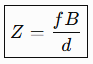

where:

* ***f*** = focal length
* ***B*** = baseline
* ***d*** = disparity
* ***Z*** = depth

So:

**Large disparity** → close point

**Small disparity** → far point

Which again connects directly to perspective. 😎

### **10. Why is Triangulation important in SLAM?**

Because SLAM needs to create 3D MapPoints.

A typical pipeline looks like:

In [ ]:
New image
   ↓
Feature extraction
   ↓
Feature matching
   ↓
Corresponding observations
   ↓
Triangulation
   ↓
3D MapPoints
   ↓
Map

So when you see something like:

In [ ]:
MapPoint::CreateNewMappoint(...)

somewhere in a SLAM system, triangulation may be part of the process that gave us its initial 3D position.

And then later:

In [ ]:
MapPoint
   +
Camera Pose
   ↓
Projection
   ↓
Reprojection Error
   ↓
Optimization

So our story is becoming:

In [ ]:
Feature observations
        ↓
   Triangulation
        ↓
    3D MapPoints
        ↓
    Camera + Map
        ↓
Reprojection Error
        ↓
 Bundle Adjustment

**Camera Model + Camera Poses are Triangulation's requirements**

In [ ]:
Camera Model + Camera Poses
          ↓
   Pixel observations
          ↓
      Triangulation
          ↓
      3D MapPoint

**A more complete Map:**

In [ ]:
                 Camera Model
                      │
                      ↓
Feature observations + Camera Poses
                      │
                      ↓
                 Triangulation
                      │
                      ↓
                 3D MapPoints
                      │
                      ↓
              Projection again
                      │
                      ↓
             Reprojection Error
                      │
                      ↓
              Bundle Adjustment
                      │
                      ↓
       Better Poses + Better MapPoints

### **🧠 Mini Check — Triangulation**



**Q1.**

What is the main purpose of triangulation?


Triangulation is used to recover the 3D position of a feature observed in two or more images, using the camera model and camera poses.

**Q2.**

Why can't a single camera determine the exact 3D position of a point from one pixel?



A single pixel observation corresponds to an entire 3D ray, so we cannot determine the exact depth of the point from one image alone.

**Q3.**

What geometric object does a pixel observation correspond to in 3D?

Choose:

* A single 3D point
* A 3D ray
* A 2D line


A 3D ray.

**Q4.**

What information do we need from two cameras/views to triangulate a point?



The camera intrinsics, camera poses, and corresponding pixel observations from the two views.

**Q5.**

What is a corresponding point?



A corresponding point is the same physical feature observed in two different images.

**Q6.** ⭐

Complete:

In [ ]:
Projection:
3D → ______

Triangulation:
2D + 2D + camera geometry → ______

In [ ]:
Projection: 3D → 2D
Triangulation: 2D + 2D + camera geometry → 3D

**Q7.** Stereo

If disparity becomes smaller, does the 3D point become:

closer
farther

And why?

A nearby object produces a larger difference between its positions in the two images. A distant object produces a smaller difference.

**We now have this chain:**

In [ ]:
Same feature in two images
          ↓
Two pixel observations
          ↓
Two viewing rays
          ↓
Triangulation
          ↓
3D MapPoint

**And then later:**

In [ ]:
3D MapPoint
     ↓
Projection
     ↓
Predicted pixel
     ↓
Compare with observed pixel
     ↓
Reprojection Error
     ↓
Bundle Adjustment

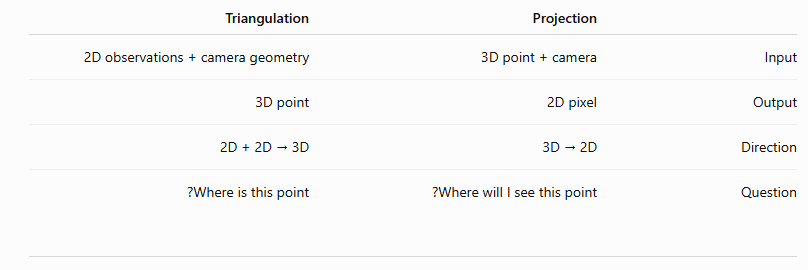

### **Triangulation — Part 2**

**1. From pixel to viewing ray**

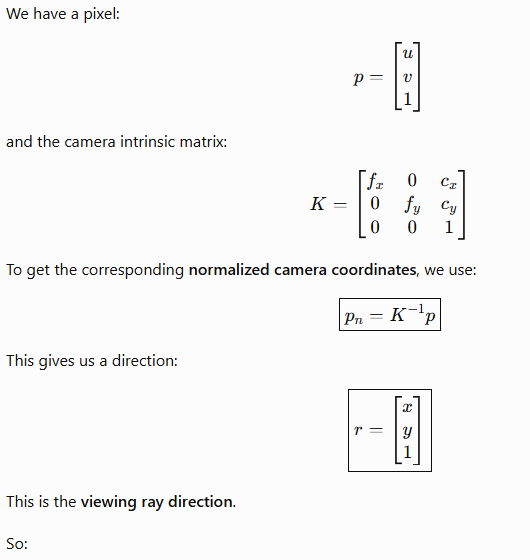

In [ ]:
Pixel
  ↓
K⁻¹
  ↓
Normalized coordinate
  ↓
Viewing ray

Notice: we're not getting the 3D point yet.

We're only getting its direction from the camera.

**2. Why do we need camera poses?**

Suppose we have two cameras:

In [ ]:
Camera 1 ●──────────────● Camera 2
            baseline

Each camera gives us a ray.

But those rays are expressed in their respective camera coordinate systems.

We need the camera poses to know where those rays are in the world.

So:

In [ ]:
Pixel 1 → Ray 1 ─┐
                 ├──→ Triangulation → 3D Point
Pixel 2 → Ray 2 ─┘

The camera poses tell us how to transform those rays into a common coordinate system.

**3. The geometric idea**

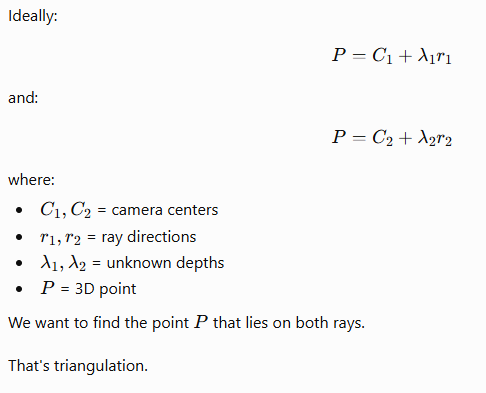

**4. Stereo case ⭐**

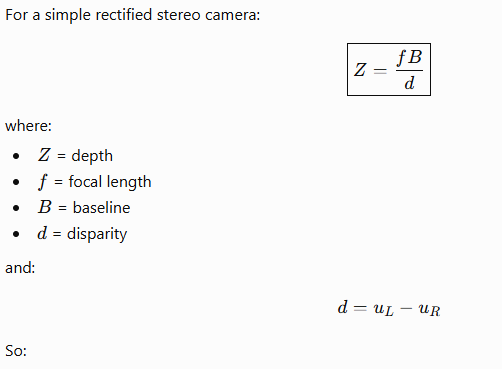

In [ ]:
large disparity  → small Z → close
small disparity  → large Z → far

This is one of the most useful intuitions in stereo vision.

**5. One important SLAM connection**

In monocular SLAM, we don't have two physical cameras.

Instead, the camera moves:

In [ ]:
Frame 1                    Frame 2
   ●                         ●
    \                       /
     \                     /
      \                   /
          3D Point

So the two "views" come from different camera poses at different times.

We can still triangulate:

Two observations from different camera poses can provide the geometric information needed to recover a 3D point.

🔥 This is extremely important for understanding monocular SLAM.

**🧠 The whole Triangulation picture**

Keep this:

In [ ]:
Pixel 1 ──→ K₁⁻¹ ──→ Ray 1 ──┐
                              │
                              ├──→ 3D MapPoint
                              │
Pixel 2 ──→ K₂⁻¹ ──→ Ray 2 ──┘
             ↑
        Camera Poses

And the conceptual difference:

Projection: "I know the 3D point. Where does it appear in the image?"

Triangulation: "I know where the point appears in multiple images. Where is the 3D point?"

### **Mini Check**

**Q1.** What does \(K^{-1}p\) give us?

normalized camera coordinates. This is the viewing ray direction.

**Q2.** Does a viewing ray directly give us the exact 3D point? Why?

We're only getting its direction from the camera.

Because, each camera gives us a ray. But those rays are expressed in their respective camera coordinate systems. We need the camera poses to know where those rays are in the world.

**Q3.** In monocular SLAM, where do the two views needed for triangulation come from?

Two positions of the same camera.

In [ ]:
Frame 1                    Frame 2
Camera Pose 1              Camera Pose 2
     ●                         ●
      \                       /
       \                     /
        \                   /
             3D Point

Same physical camera, different positions.


**Q4.** Complete:

Z = fB / ----------
	​

d = disparity

### **Tiny C++ Triangulation Exercise**

Assume a simple stereo camera:

* focal length: f = 500
* baseline: B = 0.2 m
* left pixel: u_left = 350
* right pixel: u_right = 300

Use:

d=uL​−uR​

and:

Z= fB / d​

In [ ]:
#include <iostream>

int main()
{
    double f = 500.0;
    double B = 0.2;

    double u_left = 350.0;
    double u_right = 300.0;

    // Your code here

    return 0;
}

Write a small C++ program that:

1. Calculates the disparity d.
2. alculates the depth Z.
3. Prints both.

Start with:

In [ ]:
#include <iostream>

int main()
{
    double f = 500.0;
    double B = 0.2;

    double u_left = 350.0;
    double u_right = 300.0;

    // Calculate disparity
    double d = u_left - u_right;

    // Calculate depth
    double Z = (f * B) / d;

    // Print results
    std::cout << "Disparity: " << d << std::endl;
    std::cout << "Depth: " << Z << " m" << std::endl;

    return 0;
}


## **Perspective-n-Point (PnP)**


In [ ]:
3D points + 2D observations
             ↓
       Camera Pose

**Why do we need it?**

A SLAM system must estimate the camera pose in every frame. If we already know the 3D positions of landmarks and can detect their corresponding 2D image points, PnP estimates the camera's position and orientation.

**Intuition**

Imagine you know the exact locations of several landmarks in the world.

Now you take a picture.

The question is:

**"Where was the camera when this picture was taken?"**

PnP answers exactly this question.

**What is it?**

Perspective-n-Point (PnP) estimates the camera pose from known 3D world points and their corresponding 2D image observations.

**Mathematical Idea**

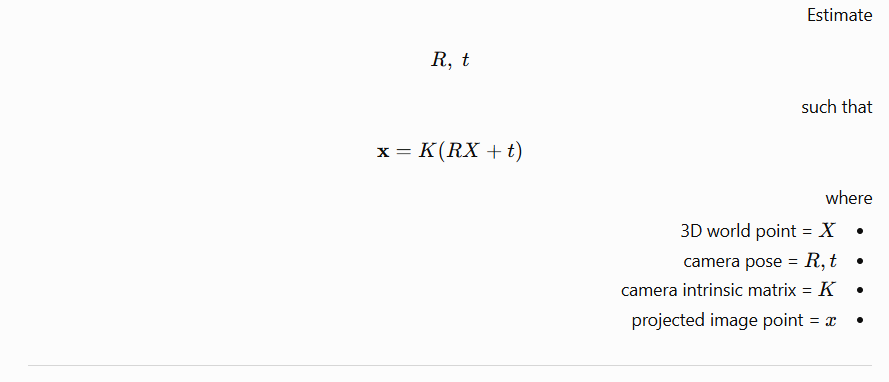

**Inputs / Outputs**

**Input**
* Camera intrinsics
* 3D landmarks
* 2D image observations
**Output**
* Camera rotation
* Camera translation

**Syntax**

**Example**

In [ ]:
cv::solvePnP(...)

**Common Mistakes**

* Too few point correspondences
* Incorrect feature matching
* Ignoring outliers

**SLAM Example**


Tracking estimates the pose of every incoming frame using PnP before local optimization.

**Key Takeaways**

* 3D → 2D correspondences
* Estimate camera pose
* Used in visual localization

**Interview Questions**

* Why are at least four correspondences usually required?
* What is the difference between PnP and triangulation?

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

Triangulation:

2D + 2D → 3D

PnP:

3D + 2D → Camera Pose

So we're building a really nice chain:

In [ ]:
Projection
3D → 2D

Triangulation
2D + 2D → 3D

PnP
3D + 2D → Camera Pose

### **1. Why do we need PnP?**

Look at what we just learned.

**Projection:**

In [ ]:
3D Point + Camera
        ↓
      2D Pixel

**Triangulation:**

In [ ]:
2D + 2D + Camera Geometry
        ↓
       3D Point

Now PnP asks a different question:

**I already know where some 3D points are in the world, and I can see them in my image. Where is my camera?**

So:

In [ ]:
Known 3D points
      +
Their 2D image observations
      +
Camera intrinsics
      ↓
     PnP
      ↓
Camera Pose
(R, t)

That's the core idea. ⭐

### **2. A simple example**

Suppose our map already contains:


In [ ]:
P1 = (1, 2, 5)
P2 = (2, 1, 4)
P3 = (0, 3, 6)
P4 = (2, 2, 8)

We see those same points in a new image:


In [ ]:
P1 → pixel (u1,v1)
P2 → pixel (u2,v2)
P3 → pixel (u3,v3)
P4 → pixel (u4,v4)

We know:

3D point ↔ 2D observation

and we know the camera intrinsics \(K\).

PnP estimates:

***R, t***

so that the 3D points project as closely as possible to their observed pixels.

### **3. What exactly are we finding?**

Remember:

Pose = position + orientation

So PnP estimates both.

R → camera orientation
t → camera translation

Together:

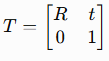T=[R0​t1​]

So:

**PnP estimates the camera pose from 3D–2D correspondences.**

### **4. The geometry**

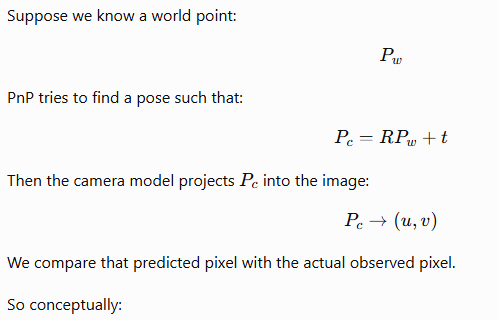

In [ ]:
Known 3D MapPoint
       ↓
   Candidate Pose
       ↓
     Project
       ↓
Predicted pixel
       ↓
Compare
       ↓
Observed pixel

PnP finds the pose that gives the best agreement.

### **5. PnP vs Triangulation 🔥**

This is the distinction I REALLY want you to remember:

**Triangulation**

We know:

Camera poses
+
2D observations

We find:

3D point

**PnP**

We know:

3D points
+
2D observations

We find:

Camera pose

So:

In [ ]:
Triangulation:
2D + 2D → 3D

PnP:
3D + 2D → Pose

### **6. Where does PnP appear in SLAM?**

This is where it becomes really relevant to your project.

Imagine we've already built some MapPoints:

In [ ]:
Map
 ├── MapPoint 1
 ├── MapPoint 2
 ├── MapPoint 3
 └── ...

Now a new frame arrives.

We extract features and match them with existing MapPoints:

In [ ]:
New Frame
   ↓
Feature Extraction
   ↓
Feature Matching
   ↓
3D MapPoint ↔ 2D Feature
   ↓
PnP
   ↓
Estimate New Camera Pose

🔥 So PnP is one of the mechanisms that can help SLAM answer:

**"Where is the camera in the map right now?"**

### **7. One subtle but important thing**

PnP does **not** create the 3D points.

Those already exist.

That's different from triangulation.

In [ ]:
Triangulation
     ↓
creates / estimates 3D MapPoints

PnP
     ↓
estimates camera pose using existing 3D MapPoints

### **🧠 Mini Check**

**Q1.** What does PnP stand for?



Perspective-n-Point.

**Q2.** What are the main inputs to PnP?



Known 3D points, their corresponding 2D image points, and the camera intrinsic parameters.

**Q3.** What is the output of PnP?


The camera pose, represented by rotation \(R\) and translation \(t\).

**Q4.** What is the difference between R and t?

R represents camera orientation, while \(t\) represents camera translation/position relative to the chosen coordinate frame.



**Q5.** Complete:

Triangulation:
2D + 2D + camera geometry → ______

PnP:
3D + 2D + camera intrinsics → ______


Triangulation: 2D + 2D + camera geometry → 3D MapPoint
PnP: 3D + 2D + camera intrinsics → Camera Pose


**Q6.** ⭐

In a SLAM system, why can PnP be useful when a new frame arrives?

It estimates the new camera's pose by using its 2D feature observations and their corresponding existing 3D MapPoints.

### **Tiny Numerical PnP Intuition Exercise**

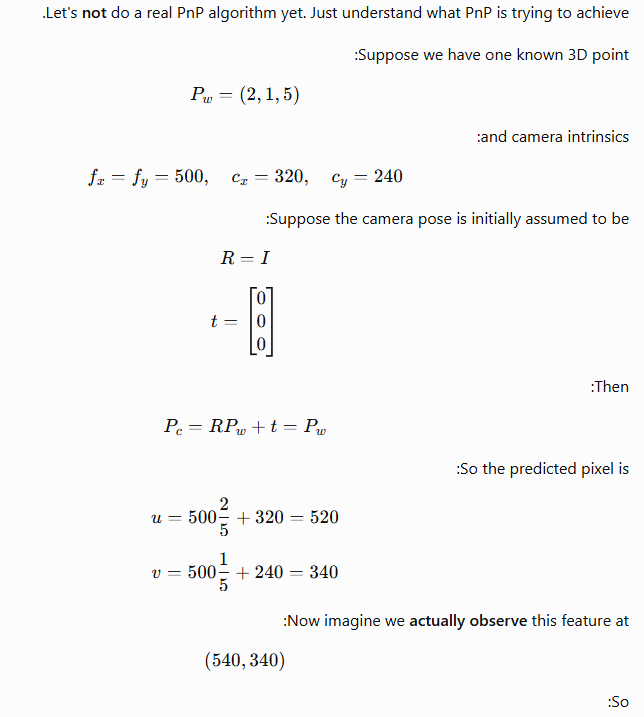

In [ ]:
Predicted pixel: (520, 340)
Observed pixel:  (540, 340)

There is an error.

**Your question:**

If the 3D point is known and the camera intrinsics are known, what does PnP need to change to make the predicted pixel move toward the observed pixel?

Choose:

A) The 3D MapPoint

B) The camera pose \(R,t\)

C) The camera intrinsics \(K\)

B) The camera pose \(R,t\) ✅

This is because PnP seeks to determine the pose such that the projection of the 3D point comes close to the observed pixel.

### **Tiny PnP-related C++ Exercise**

Suppose we have the **pose** and simply want to see where a **3D point** appears under that pose.

In [ ]:
#include <iostream>
#include <Eigen/Core>

int main()
{
    // Camera intrinsics
    Eigen::Matrix3d K;

    K << 500, 0, 320,
         0, 500, 240,
         0, 0, 1;

    // Known 3D point in world coordinates
    Eigen::Vector3d P_w(2, 1, 5);

    // Camera rotation
    Eigen::Matrix3d R = Eigen::Matrix3d::Identity();

    // Camera translation
    Eigen::Vector3d t(1, 0, 0);

    // TODO:
    // 1. Transform the point from world coordinates
    //    to camera coordinates.
    //
    //    P_c = R * P_w + t

    // 2. Project P_c to pixel coordinates.

    // 3. Print P_c and the pixel coordinates.

    return 0;
}

Your tasks:

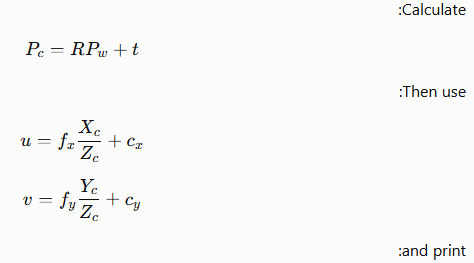

In [ ]:
Camera coordinates:
...

Pixel:
...

In [ ]:
#include <iostream>
#include <Eigen/Core>

int main()
{
    // Camera intrinsics
    Eigen::Matrix3d K;

    K << 500, 0, 320,
         0, 500, 240,
         0, 0, 1;

    // Known 3D point in world coordinates
    Eigen::Vector3d P_w(2, 1, 5);

    // Camera rotation
    Eigen::Matrix3d R = Eigen::Matrix3d::Identity();

    // Camera translation
    Eigen::Vector3d t(1, 0, 0);

    // 1. Transform world point to camera coordinates
    Eigen::Vector3d P_c = R * P_w + t;

    // 2. Project to pixel coordinates
    double X_c = P_c(0);
    double Y_c = P_c(1);
    double Z_c = P_c(2);

    double u = K(0, 0) * X_c / Z_c + K(0, 2);
    double v = K(1, 1) * Y_c / Z_c + K(1, 2);

    // 3. Print
    std::cout << "Camera coordinates:" << std::endl;
    std::cout << P_c << std::endl;

    std::cout << "\nPixel:" << std::endl;
    std::cout << u << " " << v << std::endl;

    return 0;
}

It is a forward projection problem. It demonstrates the forward direction of the camera model, which is essentially the direction opposite to what PnP solves. We can use it to verify the pose by checking whether the projected 3D point matches the observed pixel.

In [ ]:
Projection:
Known 3D + Pose → 2D

PnP:
Known 3D + 2D → Estimate Pose

And this is exactly why PnP uses reprojection error:

In [ ]:
Candidate Pose
      ↓
Project 3D points
      ↓
Predicted pixels
      ↓
Compare with observed pixels
      ↓
Error

## **Lie Groups — Quick Review**

In [ ]:
SO(3)
SE(3)
rotation
translation
exp / log
hat / vee
Sophus

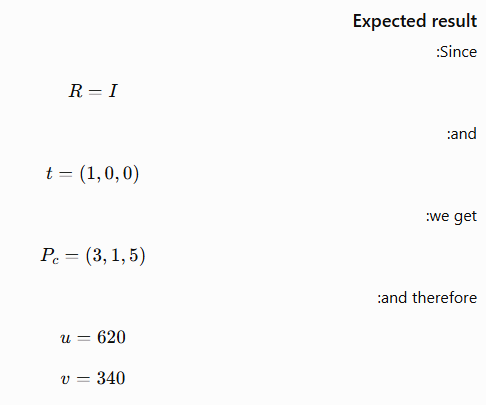

Lie Groups give us a mathematically clean way to make small pose updates while staying on the valid transformation space.

In [ ]:
Lie Group
   ↓
valid poses / transformations

Lie Algebra
   ↓
small perturbations / increments

**Lie algebra gives us a convenient representation for small pose updates; the exponential map converts that update into a valid SE(3) transformation.**

**SO(3)**

3D rotation

**SE(3)**

3D rotation + translation

**Lie Algebra**

A convenient space for representing small updates to transformations

**SE(3) degrees of freedom**

 6

**Exponential map**

Converts a Lie-algebra update into a valid transformation.

### **🧠 Quick Check — 5 questions**

**Q1.** What does \(SO(3)\) represent?

Rotation


**Q2.** What does \(SE(3)\) represent?


Rotation + Translation

**Q3.** How many degrees of freedom does an \(SE(3)\) pose have?


6

**Q4.** Why is Lie Algebra useful during optimization?


In [ ]:
through Lie Algebra we have:

Pose
 ↓
small 6D update δξ
 ↓
exp()
 ↓
valid SE(3) transformation ✅

**Q5.** What does Sophus SE3d represent?

In [ ]:
Sophus::SE3d
       │
       ├── Rotation R
       │
       └── Translation t

In [ ]:
              SE(3)
          actual pose
               │
               │ log()
               ↓
              se(3)
          6D small update
               │
               │ exp()
               ↓
              SE(3)
          updated pose

SE3d = the actual pose in the transformation space; se3 = the 6D space of small variations of that pose, upon which optimization is performed.

# **Chapter 3 — Optimization**

## **Nonlinear Optimization**

In [ ]:
State / Parameters
       ↓
   Residual
       ↓
     Cost
       ↓
 Optimization

In [ ]:
بعد:

objective function
residual
Jacobian
Gauss-Newton
Levenberg-Marquardt

و یک exercise کوچک C++.

### **what optimization is trying to do.**

**1. The basic problem**

Suppose we have:

In [ ]:
3D MapPoint
      +
Camera Pose
      ↓
   Projection
      ↓
Predicted pixel

But we also have the actual observed pixel from the image.

So:

In [ ]:
Observed pixel
      ●

Predicted pixel
      ●

They aren't exactly the same.

Their difference is the residual / reprojection error.

For example:

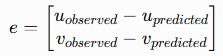

### **2. What does optimization want?**

In [ ]:
We have many observations:

MapPoint 1 → error
MapPoint 2 → error
MapPoint 3 → error
...
MapPoint N → error

We want to change our unknowns so that these errors become as small as possible.

For example:

Current Pose
     ↓
Projection
     ↓
Errors
     ↓
Optimization
     ↓
Better Pose
     ↓
Smaller Errors

So the fundamental goal is:
min Error

More precisely, we usually minimize the sum of squared residuals
where \(x\) contains the variables we're optimizing.

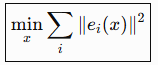

### **3. What are the variables?**

This is extremely important for everything that comes later.

In SLAM, our unknowns can include:

Camera poses
$$ T_1,T_2,\dots,T_n $$
3D MapPoints
$$ P_1,P_2,\dots,P_m $$

So optimization may try to find:

In [ ]:
Best Camera Poses
        +
Best 3D MapPoints

such that the observations are explained as well as possible.

And you already know what this is called when we optimize both:

**Bundle Adjustment 😎**

### **4. Why "nonlinear"?**

Here's the key.

Our projection contains division:

$$ u=f_x\frac{X}{Z}+c_x $$

and:

$$ X,Y,Z $$

depend on the camera pose.

So the relationship between:

In [ ]:
Pose / MapPoint
        ↓
Pixel

is **nonlinear**.

Therefore our error function is nonlinear:

$$ e(x) $$

and we can't generally solve it with one simple linear equation.

Hence:

**Nonlinear Optimization**
	​


### **5. A simple analogy**

Imagine you're standing somewhere on a mountain.

You want to reach the lowest point.

You don't know the entire mountain perfectly.

So you:

In [ ]:
Look around
   ↓
Find a downhill direction
   ↓
Take a small step
   ↓
Look again
   ↓
Take another step
   ↓
...

Eventually:

In [ ]:
        Error
          ↓
       smaller
          ↓
       smaller
          ↓
       smaller
          ↓
        minimum

Optimization algorithms do something conceptually similar.

They repeatedly update the variables to reduce the cost.

### **6. Cost Function**

Instead of saying:

"I have a bunch of errors."

we usually define a **cost function**:


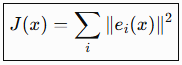

Then the optimization problem becomes:

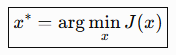

Meaning:

Find the value of \(x\) that produces the smallest cost.

### **7. Tiny SLAM example**

Suppose our current camera pose produces:

Observed:   (520, 340)
Predicted:  (518, 337)

Then:

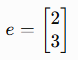

Squared error:

$$ 2^2+3^2=13 $$

Now optimization slightly changes the camera pose.

Suppose the new prediction becomes:

Observed:   (520,340)
Predicted:  (519.5,339.5)

Then:

$$ e= \begin{bmatrix} 0.5\\ 0.5 \end{bmatrix} $$

and:

$$ 0.5^2+0.5^2=0.5 $$

🔥 Much smaller.

That's what optimization is doing.

### **8. Where Lie Groups enter the story**

Remember our previous topic?

We said we don't want to arbitrarily do:

image.png

Instead we use a small Lie-algebra update:

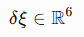

and:

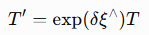

So now our optimization loop is:

In [ ]:
Current Pose
     ↓
Small 6D update δξ
     ↓
Update SE(3) pose
     ↓
Project MapPoints
     ↓
Calculate residuals
     ↓
Calculate cost
     ↓
Choose better δξ
     ↓
Repeat

### **The big picture**

In [ ]:
You already know:

MapPoint + Pose
       ↓
   Projection
       ↓
Predicted pixel
       ↓
Observed pixel
       ↓
 Reprojection Error

Optimization adds:

Reprojection Errors
       ↓
   Cost Function
       ↓
    Minimize
       ↓
Change Pose / MapPoints
       ↓
Smaller Reprojection Errors

And later:

Nonlinear Optimization
          ↓
   Gauss-Newton /
   Levenberg-Marquardt
          ↓
         g2o
          ↓
 Vertex + Edge
          ↓
Bundle Adjustment

### **Quick Check**


Answer these in English:



**Q1. What is a residual in our SLAM problem?**



The difference between the observed pixel and the predicted pixel.

**Q2. What is the goal of nonlinear optimization?**

To minimize the error.


**Q3. Why is the camera projection problem nonlinear?**


Because projection contains division by depth, and the 3D camera coordinates depend on the pose.

**Q4. What is a cost function?**


A function that combines the residuals into one value that we want to minimize.

**Q5. In SLAM, what variables can we optimize?**

Camera poses and 3D MapPoints.


**Q6. ⭐ Complete:**

MapPoint + Camera Pose
          ↓
      Projection
          ↓
Predicted pixel
          ↓
Observed pixel + Predicted pixel
          ↓
        ______
          ↓
   Cost Function
          ↓
      Minimize

Once you've answered these, we'll do Gauss-Newton in a very intuitive way—that's the next key piece before g2o. 😎🔥

Reprojection Error.

### **Gauss-Newton — The Intuition**



Suppose we have only one variable:

$$
x
$$

and error:

$$
e(x)
$$

We want to change \(x\) slightly:

$$
x' = x+\Delta x
$$

but the question is:

> **How much should we change \(x\)?**




This is where the **Jacobian** comes in.


1. Jacobian in simple language:

Jacobian is saying that:

> **If I slightly change my variable, how much does the error change?**

Meaning approximately:

$$
J=\frac{\partial e}{\partial x}
$$

for example if:

$$
J=3
$$

It means:

> A small change in \(x\) produces roughly 3 times that change in the error.

---

2. Gauss-Newton

Gauss-Newton uses this very **local linear approximation**.

Instead of grappling directly with the nonlinear function:

```text
Nonlinear error function
        ↓
   locally approximate
        ↓
      Linear
        ↓
Calculate Δx
        ↓
Update x
        ↓
Repeat
```

Its famous formula:

$$
\boxed{
J^TJ\Delta x=-J^Te
}
$$

And then:

$$
\boxed{x\leftarrow x+\Delta x}
$$


---



### 🧠 The most important image



```text
Current estimate
      ↓
Calculate residual e
      ↓
Calculate Jacobian J
      ↓
Find small update Δx
      ↓
Update estimate
      ↓
Calculate residual again
      ↓
Repeat
```




**Q1.**

In optimization, what does the **Jacobian** tell us?



It tells us how a small change in the optimization variables changes the residual/error.


 **Q2.**

Why do we use a local linear approximation?



Because the original problem is nonlinear, so we approximate it as linear around the current estimate to make the problem easier to solve.


 **Q3.**

What does Gauss-Newton calculate?



Because the original problem is nonlinear, so we approximate it as linear around the current estimate to make the problem easier to solve.

 **Q4.**

After finding \(\Delta x\), what do we do with it?

We apply the update to our current estimate and repeat the optimization process.

So the whole thing is:

In [ ]:
Current estimate
      ↓
Calculate residual
      ↓
Calculate Jacobian
      ↓
Find Δx
      ↓
Update estimate
      ↓
Repeat

## **g2o — Graph Optimization**



In [ ]:
g2o — Vertex / Edge

In [ ]:
Vertex = unknown / state

Edge = constraint / measurement

In [ ]:
Graph
 ├── Vertices
 └── Edges

**Why do we need it?**

SLAM produces many noisy pose and landmark estimates. We need an optimization framework to refine all variables simultaneously.

**Intuition**

Imagine a spider web.

Every node pulls on the others through constraints.

Optimization finds the configuration where all constraints are as consistent as possible

**What is it?**

g2o is a graph optimization framework widely used in robotics and SLAM.

**Mathematical Idea**

Represent the problem as a graph.

Vertices

↓

Unknown variables

Edges

↓

Measurement constraints

Optimization minimizes the total error.

**Inputs / Outputs**

**Input**
* Vertices
* Edges
* Initial estimates
**Output**
* Optimized variables

**Syntax**

**Example**

In [ ]:
optimizer.optimize(10);

**Common Mistakes**

* Poor initial estimates
* Wrong edge definitions
* Missing robust kernels

**SLAM Example**


Local Bundle Adjustment

Pose Graph Optimization

Loop Closure

**Key Takeaways**

* Vertices = variables
* Edges = constraints
* Optimize the entire graph

**Interview Questions**

* Why is graph optimization suitable for SLAM?
* What are vertices and edges?

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

Vertex

Edge

Optimization

The name sounds intimidating, but the basic idea is actually very clean.

g2o represents our optimization problem as a **graph**.

There are two fundamental things:

```text
VERTEX = what we want to estimate

EDGE   = what constrains those estimates
```

That's the entire starting point.

---

### **1. Vertex**

A **Vertex** represents an unknown variable.

In SLAM, examples are:

```text
Camera Pose
      ↓
   Vertex

3D MapPoint
      ↓
   Vertex
```

For example:

```text
Vertex 1 → Camera Pose
Vertex 2 → Camera Pose
Vertex 3 → 3D MapPoint
Vertex 4 → 3D MapPoint
```

So when we say:

> "Optimize the camera poses and MapPoints"

g2o represents them as **vertices**.

---


### **2. Edge**

An **Edge** represents a measurement/constraint between vertices.

This is where your reprojection error comes in.

Suppose:

```text
Camera Pose
     +
3D MapPoint
     ↓
Projection
     ↓
Predicted pixel
```

We already measured the actual pixel.

Therefore:

```text
Observed pixel
      ↓
measurement

Pose + MapPoint
      ↓
prediction

prediction - measurement
      ↓
     error
```

That error becomes an **edge**.

So:

```text
       Camera Pose
          Vertex
             ●
             |
             |  Edge
             |  reprojection error
             |
             ●
       MapPoint
          Vertex
```

🔥 This is the central idea of **g2o**.

---

### **3. The beautiful connection**

Look at everything we've learned:

```text
3D MapPoint ───────────────┐
                           ↓
Camera Pose ───────────→ Projection
                           ↓
                    Predicted pixel
                           ↓
                    Observed pixel
                           ↓
                  Reprojection Error
```

g2o packages that relationship as:

```text
       Pose Vertex
            ●
            |
            | Reprojection Error
            |
            ●
       Point Vertex
```

Then g2o says:

> "Great. Give me all these vertices and edges, and I'll optimize the graph."

😎

---

### **4. A real SLAM example**

Suppose we have:

```text
Camera Pose 1
Camera Pose 2
MapPoint A
MapPoint B
```

And observations:

```text
Pose 1 sees A
Pose 1 sees B
Pose 2 sees A
Pose 2 sees B
```

Our graph looks conceptually like:

```text
        Pose 1
          ●
        /   \
       /     \
      ●       ●
   Point A   Point B
      \       /
       \     /
        \   /
          ●
        Pose 2
```

Each connection is an observation and therefore produces an error.

g2o tries to adjust the vertices so that **all edges have small errors simultaneously**.

---


### **5. This is Bundle Adjustment**

Now we can finally make the connection:

If our graph contains:

```text
Camera Poses
     +
3D MapPoints
     +
Reprojection Errors
```

and we optimize them together:

$$
\boxed{\text{Bundle Adjustment}}
$$

So:

```text
Bundle Adjustment
        ↓
Optimize
   ┌────┴────┐
Poses      MapPoints
   \        /
    \      /
     Errors
```

And **g2o can be used to perform this optimization.**

---

### **6. Where does Gauss-Newton fit?**

Remember our previous section?

We had:

$$
J^TJ\Delta x=-J^Te
$$

g2o internally builds the optimization problem from:

```text
Vertices
   +
Edges
   ↓
Residuals
   +
Jacobians
   ↓
Optimization
   ↓
Gauss-Newton / Levenberg-Marquardt
```

So we're not learning unrelated things.

We're building one pipeline:

```text
Projection
    ↓
Reprojection Error
    ↓
Optimization Problem
    ↓
g2o Graph
    ↓
Vertices + Edges
    ↓
Jacobians
    ↓
Gauss-Newton / LM
    ↓
Optimized Poses + MapPoints
```

❤️ **This is the big picture I want you to hold onto.**

---



### **Tiny g2o exercise — no code yet**

Let's make sure the concept is solid before we touch C++.

Suppose:

```text
Pose 1 ─────── observes ─────── MapPoint A

Pose 1 = Vertex
MapPoint A = Vertex
Observation = Edge
```

**Q1.**
What does a **Vertex** represent in g2o?

Our unknowns camera pose and MapPoint


**Q2.**
What does an **Edge** represent?

An Edge represents a measurement/constraint and defines the error (residual) produced by that measurement.

**Q3.**
In a visual SLAM graph, what can a Vertex represent?

camera pose and MapPoint

**Q4.**
What does the reprojection-error Edge measure?


Reprojection Error


**Q5.** ⭐
Complete:

```text
Vertex = ______ we want to estimate.

Edge = ______ / constraint that connects measurements to variables.
```

Vertex = an unknown variable we want to estimate.

Edge = measure/ constraint that connects measurements to variables.



**Q6.** 🔥
If we optimize **camera poses + 3D MapPoints simultaneously**, what is this optimization called?



Bundle Adjustment

In [ ]:
       Camera Pose
          Vertex
             ●
             |
             |  Edge
             |  Reprojection Error
             |
             ●
        MapPoint
          Vertex

### **Now let's make g2o concrete**

We're going to build the idea **before** worrying about complicated APIs.

Suppose:

$$
T = \text{camera pose}
$$

and:

$$
P = \text{3D MapPoint}
$$

and we observe pixel:

$$
z=(u,v)
$$

Our edge computes:

$$
e = z-\pi(TP)
$$

where:

* \(TP\) transforms the 3D point into the camera frame.
* \(\pi(\cdot)\) performs projection.
* \(z\) is the observed pixel.
* \(e\) is the reprojection error.

So the Edge is basically saying:

> **"Given these vertices, how wrong is our prediction?"**

---

### **g2o's job**

We give g2o:

```text
Vertices:
    Pose
    MapPoints

Edges:
    Observations / reprojection constraints
```

Then:

```text
        g2o
         ↓
   Build optimization
         ↓
   Calculate errors
         ↓
     Jacobians
         ↓
   Gauss-Newton / LM
         ↓
    Update vertices
         ↓
 Optimized Pose + MapPoints
```

That's it.

**g2o is not the SLAM algorithm.**

It's an **optimization framework** that we use to solve the optimization problem inside our SLAM system.

That's a VERY important distinction.

---

### **Tiny g2o-style exercise**

Before actual g2o code, let's manually describe one edge.

We have:

```text
Pose:
T

MapPoint:
P = (2, 1, 5)

Observed pixel:
z = (520, 340)
```

Suppose our current pose predicts:

```text
Predicted pixel:
(518, 337)
```

Then:

$$
e=z-\hat z
$$



**Q1.**

What is the reprojection error \(e\)?



$$
e =
\begin{bmatrix}
520-518\\
340-337
\end{bmatrix}
=
\boxed{\begin{bmatrix}2\\3\end{bmatrix}}
$$

**Q2.**

Which two things are the **vertices** involved in this observation?



Pose + MapPoint

**Q3.**

What is the **measurement** stored by the edge?




The measurement is **the observed pixel**, not the error.

$$
\boxed{z=(520,340)}
$$

The **edge computes the error** by comparing this measurement with the predicted pixel.

**Q4.**

What does the edge do with the vertices and measurement?

The Edge computes the residual/error; the optimizer then tries to minimize it.

---



### **Now let's make the whole g2o picture crystal clear**

This is the part I want you to really understand before we touch code.

Suppose:

```text
          Pose
       Vertex ●
             |
             |  observation
             |  Edge
             |
       Vertex ●
        MapPoint
```

The Edge contains the observed measurement:

$$
z=(u,v)
$$

and knows how to calculate:

$$
\hat z = \pi(TP)
$$

Then:

$$
\boxed{e=z-\hat z}
$$

So:

```text
Vertex + Vertex
      ↓
     Edge
      ↓
 Prediction
      ↓
Compare with measurement
      ↓
    Residual
```

And g2o adjusts the **vertices**, not the measurement.

---

### **One VERY important distinction**

This will save you from confusion later:

### Edge does NOT mean "the error itself."

More precisely:

> **An Edge represents a measurement/constraint and defines how to compute its residual from the connected vertices.**

For our visual SLAM problem:

```text
Measurement = observed pixel
Residual    = observed pixel - predicted pixel
```

---




## **Bundle Adjustment (BA)**



In [ ]:
Camera Poses
     +
3D Map Points
     ↓
Reprojection Error
     ↓
Joint Optimization

**Why do we need it?**

Even small pose errors accumulate over time.

Bundle Adjustment jointly refines camera poses and landmark positions to minimize reprojection error.

**Intuition**

Imagine every camera and every landmark connected by elastic strings.

Optimization moves both until all projected points align as closely as possible with the observed image points.

**What is it?**

Bundle Adjustment is a nonlinear least-squares optimization that simultaneously optimizes camera poses and 3D landmarks.

**Mathematical Idea**

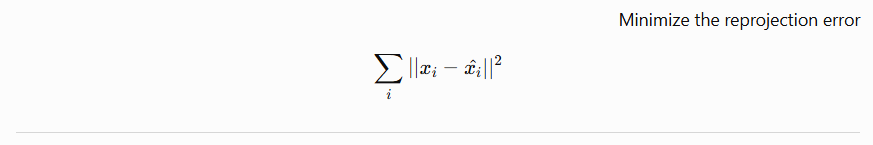

**Inputs / Outputs**

**Input**
* Initial camera poses
* Initial landmarks
* Feature observations
**Output**
* Optimized poses
* Optimized landmarks

**Syntax**

**Example**

In [ ]:
optimizer.optimize(...)

**Common Mistakes**

* Poor initialization
* Too many outliers
* Optimizing unnecessary variables

**SLAM Example**


Local BA

Global BA

Sliding Window BA

**Key Takeaways**

* Joint optimization
* Minimize reprojection error
* Improves map accuracy

**Interview Questions**

* Why optimize poses and landmarks together?
* What is reprojection error?
* Why is BA nonlinear?

In [ ]:
# Topic

## Why do we need it?

## Syntax

## Example

## Common mistakes

## SLAM example

## Key takeaways

## Exercises

This is where the pieces finally come together.

Imagine we have:

```text
Pose 1 ───┬──── MapPoint A
          │
          └──── MapPoint B

Pose 2 ───┬──── MapPoint A
          │
          └──── MapPoint B

Pose 3 ───┬──── MapPoint A
          │
          └──── MapPoint C
```

Every connection is an observation.

Each observation gives us a reprojection error.

So we have **many errors**:

$$
e_1,e_2,e_3,\dots,e_n
$$

Bundle Adjustment asks:

> **What camera poses and 3D MapPoint positions make all these reprojection errors as small as possible?**

Therefore:

$$
\boxed{
\text{BA}=
\text{joint optimization of camera poses and 3D points}
}
$$

using reprojection errors.

---



### **Why is it called "Bundle Adjustment"?**

You don't need the historical detail right now.

Just remember:

> A set of camera rays/bundles is adjusted so that the cameras and 3D points become mutually consistent with the image observations.

For us, the practical definition is enough:

```text
Bundle Adjustment

Optimize:
    Camera Poses
        +
    3D MapPoints

Objective:
    Minimize reprojection error
```

---

### **g2o vs BA**

This distinction is **very important**:

### Bundle Adjustment

is the **optimization problem**.

### g2o

is an **optimization framework/tool** that can solve this kind of problem.

So:

```text
                Bundle Adjustment
                 optimization problem
                        ↓
              represented as a graph
                        ↓
              ┌─────────┴─────────┐
              │                   │
          Vertices              Edges
              │                   │
        Pose / Point       Reprojection errors
              │                   │
              └─────────┬─────────┘
                        ↓
                       g2o
                        ↓
               Gauss-Newton / LM
                        ↓
              Optimized SLAM state
```

🔥 **This is the sentence I want you to remember:**

> **BA is WHAT we are optimizing; g2o is one tool we can use to DO the optimization.**

---



### **Tiny BA Exercise**

Suppose we have:

```text
2 Camera Poses
3 MapPoints
6 observations
```

Each observation creates one reprojection-error edge.





**Q1.**

How many **pose vertices** do we have?

2

**Q2.**

How many **MapPoint vertices**?



3

**Q3.**

How many **reprojection edges**?



6

Assuming each observation creates one edge.

**Q4.**

What variables does BA optimize?



The **edges represent the errors/constraints**, but BA optimizes the **variables represented by the vertices**:

> **Camera poses + 3D MapPoints** ✅

The edges provide the information that tells the optimizer how wrong the current estimates are.

So remember:

```text
Vertices → WHAT we change
Edges    → HOW we measure the error
```

🔥 This is probably the single most useful g2o distinction.


**Q5.** ⭐

If the observed pixel is:

$$
(500,300)
$$

and the predicted pixel is:

$$
(497,304)
$$

what is the residual?

---

Observed:

$$
(500,300)
$$

Predicted:

$$
(497,304)
$$

Therefore:

$$
e=
(500-497,\;300-304)
$$

$$
\boxed{e=(3,-4)}
$$


```text
Residual       = (3, -4)
Squared error  = 25
Error magnitude = 5
```

---

### **🧠 One final g2o mental model**

Before we move on, lock this in:

```text
              g2o Graph

       Pose Vertex       MapPoint Vertex
             ●                 ●
              \               /
               \             /
                \           /
                 ●─────────●
                    Edge
                 Observation
                     ↓
              Reprojection
                  Error
```

**Vertex:** an unknown we can change.

**Edge:** a measurement/constraint that tells us how good or bad the current vertices are.

**Optimizer:** changes the vertices to reduce the total edge errors.

And therefore:

$$
\boxed{\text{BA optimizes poses + MapPoints}}
$$

using

$$
\boxed{\text{reprojection-error edges}}
$$

via an optimization framework such as **g2o**.

---



### **Next: Tiny real g2o C++**

**g2o in C++ — Vertex & Edge**

We now know the concept. Let's see how g2o represents it.

**1. The basic g2o graph**

Imagine our SLAM problem:

```text
        Camera Pose
        Vertex
           ●
           |
           |  Edge
           |  observed pixel
           |
           ●
        MapPoint
        Vertex
```

In C++, conceptually:

```cpp
Vertex = variable we want to estimate
Edge   = measurement/constraint
```

---

**2. A Vertex**

g2o provides base classes from which we define our optimization variables.

For example, a pose vertex might conceptually look like:

```cpp
class VertexPose : public g2o::BaseVertex<6, Sophus::SE3d>
{
    // ...
};
```

Don't worry about the syntax yet.

Look at this part:

```cpp
BaseVertex<6, Sophus::SE3d>
```

It tells us something important:

```text
6                  → dimension of the update
Sophus::SE3d       → type of the estimated value
```

So:

```text
VertexPose
    ↓
stores a camera pose
    ↓
SE(3)
    ↓
6-DoF update
```

This connects **g2o + Lie Groups** directly. 🔥

---

**3. A MapPoint Vertex**

A 3D point has three coordinates:

$$
P=(X,Y,Z)
$$

So conceptually:

```cpp
class VertexPoint : public g2o::BaseVertex<3, Eigen::Vector3d>
{
    // ...
};
```

Here:

```text
3                  → 3D update
Eigen::Vector3d    → stored value
```

So we have:

```text
Pose Vertex
    ↓
SE3d
6 DoF

MapPoint Vertex
    ↓
Vector3d
3 DoF
```

---

**4. the Edge 🔥**

Our visual observation is:

```text
3D MapPoint
      +
Camera Pose
      ↓
Projection
      ↓
Predicted pixel
```

and we know the observed pixel:

$$
z=(u,v)
$$

The edge therefore has a **2-dimensional measurement**:

```cpp
Eigen::Vector2d measurement;
```

because a pixel contains:

```text
u
v
```

Conceptually, our edge connects:

```text
Pose Vertex
     ●
     |
     |  Reprojection Edge
     |
     ●
MapPoint Vertex
```

and calculates:

$$
e=z-\pi(TP)
$$

---

**5. Why is the edge 2D?**

This is a beautiful little detail.

Our observation is:

$$
(u,v)
$$

Therefore the residual is:

$$
e=
\begin{bmatrix}
e_u\\
e_v
\end{bmatrix}
$$

So:

$$
\boxed{\text{Edge dimension}=2}
$$

because the measurement lives in 2D image space.

---

**6. The complete graph**

Suppose we have:

```text
2 poses
3 MapPoints
6 observations
```

Then:

```text
Vertices:
    Pose 1
    Pose 2
    Point 1
    Point 2
    Point 3

Edges:
    Observation 1
    Observation 2
    ...
    Observation 6
```

The optimizer sees:

```text
              P1 ●
                 / \
                /   \
          Edge /     \ Edge
              /       \
       Pose1 ●         ● Pose2
              \       /
          Edge \     / Edge
                \   /
                 \ /
              P2 ●
```

and asks:

> **What values of these vertices minimize the total error of all these edges?**

That is our BA problem.

---

**7. The part that usually confuses people**

There are **three different things**:

**Measurement**

What the camera actually observed:

$$
z=(520,340)
$$

**Prediction**

What our current pose + MapPoint predict:

$$
\hat z=\pi(TP)
$$

**Residual**

Their difference:

$$
e=z-\hat z
$$

So:

```text
Measurement
     ↓
 observed pixel

Vertices
     ↓
 Pose + MapPoint
     ↓
 prediction

Measurement - prediction
     ↓
 residual
```

The **Edge contains/uses the measurement and computes the residual from the vertices.**

Then g2o minimizes those residuals.

---



### **Tiny g2o C++ exercise**

```cpp
// Camera pose
Sophus::SE3d pose;

// 3D MapPoint
Eigen::Vector3d point;

// Observed pixel
Eigen::Vector2d measurement;

// Prediction
Eigen::Vector2d prediction;

// Reprojection error
Eigen::Vector2d error;
```

 **Q1.**

What should `prediction` represent?

Prediction = the pixel where the current pose and 3D MapPoint say the point should appear.

 **Q2.**

Write the mathematical expression for `prediction` using:

```text
pose
point
camera intrinsics K
```



$$
\boxed{\text{prediction} = \pi(K(RP+t))}
$$

In steps:

```text
MapPoint P
   ↓
Transform using pose T
   ↓
Camera coordinates Pc = R P + t
   ↓
Project using K
   ↓
pixel prediction (u, v)
```

So in our C++ context:

```cpp
prediction = project(K, pose, point);
```


**Q3.**

Write the C++ expression for the reprojection error:

```cpp
error = ___________________;
```


error = measurement - prediction;


 **Q4.** ⭐

Which of these are **vertices**?

```text
pose
point
measurement
prediction
error
```


> pose
> point

Perfect.

| Thing         | Role              |
| ------------- | ----------------- |
| `pose`        | 🟢 Vertex         |
| `point`       | 🟢 Vertex         |
| `measurement` | 🔵 Measurement    |
| `prediction`  | 🟡 Computed value |
| `error`       | 🔴 Residual       |

And remember our golden rule:

> **Vertices = what we optimize.**
> **Measurement = what the camera actually observed.**
> **Error = observed − predicted.**



 **Q5.**

Which one is the **measurement**?

What the camera actually observed (in pixel)

For example:

```cpp
measurement = Eigen::Vector2d(500, 300);
```

means:

> "The feature was actually detected at pixel `(500,300)`."

While:

```cpp
prediction = Eigen::Vector2d(497, 304);
```

means:

> "Given our current pose and MapPoint estimate, we expected it at `(497,304)`."

Therefore:

```cpp
error = measurement - prediction;
       = (500,300) - (497,304)
       = (3,-4)
```




### **Real g2o Edge Structure**

Now we're going to connect everything you've learned:

**Vertex → Edge → Error → Jacobian → Optimizer**

A simplified visual SLAM reprojection edge looks conceptually like this:

```cpp
class EdgeProjection
    : public g2o::BaseBinaryEdge<2, Eigen::Vector2d,
                                VertexPose, VertexPoint>
{
public:

    void computeError() override
    {
        VertexPose* pose =
            static_cast<VertexPose*>(_vertices[0]);

        VertexPoint* point =
            static_cast<VertexPoint*>(_vertices[1]);

        // Current estimates
        Sophus::SE3d T = pose->estimate();
        Eigen::Vector3d P = point->estimate();

        // Predict pixel
        Eigen::Vector3d Pc = T * P;

        double u = fx * Pc[0] / Pc[2] + cx;
        double v = fy * Pc[1] / Pc[2] + cy;

        Eigen::Vector2d prediction(u, v);

        // Residual
        _error = _measurement - prediction;
    }
};
```

---

**1. What is `BaseBinaryEdge`?**

Look at:

```cpp
g2o::BaseBinaryEdge<2, Eigen::Vector2d,
                    VertexPose, VertexPoint>
```

There are four important pieces:

```text
2
↓
error dimension

Eigen::Vector2d
↓
measurement type

VertexPose
↓
first connected vertex

VertexPoint
↓
second connected vertex
```

Why **binary** edge?

Because this edge connects **two vertices**:

```text
Pose Vertex ───── Edge ───── MapPoint Vertex
```

That's exactly our reprojection constraint.

---

**2.** `_vertices`

Inside the edge:

```cpp
_vertices[0]
_vertices[1]
```

represent the vertices connected to the edge.

We defined:

```cpp
VertexPose
VertexPoint
```

So:

```cpp
_vertices[0] → Pose
_vertices[1] → MapPoint
```

That's why we can write:

```cpp
VertexPose* pose =
    static_cast<VertexPose*>(_vertices[0]);
```

and:

```cpp
VertexPoint* point =
    static_cast<VertexPoint*>(_vertices[1]);
```

---

**3.** `estimate()`

Now this is very important.

```cpp
pose->estimate()
```

means:

> Give me the **current estimated value** stored inside this vertex.

For example:

```cpp
Sophus::SE3d T = pose->estimate();
```

gets the current camera pose.

And:

```cpp
Eigen::Vector3d P = point->estimate();
```

gets the current 3D MapPoint.

So:

```text
Vertex
  ↓
estimate()
  ↓
current value
```

---

**4.** Computing the prediction

Now:

```cpp
Eigen::Vector3d Pc = T * P;
```

We transform the MapPoint from world coordinates into camera coordinates.

Then:

```cpp
u = fx * X/Z + cx
v = fy * Y/Z + cy
```

So:

```cpp
prediction = π(TP)
```

Exactly the projection equation we learned earlier. ❤️

---

**5.** `_measurement`

Remember the actual observation?

```cpp
measurement = (500,300)
```

g2o stores that inside the edge:

```cpp
_measurement
```

So `_measurement` means:

> **What the camera actually observed.**

---

**6.** `_error`

Finally:

```cpp
_error = _measurement - prediction;
```

This is the heart of the edge.

Mathematically:

$$
\boxed{
e = z-\pi(TP)
}
$$

For example:

```text
measurement = (500,300)
prediction  = (497,304)

error = (3,-4)
```

The edge therefore tells g2o:

> "With the current Pose and MapPoint estimates, we're off by `(3,-4)` pixels."

---

**⭐ And now the really important part**

Remember our optimization loop?

```text
Current Pose + MapPoint
          ↓
       Projection
          ↓
      Prediction
          ↓
 Measurement - Prediction
          ↓
        Residual
          ↓
       Jacobian
          ↓
       Δx update
          ↓
   Better Pose + MapPoint
```

**The Edge is where much of this measurement/residual logic lives.**

And the optimizer doesn't randomly change things.

It asks the edges:

> "If I slightly change these vertices, how does your error change?"

That's where the **Jacobian** comes in.

---

### **Tiny Exercise — before Jacobians**

Answer these 5:

**Q1.** In this edge:

```cpp
BaseBinaryEdge<2, Eigen::Vector2d,
               VertexPose, VertexPoint>
```

why is the first `2` there?



error dimension (in pixel)

**Q2.** What does:

```cpp
pose->estimate()
```

give us?



the current estimated value stored inside this vertex.


**Q3.** What does:

```cpp
_measurement
```

represent?


The observation that g2o stores that inside the edge



**Q4.** Complete:

$$
e = \_\_\_\_\_\_ - \pi(\_\_\_\_\_\_)
$$



e = z - π (T P)

**Q5. ⭐**
Suppose:

```text
measurement = (500,300)
prediction  = (497,304)
```

Decreases

### **Jacobian**

We've already learned the theory:

> **Jacobian tells us how the residual changes when we slightly change the variables.**

Now let's put that inside g2o.

Suppose our edge has:

```text
Pose Vertex ─────┐
                 │
                 ├── Edge
                 │
Point Vertex ────┘
```

The edge has:

$$
e = z-\pi(TP)
$$

But the optimizer needs to know:

> **"If I slightly change the Pose, how will this error change?"**

and:

> **"If I slightly change the MapPoint, how will this error change?"**

That's exactly what the Jacobians tell it.

---

**1. Two Jacobians**

Because our edge connects **two vertices**, we have two Jacobians:

$$
J_{pose} = \frac{\partial e}{\partial pose}
$$

and

$$
J_{point} = \frac{\partial e}{\partial P}
$$

Conceptually:

```text
                  Edge
                   │
          ┌────────┴────────┐
          ↓                 ↓
   Jacobian wrt Pose   Jacobian wrt Point
          ↓                 ↓
 "How does error      "How does error
 change if Pose       change if Point
 changes?"            changes?"
```

---

**2. And this appears in g2o as...**

The function:

```cpp
void linearizeOplus()
```

This is the g2o function where we provide the Jacobians.

So now the pieces connect:

```text
computeError()
      ↓
Calculate:
e = measurement - prediction

linearizeOplus()
      ↓
Calculate:
Jacobian wrt Pose
Jacobian wrt Point

optimizer
      ↓
Use error + Jacobians
      ↓
Calculate Δx
      ↓
Update vertices
```

❤️ **This is the exact bridge between the Gauss-Newton equation we learned and g2o.**

---



### **Questions**

Suppose we have:

$$
e = z-\pi(TP)
$$

and we slightly change the **Pose**.


**Q1.** What does

$$
\frac{\partial e}{\partial pose}
$$

tell us?


If I slightly change the Pose, how will this error change?

**Q2.** What does

$$
\frac{\partial e}{\partial P}
$$

tell us?



If I slightly change the P, how will this error change?

**Q3.** Why do we need **two** Jacobians for this edge?

Because our edge connects two vertices

### **Jacobian in our Reprojection Edge**

Our residual is:

$$
e =
\begin{bmatrix}
e_u\\
e_v
\end{bmatrix}
=
z-\pi(TP)
$$

The residual has **2 dimensions**.

The Pose has **6 DOF**:

$$
\xi =
\begin{bmatrix}
\xi_1&\xi_2&\xi_3&\xi_4&\xi_5&\xi_6
\end{bmatrix}^T
$$

Therefore:

$$
\boxed{
J_{pose}=\frac{\partial e}{\partial \xi}
}
$$

has shape:

$$
\boxed{2\times6}
$$

Why?

```text
             6 pose parameters
          ↓ ↓ ↓ ↓ ↓ ↓
error u →  × × × × × ×
error v →  × × × × × ×
```

So:

```text
J_pose = [ 2 × 6 ]
```

---


### **MapPoint Jacobian**

A MapPoint has 3 coordinates:

$$
P=
\begin{bmatrix}
X\\Y\\Z
\end{bmatrix}
$$

Therefore:

$$
\boxed{
J_{point}=\frac{\partial e}{\partial P}
}
$$

has shape:

$$
\boxed{2\times3}
$$

```text
             X   Y   Z
          ↓   ↓   ↓
error u → ×   ×   ×
error v → ×   ×   ×
```

So:

```text
J_point = [ 2 × 3 ]
```

---



### **This is worth pausing on**

We haven't derived the numbers yet.

Just understand the dimensions:

| Variable           | Dimension | Jacobian |
| ------------------ | --------: | -------: |
| Reprojection error |         2 |        — |
| Pose               |         6 |  **2×6** |
| MapPoint           |         3 |  **2×3** |

And this is exactly why earlier we learned:

> **SE(3) → 6 DOF**

Because that 6 eventually appears directly in the **Pose Jacobian**.

That's a beautiful connection. 😄

---



### Tiny exercise



**Q1.** Why is the Pose Jacobian `2×6`?


e = (eu, ev)

and 6 DOF for Pose

so: changes of eu and ev

wrt all these 6 directions

2*6

**Q2.** Why is the MapPoint Jacobian `2×3`?

in the same way: 3 is dimension of MapPoint

so: 2 * 3

**Q3.** If our edge had a **1-dimensional measurement** instead of a pixel `(u,v)`, what would the Pose Jacobian dimension become?


Pose Jacobian: 6 and MapPoint Jacobian: 3

### **Now let's derive the projection Jacobian 🧠**

This is the part that often looks scary in SLAM code, but we're going to make it very mechanical.

First, forget Pose for one minute.

Suppose the point is already in **camera coordinates**:

$$
P_c =
\begin{bmatrix}
X\\Y\\Z
\end{bmatrix}
$$

Projection is:

$$
u=f_x\frac{X}{Z}+c_x
$$

$$
v=f_y\frac{Y}{Z}+c_y
$$

We want to know:

> If \(X,Y,Z\) change slightly, how do \(u,v\) change?

So we calculate:

$$
\frac{\partial(u,v)}{\partial(X,Y,Z)}
$$

The result is:

$$
\boxed{
J_{\pi}
=
\begin{bmatrix}
\frac{f_x}{Z} & 0 & -\frac{f_xX}{Z^2}\\
0 & \frac{f_y}{Z} & -\frac{f_yY}{Z^2}
\end{bmatrix}
}
$$

Notice its dimensions:

```text
       X       Y       Z
      ↓       ↓       ↓
u →  [  fx/Z    0    -fxX/Z² ]
v →  [   0    fy/Z   -fyY/Z² ]
```

So:

$$
\boxed{J_\pi=2\times3}
$$

---

**Why is this useful?**

Because now we have a mathematical answer to:

> "If I slightly move the 3D point in camera coordinates, how does its pixel position change?"

For example:

* change \(X\) → affects \(u\)
* change \(Y\) → affects \(v\)
* change \(Z\) → affects **both** \(u\) and \(v\)

And that last one is especially important because of **perspective**.

---

**Q1.**

Given

$$
u=f_x\frac{X}{Z}+c_x
$$

what is:

$$
\frac{\partial u}{\partial X} \; ?
$$


We have:

$$
u=f_x\frac{X}{Z}+c_x
$$

Here \(f_x\) و \(c_x\) are **constants**. We differentiate with respect to \(X\) or \(Z\).


$$
\frac{\partial u}{\partial X}
$$

Since:

$$
u=f_x\frac{X}{Z}+c_x
$$

and \(Z\) is constant when differentiating with respect to \(X\):

$$
\boxed{
\frac{\partial u}{\partial X}=\frac{f_x}{Z}
}
$$


**Q2.**

What is:

$$
\frac{\partial u}{\partial Z} \; ?
$$


$$
\frac{\partial u}{\partial Z}
=
\frac{\partial}{\partial Z}
\left(f_x\frac{X}{Z}+c_x\right)
$$

Since:

$$
\frac{X}{Z}=X Z^{-1}
$$

we get:

$$
\frac{\partial}{\partial Z}(XZ^{-1})
=
-XZ^{-2}
$$

Therefore:

$$
\boxed{
\frac{\partial u}{\partial Z}
=
-\frac{f_xX}{Z^2}
}
$$


**Q3.**

Given

$$
v=f_y\frac{Y}{Z}+c_y
$$

what is:

$$
\frac{\partial v}{\partial Y} \; ?
$$

We'll build the matrix ourselves from these pieces. 🚀


Similarly:

$$
v=f_y\frac{Y}{Z}+c_y
$$

Therefore:

$$
\boxed{
\frac{\partial v}{\partial Y}
=
\frac{f_y}{Z}
}
$$

**So our three pieces are:**

$$
\boxed{
\frac{\partial u}{\partial X}=\frac{f_x}{Z}
}
$$

$$
\boxed{
\frac{\partial u}{\partial Z}=-\frac{f_xX}{Z^2}
}
$$

$$
\boxed{
\frac{\partial v}{\partial Y}=\frac{f_y}{Z}
}
$$

And now we're **very close** to the complete projection Jacobian:

$$
J_\pi=
\begin{bmatrix}
\frac{f_x}{Z} & 0 & -\frac{f_xX}{Z^2}\\
0 & \frac{f_y}{Z} & -\frac{f_yY}{Z^2}
\end{bmatrix}
$$


**Q4.**

$$
\frac{\partial u}{\partial Y} = ?
$$


**Q5.**

$$
\frac{\partial v}{\partial X} = ?
$$

Hint: Look at the projection equations and ask: **does \(u\) directly depend on \(Y\)? Does \(v\) directly depend on \(X\)?**


0

Because:

$$
u=f_x\frac{X}{Z}+c_x
$$

doesn't directly contain \(Y\), so:

$$
\boxed{\frac{\partial u}{\partial Y}=0}
$$

And:

$$
v=f_y\frac{Y}{Z}+c_y
$$

doesn't directly contain \(X\), so:

$$
\boxed{\frac{\partial v}{\partial X}=0}
$$

Therefore, we've now built the whole projection Jacobian:

$$
\boxed{
J_\pi=
\begin{bmatrix}
\frac{f_x}{Z} & 0 & -\frac{f_xX}{Z^2}\\[4pt]
0 & \frac{f_y}{Z} & -\frac{f_yY}{Z^2}
\end{bmatrix}
}
$$

### **🧠 Read it rather than memorize it**

```text
             X          Y           Z
          ─────────────────────────────
u       |  fx/Z        0       -fxX/Z²
v       |   0         fy/Z     -fyY/Z²
```

So:

* \(X\) changes → directly affects \(u\)
* \(Y\) changes → directly affects \(v\)
* \(Z\) changes → affects **both** \(u\) and \(v\)

And that's why the matrix is **2×3**:

$$
\underbrace{2}_{u,v}
\times
\underbrace{3}_{X,Y,Z}
$$

---

### **From 3D Point → Pose Jacobian**

We already have:

$$
P_c = TP
$$

and the projection Jacobian:

$$
J_\pi=\frac{\partial (u,v)}{\partial(X,Y,Z)}
$$

which is:

$$
J_\pi=
\begin{bmatrix}
\frac{f_x}{Z} & 0 & -\frac{f_xX}{Z^2}\\
0 & \frac{f_y}{Z} & -\frac{f_yY}{Z^2}
\end{bmatrix}
$$

This tells us:

> **How does the pixel change if the camera-coordinate point \(P_c\) changes?**

But the optimizer doesn't directly optimize \(X,Y,Z\) for the Pose vertex.

It optimizes a **6-DOF pose increment**:

$$
\delta\xi =
\begin{bmatrix}
\delta t_x\\
\delta t_y\\
\delta t_z\\
\delta\theta_x\\
\delta\theta_y\\
\delta\theta_z
\end{bmatrix}
$$

So we need another Jacobian:

$$
\frac{\partial P_c}{\partial \xi}
$$

---

**1. First: translation**

Imagine:

$$
P_c=
\begin{bmatrix}
X\\Y\\Z
\end{bmatrix}
$$

and we make a tiny translation:

$$
\delta t=
\begin{bmatrix}
\delta t_x\\
\delta t_y\\
\delta t_z
\end{bmatrix}
$$

Then:

$$
P_c' =
\begin{bmatrix}
X+\delta t_x\\
Y+\delta t_y\\
Z+\delta t_z
\end{bmatrix}
$$

So:

$$
\frac{\partial P_c}{\partial t}
=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
$$

or simply:

$$
\boxed{I_{3\times3}}
$$

That's intuitive:

```text
change tx → X changes
change ty → Y changes
change tz → Z changes
```

---

**2. Rotation**

Now rotation is more interesting.

For a **small rotation**:

$$
R' \approx (I+[\delta\theta]_\times)R
$$

The cross-product matrix is:

$$
[\delta\theta]_\times
=
\begin{bmatrix}
0&-\delta\theta_z&\delta\theta_y\\
\delta\theta_z&0&-\delta\theta_x\\
-\delta\theta_y&\delta\theta_x&0
\end{bmatrix}
$$

For a point, the small rotational change produces:

$$
\delta P_c
\approx
-[P_c]_\times\delta\theta
$$

where:

$$
[P_c]_\times=
\begin{bmatrix}
0&-Z&Y\\
Z&0&-X\\
-Y&X&0
\end{bmatrix}
$$

Therefore:

$$
\frac{\partial P_c}{\partial\theta}
=
-[P_c]_\times
$$

---

**3. Put translation + rotation together**

Our pose has 6 DOF:

```text
translation       rotation
 tx ty tz         θx θy θz
 ─────────        ─────────
      3               3
```

Therefore:

$$
\boxed{
\frac{\partial P_c}{\partial\xi}
=
\begin{bmatrix}
I & -[P_c]_\times
\end{bmatrix}
}
$$

This is:

$$
3\times6
$$

---

**4. Now comes the beautiful part**

We have:

$$
\frac{\partial e}{\partial P_c}
$$

and:

$$
\frac{\partial P_c}{\partial\xi}
$$

So by the **chain rule**:

$$
\boxed{
\frac{\partial e}{\partial\xi}
=
\frac{\partial e}{\partial P_c}
\frac{\partial P_c}{\partial\xi}
}
$$

Therefore:

$$
\boxed{
J_{pose}
=
J_\pi
\begin{bmatrix}
I&-[P_c]_\times
\end{bmatrix}
}
$$

Dimensions:

```text
        2×3       3×6
          ↓         ↓
             2×6
```

And suddenly our earlier statement:

> **Pose Jacobian = 2×6**

has a mathematical reason. 🔥

---

**⭐ The whole chain**

This is the part I really want you to see:

```text
Pose ξ
  ↓
3D point in camera coordinates Pc
  ↓
Projection π
  ↓
pixel (u,v)
  ↓
error e
```

And the derivatives flow backward:

```text
             ∂Pc/∂ξ
Pose ─────────────────→ Pc
                         │
                         │ ∂pixel/∂Pc
                         ↓
                       pixel
                         │
                         ↓
                       error
```

So the Pose Jacobian is essentially:

$$
\boxed{
\text{Pose Jacobian}
=
\text{Projection Jacobian}
\times
\text{Pose-to-point Jacobian}
}
$$

---


### **3 tiny questions**

**Q1.** Why is

$$
\frac{\partial P_c}{\partial\xi}
$$

a **3×6** matrix?

The pose has **6 DOF**:

$$
\xi=(t_x,t_y,t_z,\theta_x,\theta_y,\theta_z)
$$

and \(P_c\) has **3 components**:

$$
P_c=(X,Y,Z)
$$

So:

$$
\boxed{\frac{\partial P_c}{\partial \xi}=3\times6}
$$

because we're asking:

> How does each of the **3 coordinates** \(X,Y,Z\) change with respect to each of the **6 pose directions**?


**Q2.** If:

$$
J_\pi = 2\times3
$$

and:

$$
\frac{\partial P_c}{\partial\xi}=3\times6
$$

what is the dimension of their product?


We have:

$$
J_\pi=2\times3
$$

and:

$$
\frac{\partial P_c}{\partial\xi}=3\times6
$$

When multiplying matrices:

$$
(2\times3)(3\times6)
$$

the **inside numbers must match**:

```text
( 2 × 3 ) ( 3 × 6 )
      ↑       ↑
      └───┬───┘
         match
```

Then the **outside numbers remain**:

$$
\boxed{2\times6}
$$

So:

$$
\boxed{
J_\pi
\frac{\partial P_c}{\partial\xi}
=
2\times6
}
$$

And that's exactly our Pose Jacobian.

**Q3.** In your own words, why do we use the **chain rule** here?


Here's the simplest way to say it:

> **The error depends on the pixel, the pixel depends on the 3D camera point, and the 3D camera point depends on the Pose.**

So if we want to know:

> **How does the error change when the Pose changes?**

we have to follow that chain:

$$
\boxed{
Pose
\rightarrow
P_c
\rightarrow
pixel
\rightarrow
error
}
$$

Therefore, we multiply the derivatives along the chain:

$$
\boxed{
\frac{\partial e}{\partial\xi}
=
\frac{\partial e}{\partial P_c}
\frac{\partial P_c}{\partial\xi}
}
$$

That's the chain rule in our SLAM problem.

### **NEXT: linearizeOplus()**

Now we can finally open the door to **actual g2o code**.

Remember our Edge:

```cpp
class EdgeProjection
    : public g2o::BaseBinaryEdge<2, Eigen::Vector2d,
                                VertexPose, VertexPoint>
```

We already understood:

```text
computeError()
      ↓
e = measurement - prediction
```

Now:

```cpp
linearizeOplus()
```

is responsible for calculating the Jacobians.

Conceptually:

```cpp
void linearizeOplus() override
{
    // Jacobian with respect to Pose
    _jacobianOplusXi = J_pose;

    // Jacobian with respect to MapPoint
    _jacobianOplusXj = J_point;
}
```

The names can look scary:

```text
_jacobianOplusXi
_jacobianOplusXj
```

but the idea is simple:

```text
Xi = first vertex  → Pose
Xj = second vertex → MapPoint
```

Therefore:

$$
\boxed{
\_jacobianOplusXi
=
\frac{\partial e}{\partial pose}
}
$$

and:

$$
\boxed{
\_jacobianOplusXj
=
\frac{\partial e}{\partial P}
}
$$

So our Edge now has everything the optimizer needs:

```text
             Edge
              │
      ┌───────┼────────┐
      ↓       ↓        ↓
measurement  error   Jacobians
               │        │
               └────┬───┘
                    ↓
                Optimizer
                    ↓
              ΔPose, ΔPoint
```




### **One important distinction**

`computeError()`:

> **"How wrong are we?"**

`linearizeOplus()`:

> **"If I change the variables a little, how will that error change?"**

And **that** is the information Gauss-Newton needs.



### **MapPoint Jacobian — \(2\times3\)**

We'll do the **easier Jacobian first**.

We already have the reprojection error:

$$
e=z-\pi(P_c)
$$

and:

$$
P_c=(X,Y,Z)
$$

with:

$$
u=f_x\frac{X}{Z}+c_x
$$

$$
v=f_y\frac{Y}{Z}+c_y
$$

We want:

$$
J_{point}
=
\frac{\partial e}{\partial P}
$$

---

**Step 1 — One subtle point ❤️**

Our error is:

$$
e=z-\pi(P_c)
$$

So:

$$
e_u=u_{obs}-u_{pred}
$$

Therefore, when we differentiate the **error**, we get a minus sign:

$$
\frac{\partial e}{\partial P}
=
-\frac{\partial \pi}{\partial P}
$$

Earlier, we calculated the projection Jacobian:

$$
J_\pi=
\begin{bmatrix}
\frac{f_x}{Z} & 0 &-\frac{f_xX}{Z^2}\\
0&\frac{f_y}{Z}&-\frac{f_yY}{Z^2}
\end{bmatrix}
$$

Therefore:

$$
\boxed{
J_{point}=-J_\pi
}
$$

if \(P\) is already expressed in the same coordinate system we're differentiating with respect to.

So:

$$
\boxed{
J_{point}=
\begin{bmatrix}
-\frac{f_x}{Z} & 0 & \frac{f_xX}{Z^2}\\
0&-\frac{f_y}{Z}&\frac{f_yY}{Z^2}
\end{bmatrix}
}
$$

---

**Step 2 — Why the signs changed**

Let's look at just one term.

Suppose:

$$
e_u=u_{obs}-u
$$

and:

$$
u=f_x\frac{X}{Z}+c_x
$$

Then:

$$
\frac{\partial e_u}{\partial X}
=
-\frac{\partial u}{\partial X}
$$

Therefore:

$$
\boxed{
\frac{\partial e_u}{\partial X}
=
-\frac{f_x}{Z}
}
$$

That's where the negative sign comes from.

---

**Step 3 — The complete matrix**

So:

$$
\boxed{
J_{point}
=
\begin{bmatrix}
-\frac{f_x}{Z} & 0 & \frac{f_xX}{Z^2}\\[4pt]
0 &-\frac{f_y}{Z}&\frac{f_yY}{Z^2}
\end{bmatrix}
}
$$

Dimensions:

$$
\boxed{2\times3}
$$

because:

```text
          X          Y          Z
       ─────────────────────────────
eu → | -fx/Z        0       fxX/Z²
ev → |   0        -fy/Z     fyY/Z²
```

---

**Step 4 — How this appears in g2o**

Conceptually:

```cpp
void linearizeOplus() override
{
    ...

    _jacobianOplusXj =
        /* 2x3 MapPoint Jacobian */;
}
```

Remember:

```text
Xi → Pose
Xj → MapPoint
```

Therefore:

```cpp
_jacobianOplusXi → Pose Jacobian  (2×6)
_jacobianOplusXj → Point Jacobian (2×3)
```

---



### **🧠 Tiny exercise**

Let's make sure the sign makes sense before we move on.

Suppose:

$$
f_x=500,\quad Z=5
$$

and we increase \(X\) slightly.

The predicted pixel \(u\) **increases or decreases?**

And because:

$$
e_u=u_{obs}-u_{pred}
$$

the error \(e_u\) **increases or decreases?**

So tell me:





**Q1.** If \(X\) increases, what happens to \(u\)?


**Q2.** What happens to \(e_u\)?

**Q3.** Therefore, should

$$
\frac{\partial e_u}{\partial X}
$$

be positive or negative?


$$
X\uparrow \Rightarrow u_{pred}\uparrow
\Rightarrow e_u=u_{obs}-u_{pred}\downarrow
$$

therefore:

$$
\boxed{\frac{\partial e_u}{\partial X}<0}
$$


## **Backend**

In [ ]:
Frontend
   ↓
Measurements / KeyFrames
   ↓
Backend
   ↓
Optimization
   ↓
Updated poses + map

### **Summery**

We're going to do:

```text
NOW
 ↓
Pose Jacobian
 ↓
linearizeOplus()
 ↓
BA
 ↓
Backend
 ↓
Sliding Window
 ↓
Marginalization
 ↓
DONE ✅
```

I'll keep each section to **core intuition + essential equations + tiny check**.

---

**1. Pose Jacobian — the final piece**

We already have:

$$
J_\pi=
\frac{\partial pixel}{\partial P_c}
$$

and:

$$
\frac{\partial P_c}{\partial\xi}
=
[I\;-\![P_c]_\times]
$$

Therefore:

$$
\boxed{
J_{pose}
=
J_\pi[I\;-\![P_c]_\times]
}
$$

Dimensions:

$$
(2\times3)(3\times6)=2\times6
$$

So conceptually:

```text
Projection
Jacobian
  2×3
    ↓
    ×
    ↑
Pose → Point
Jacobian
  3×6
    ↓
Pose Jacobian
  2×6
```

**You don't need to memorize the expanded 2×6 matrix right now.** Understand what produces it.

---

**2. `linearizeOplus()`**

Now g2o becomes much less mysterious.

```cpp
void linearizeOplus() override
{
    _jacobianOplusXi = J_pose;
    _jacobianOplusXj = J_point;
}
```

So:

```text
Xi = Pose
Xj = MapPoint
```

and:

$$
J_{Xi}=2\times6
$$

$$
J_{Xj}=2\times3
$$

Therefore:

```text
computeError()
    → "How wrong are we?"

linearizeOplus()
    → "How does that error change?"
```

That's enough g2o theory for us. 🎯

---

**3. BA — Bundle Adjustment**

Now **BA**.

The easiest definition:

> **Bundle Adjustment jointly optimizes camera poses and 3D MapPoints by minimizing reprojection error.**

Our graph:

```text
Pose 0 ───────┐
              ├── Edge ── observation
Point 0 ──────┘

Pose 0 ───────┐
              ├── Edge ── observation
Point 1 ──────┘

Pose 1 ───────┐
              ├── Edge ── observation
Point 0 ──────┘
```

Vertices:

$$
\boxed{\text{Poses + MapPoints}}
$$

Edges:

$$
\boxed{\text{Reprojection observations}}
$$

Objective:

$$
\boxed{
\min_{T_i,P_j}
\sum_{i,j}
\left\|
z_{ij}-\pi(T_iP_j)
\right\|^2
}
$$

That's BA.

### Why "bundle"?

Because we're jointly adjusting:

```text
camera rays
    ↓
camera poses + 3D points
    ↓
until observations and projections agree better
```

---

**4. Backend**

Now put BA inside a real SLAM system.

**Frontend**

The Frontend processes incoming images:

```text
Image
 ↓
Features
 ↓
Matching
 ↓
Tracking
 ↓
Initial pose
 ↓
KeyFrame / MapPoint creation
```

**Backend**

The Backend takes those estimates and **refines them**:

```text
KeyFrames + MapPoints
        ↓
       g2o
        ↓
Optimization / BA
        ↓
Refined map + poses
```

So:

> **Frontend = tracking / estimation in the incoming data stream.**

> **Backend = global/local optimization of the estimated state.**

---
**5. Why Sliding Window?**

Here's the problem.

Suppose you've been running SLAM for:

```text
Frame 1 → 2 → 3 → ... → 10000
```

If Backend optimizes **everything** every time:

```text
10,000 poses
+
tons of MapPoints
+
tons of observations
```

the optimization becomes increasingly expensive.

So we keep only a recent set of active KeyFrames:

```text
Frame:  1  2  3  4  5  6  7  8  9  10
                    └──────────────┘
                      Active Window
```

For example:

```text
Window = {7,8,9,10}
```

When a new frame arrives:

```text
{7,8,9,10}
       ↓ new frame 11
{8,9,10,11}
```

Frame 7 leaves.

That's the **Sliding Window**.

---

**6. But now we have a problem 😎**

If Frame 7 leaves the optimization window...

it contains useful information.

If we simply delete it:

```text
Frame 7
  ↓
DELETE ❌
```

we lose constraints/information that Frame 7 contributed.

And this brings us to:

**7. Marginalization**

The basic idea:

> **Remove an old variable from the active optimization problem while preserving its information as much as possible in the remaining variables.**

So:

```text
Before:

[7] [8] [9] [10]
 ↑
old frame


After:

    [8] [9] [10]
      ↑
information from 7
is preserved
```

We're not keeping Frame 7 as an active variable.

Instead, we compress its useful information into a new constraint on the remaining variables.

---

**🧠 The key distinction**

This is VERY important:

**Sliding Window**

Answers:

> **Which variables are currently active?**

**Marginalization**

Answers:

> **What do we do with the information belonging to variables that leave the window?**

So:

```text
Sliding Window
       ↓
Frame 7 must leave
       ↓
Marginalization
       ↓
preserve its useful information
       ↓
optimize remaining variables
```

---

**8. Schur Complement — only the intuition today**

Marginalization is commonly implemented using the **Schur complement**.

Suppose our optimization variables are divided into:

```text
x = variables we KEEP
y = variables we REMOVE
```

The optimization system has a block structure:

$$
\begin{bmatrix}
H_{xx} & H_{xy}\\
H_{yx} & H_{yy}
\end{bmatrix}
\begin{bmatrix}
\Delta x\\
\Delta y
\end{bmatrix}
=
\begin{bmatrix}
b_x\\
b_y
\end{bmatrix}
$$

We want to eliminate \(y\).

The resulting system for \(x\) contains:

$$
\boxed{
H_{xx}-H_{xy}H_{yy}^{-1}H_{yx}
}
$$

That's the Schur complement.

You **do not need to derive this today**.

For now, remember:

> **Schur complement lets us eliminate old variables while retaining their influence on the variables we keep.**

---

**🎯 The whole Backend picture**

Now look at this:

```text
                SLAM
                 │
          ┌──────┴──────┐
          │             │
      Frontend       Backend
          │             │
     Tracking       Optimization
          │             │
          │             ↓
          │             BA
          │             │
          │       Sliding Window
          │             │
          │             ↓
          │      Marginalization
          │             │
          └──────→ Refined State
```

And the **optimization layer** underneath:

```text
              g2o
               │
       ┌───────┴────────┐
       ↓                ↓
    Vertices           Edges
       ↓                ↓
 Pose + Point      Reprojection
                       error
                         ↓
                    Jacobians
                         ↓
                    Gauss-Newton
```

🔥 **That is the architecture you needed to understand today.**


### **One final mental test**

No calculation. Just answer these **5 very quickly**:

1. **BA optimizes what?**

2. **g2o is what?**

3. **Why do we use a Sliding Window?**

4. **When a variable leaves the window, what does Marginalization do?**

5. **What mathematical tool is commonly used to eliminate those variables while preserving their information?**

Then I'll give you the **final compact SLAM Backend summary** and we can officially close this block. 😎🏁


1. Simultaneously **optimizes camera poses and 3D MapPoints by minimizing reprojection error.**

2. **A tool for optimisation through converting the problem to a graph**

3. the optimization becomes increasingly expensive.  So we keep only a recent set of active KeyFrames .

4. **Remove an old variable from the active optimization problem while preserving its information as much as possible in the remaining variables.**


5. Schur Complement  

### **BA → Backend → Sliding Window → Marginalization**

We've already built the foundation:

$$
\boxed{\text{Projection → Error → Jacobian → g2o}}
$$

Now let's connect the rest.

---

### **1. Bundle Adjustment (BA)**

### What is BA?

> **BA jointly optimizes camera poses and 3D MapPoints to minimize reprojection error.**

Mathematically:

$$
\boxed{
\min_{\{T_i,P_j\}}
\sum_{i,j}
\|z_{ij}-\pi(T_iP_j)\|^2
}
$$

Where:

* \(T_i\) = camera pose
* \(P_j\) = MapPoint
* \(z_{ij}\) = observed pixel
* \(\pi(T_iP_j)\) = predicted pixel

### The graph

```text
 Pose 0 ───── Edge ───── Point 0
    │                       │
    ├───── Edge ───── Point 1
    │
 Pose 1 ───── Edge ───── Point 0
    │
    └───── Edge ───── Point 1
```

**Vertices:**

$$
\boxed{\text{Pose + MapPoint}}
$$

**Edges:**

$$
\boxed{\text{2D observations / reprojection constraints}}
$$

**Optimizer:**

$$
\boxed{\text{changes vertices to reduce edge errors}}
$$

So remember:

> **BA = the optimization problem.**
> **g2o = one framework we can use to solve it.**

---

### **2. Backend**

Now imagine a real SLAM system receiving frames continuously.

The **Frontend** does:

```text
Image
 ↓
Feature detection
 ↓
Feature matching
 ↓
Tracking
 ↓
Pose estimation
 ↓
KeyFrame / MapPoint creation
```

Then the Backend receives these estimates:

```text
KeyFrames + MapPoints + Observations
                  ↓
               Backend
                  ↓
            Optimization
                  ↓
        refined poses + map
```

So:

### Frontend

> "Where am I right now?"

### Backend

> "Given all the information we have, let's refine the poses and map."

---

### **3. Why Sliding Window?**

Now imagine:

```text
Frame 1 → 2 → 3 → ... → 100 → 101 → ... → 1000
```

If we optimize everything every time:

```text
1000 poses
+
thousands of MapPoints
+
huge number of edges
```

That becomes expensive.

So instead we keep a local active set:

```text
1  2  3  4  5  6  7  8  9  10
         └───────────────┘
            active window
```

For example:

$$
W=\{5,6,7,8,9\}
$$

New frame arrives:

```text
Before:

5 6 7 8 9


New frame 10:

6 7 8 9 10
↑
5 leaves
```

That's the **Sliding Window**.

### The reason:

$$
\boxed{\text{Keep computation bounded}}
$$

instead of letting the optimization problem grow forever.

---

### **4. Now the problem**

Frame 5 is leaving.

But Frame 5 has information:

```text
Frame 5
  │
  ├── observed Point A
  ├── observed Point B
  └── observed Point C
```

If we simply do:

```text
delete Frame 5
```

we throw away information.

So we need:

### **5. Marginalization**

Marginalization means:

> **Remove a variable from the active optimization problem while preserving its information in the remaining variables.**

Before:

```text
[5] [6] [7] [8] [9]
 ↑
remove
```

After:

```text
    [6] [7] [8] [9]
     ↑
information from 5
is preserved
```

The old Frame 5 is no longer an active optimization variable.

But its previous constraints are converted into information that constrains the variables we kept.

---


### **6. Schur Complement**

This is the mathematical machinery behind that elimination.

Suppose:

```text
x = variables we KEEP
y = variables we REMOVE
```

Our linearized system is:

$$
\begin{bmatrix}
H_{xx} & H_{xy}\\
H_{yx} & H_{yy}
\end{bmatrix}
\begin{bmatrix}
\Delta x\\
\Delta y
\end{bmatrix}
=
\begin{bmatrix}
b_x\\
b_y
\end{bmatrix}
$$

We eliminate \(\Delta y\).

The remaining system becomes:

$$
\boxed{
(H_{xx}-H_{xy}H_{yy}^{-1}H_{yx})\Delta x
=
b_x-H_{xy}H_{yy}^{-1}b_y
}
$$

You don't need to derive this today.

Just remember:

> **Schur Complement = mathematical way to eliminate variables while transferring their information to the variables we keep.**

---

# 🧠 The complete picture

Now put everything together:

```text
                 SLAM
                   │
          ┌────────┴────────┐
          ↓                 ↓
      Frontend           Backend
          │                 │
      Tracking          Optimization
          │                 │
          │                BA
          │                 │
          │          Sliding Window
          │                 │
          │          Marginalization
          │                 │
          └────────→ Refined State
```

And inside the optimization:

```text
                 g2o
                  │
        ┌─────────┴─────────┐
        ↓                   ↓
     Vertices              Edges
        │                   │
   Pose + Point        Reprojection
                           Error
                             ↓
                         Jacobians
                             ↓
                       Gauss-Newton
                             ↓
                         Updates
```

### ⭐ The four concepts in one sentence each

**BA:**

> Jointly optimize poses + MapPoints using reprojection errors.

**Backend:**

> Refines the SLAM state using optimization.

**Sliding Window:**

> Keep only a bounded set of recent variables active.

**Marginalization:**

> Remove old variables while preserving their useful information.

---

## 🎯 And honestly, Niki?

You have now crossed the conceptual bridge from:

**"I know projection/PnP/Lie groups"**

to:

**"I understand how a modern SLAM optimizer is organized."**

That's a **big** milestone. ❤️🔥

We can now move to the final two pieces of the SLAM block later:

**Pose Graph → Loop Closure**

But for today's target, you've got the entire:

$$
\boxed{
\text{Optimization → g2o → BA → Backend → Sliding Window → Marginalization}
}
$$

pipeline.


## **Pose Graph**

We already know the SLAM problem as a graph.

In **Bundle Adjustment**, we had:

```text
Pose ─── MapPoint
  \       /
   \     /
    observations
```

But a **Pose Graph** is simpler:

```text
Pose 0 ───── Pose 1 ───── Pose 2 ───── Pose 3
  │                                      │
  └──────────── Loop Closure ────────────┘
```

**The key difference**

|              | Bundle Adjustment         | Pose Graph                      |
| ------------ | ------------------------- | ------------------------------- |
| Vertices     | Poses + MapPoints         | Poses                           |
| Edges        | Reprojection measurements | Relative-pose constraints       |
| Optimizes    | Poses + 3D structure      | Mainly trajectory/poses         |
| Main purpose | Refine geometry           | Correct trajectory/global drift |

So:

> **Pose Graph = optimize a network of camera poses connected by relative-pose constraints.**

---

**What is an edge?**

Suppose we have:

```text
Pose i ───────── Pose j
```

From visual odometry, we estimated how the camera moved from `i` to `j`.

For example:

```text
Pose i
   ↓
   ──── 1 meter forward ────>
                              Pose j
```

That relative transformation is our **measurement**:

$$
T_{ij}
$$

It says:

> “According to our measurement, pose `j` should be here relative to pose `i`.”

So the graph contains:

```text
Vertex = Pose
Edge   = Relative pose measurement
```

---

**What does optimization do?**

Suppose our estimated trajectory is:

```text
P0 → P1 → P2 → P3 → P4
```

Each edge says approximately where the next pose should be.

But visual odometry accumulates error:

```text
True:

P0 ─ P1 ─ P2 ─ P3 ─ P4
                         ↑
                       should be here


Estimated:

P0 ─ P1 ─ P2 ─ P3 ───── P4
                         ↑
                       drift
```

Each individual motion estimate may be slightly wrong.

The pose graph optimization tries to find poses that satisfy **all constraints together** as well as possible.

Conceptually:

$$
\min_{\{T_i\}}
\sum_{(i,j)}
\|e_{ij}\|^2
$$

where

$$
e_{ij}
$$

is the error of the relative-pose constraint.

Because you already know Lie groups, this is where they become useful again:

$$
e_{ij}
=
\log
\left(
T_{ij}^{-1}
T_i^{-1}T_j
\right)
$$

The result is a **6D error**:

$$
e_{ij}\in\mathbb{R}^6
$$

because an SE(3) relative pose has 6 DoF.

---


## **Loop Closure**

Imagine the robot/camera travels:

```text
Start
  ↓
A → B → C → D → E → F
                     ↓
                 returns to A
```

The system recognizes:

> “Hey! F and A are actually the same place.”

This is **loop closure**.

![Image](https://images.openai.com/static-rsc-4/Rf_Dui3BZy-RYZi7snUK7vIwIoL4LNgmwnIFCiUmtE8AQNMYIEwCpX_xHIH3rmFrNZHztHa5Y3pPV07pkKLbIAyaeNGS9sLMUHtqd1LCbSTEFr_Rak6UcLhuxryQxTXBNnfeiP9Qffy1GRiNOmojGtkCCgTXlOxallGTa0uvABdcEqyPvWiVVtDYfLND9pjH?purpose=fullsize)

---
---

![Image](https://images.openai.com/static-rsc-4/hah-BuhZfV19Rh1NVU9b_qe3Dpr05a0TMe1l50Prylv2XeMM5_0o6iITX6C0YF_wSjIOSv9avsWVFYMreQzVCraV6Obq7X1a43jtytJ-4g6O17KjfEDh8IbxtuEA2_8Gq5Xq-Ya9Puo-wqjt9T2HrMg4jm92yipQTX5rqUHLenh_hval877E81QiWPQaEC52?purpose=fullsize)

---
---

![Image](https://images.openai.com/static-rsc-4/yk07lxj29233NmSuNmNveXlZLsqHwfyhDv9OdkgcKsnVRc_-qAcKgQYfdb1Nq2KkqHTftkUFW1nJub5tPgg6q4fNfnJZggu49zwcQJ9-PX3hTeA_2aTSzrX0l-9kyKqHdpLUYfO-1SqKwbMOowJmSlWtvwUWld0l9WVqV7cFLZD_Pm-KPtGqrEmBxpqioFVa?purpose=fullsize)

---
---

![Image](https://images.openai.com/static-rsc-4/2do9REcVpuiNBLW64W1mzvRrRwGR4z31JxE8zONh63xpZUDY_fUh9j1Fnoj_XcrnrDRhNbz6s8iOCZL9_WbM3bVssq5SizXRVYDlqE8CmJcMX1sqWUPlrJPbO3Tp4foHUOIJUKbxbym5aBVasPudw4-G577dxhNCVGsEltEGl5gQuK5oDYUuyDpx6-bHKacc?purpose=fullsize)

Before loop closure:

```text
A ─ B ─ C ─ D ─ E ─ F
↑                   |
└──── should connect
```

But because of accumulated drift, F may not geometrically line up with A.

---

**What does loop closure actually add?**

We detect that:

```text
Pose F ≈ Pose A
```

Then we estimate their relative transformation and add a **new edge**:

```text
A ─ B ─ C ─ D ─ E ─ F
│                       │
└──── loop edge ────────┘
```

This edge says:

> “These two poses should have this relative relationship.”

Now the graph has a **global constraint**.

---

**Then Pose Graph Optimization**

The optimizer sees:

```text
A ─ B ─ C ─ D ─ E ─ F
│                       │
└────── loop ───────────┘
```

and realizes:

> “My current trajectory cannot satisfy all these constraints simultaneously.”

So it adjusts the poses:

```text
Before:

A ─ B ─ C ─ D ─ E ─ F
                      ↘
                       A?


After optimization:

       B ─ C
     /       \
A ─           D
     \       /
       F ─ E
```

The important idea is **not** that only A and F move.

The correction can propagate through the entire trajectory.

That's how accumulated drift gets distributed across the trajectory.

---

### **The complete SLAM pipeline**

Now look at how everything we've learned connects:

```text
                 FRONTEND
                    │
                    ↓
Images → Features → Matching
                    │
                    ↓
              Pose Estimation
                    │
             KeyFrames / MapPoints
                    │
                    ↓
                 BACKEND
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
      Bundle Adjustment    Pose Graph
          │                   │
          │              Loop Closure
          │                   │
          └─────────┬─────────┘
                    ↓
              Optimized SLAM
```

And computationally:

```text
Local / continuous refinement
          ↓
      Backend
          ↓
   Sliding Window
          ↓
   Marginalization
          ↓
   Global correction
          ↓
   Pose Graph + Loop Closure
```

---

**The distinction you REALLY want to remember**

### Bundle Adjustment

> **“Make my poses and 3D points geometrically consistent.”**

### Sliding Window

> **“Don't optimize the entire history every time.”**

### Marginalization

> **“Remove old variables but preserve their useful information.”**

### Pose Graph

> **“Make my camera trajectory globally consistent using pose constraints.”**

### Loop Closure

> **“I recognize a previously visited place, so I add a long-range constraint.”**

### Pose Graph Optimization after Loop Closure

> **“Use that new global constraint to correct accumulated drift.”**

---

### **Tiny test — 5 questions**

Answer these quickly, honey:

**Q1.** In a Pose Graph, what are the **vertices**?

**Q2.** What does an edge between Pose `i` and Pose `j` represent?




**Q3.** Why can visual odometry produce drift?



**Q4.** What happens when the system recognizes that the current place was already visited?



**Q5.** What is the main difference between **BA** and **Pose Graph Optimization**?

In [ ]:
Robot moves
     ↓
Returns to an old place
     ↓
Recognize previous place
     ↓
Add loop constraint
     ↓
Pose Graph Optimization

## **Local BA → Pose Graph → Global BA**

# 1. Local BA

Imagine we are currently here:

```text
K0 ─ K1 ─ K2 ─ K3 ─ K4 ─ K5 ─ K6
                  ↑
              current area
```

We don't want to optimize all 7 KeyFrames + every MapPoint in the map every time.

So we choose a local window:

```text
             LOCAL WINDOW
          ┌─────────────────┐
K0 ─ K1 ─ │ K2 ─ K3 ─ K4 ─ K5 │ ─ K6
          └─────────────────┘
```

Local BA optimizes:

```text
Camera Poses
     +
MapPoints
     +
Reprojection constraints
```

So:

$$
\min_{T_i,P_j}
\sum_{i,j}\|z_{ij}-\pi(T_iP_j)\|^2
$$

### Purpose

**Improve local geometric accuracy.**

It answers:

> "Given what I currently see around me, can I make these poses and landmarks fit the observations better?"

---

# 2. Pose Graph Optimization

Now imagine the robot has traveled a long distance:

```text
K0 → K1 → K2 → ... → K100
```

Visual odometry accumulated drift.

Then:

```text
K100 ≈ K5
```

Loop closure detects this.

We add:

```text
K5 ───────────────── K100
        LOOP EDGE
```

Now we have:

```text
K0 ─ K1 ─ K2 ─ ... ─ K100
│                       │
└───────────────────────┘
```

Pose Graph Optimization works mainly with:

```text
Pose
Pose
Pose
Pose
...
```

and constraints:

```text
relative pose
relative pose
loop constraint
...
```

### Purpose

**Correct global trajectory drift.**

It answers:

> "How should all my camera poses move so that all these relative-pose constraints are consistent?"

---

# 3. Global BA

Now something interesting happens.

Pose Graph has corrected the trajectory:

```text
Before:

K0 ─ K1 ─ K2 ─ ... ─ K100
                         ↘
                           K5


After Pose Graph:

K0 ─ K1 ─ K2 ─ ... ─ K100
│                       │
└───────────────────────┘
```

But remember:

**Pose Graph didn't optimize the MapPoints.**

So the 3D structure may still need refinement.

That's where **Global BA** can come in.

It goes back to:

```text
ALL KeyFrames
+
ALL relevant MapPoints
+
ALL observations
```

and solves the full BA problem:

$$
\min_{\{T_i,P_j\}}
\sum_{i,j}
\|z_{ij}-\pi(T_iP_j)\|^2
$$

Now the entire map and trajectory can be jointly refined.

---

# 4. So the three have different jobs

This is the table I want you to remember:

| Optimization   | Variables                     | Main purpose                       |
| -------------- | ----------------------------- | ---------------------------------- |
| **Local BA**   | Local Poses + Local MapPoints | Local geometric refinement         |
| **Pose Graph** | Camera Poses                  | Global trajectory/drift correction |
| **Global BA**  | All Poses + MapPoints         | Global geometric refinement        |

---

# 5. The whole story

Let's put everything together:

```text
                    FRONTEND
                       │
                       ↓
                 Visual Odometry
                       │
                       ↓
                 New KeyFrame
                       │
                       ↓
                   Local BA
                       │
                       ↓
                 Keep building map
                       │
                       ↓
                Loop Detection
                       │
                  loop found?
                       │
                      YES
                       ↓
              Add Loop Constraint
                       │
                       ↓
             Pose Graph Optimization
                       │
                       ↓
              Correct global trajectory
                       │
                       ↓
                 Global BA
                   (optional)
                       │
                       ↓
              Refined map + trajectory
```

🔥 **This is the conceptual architecture.**

---

# 6. One subtle point

Don't think:

> "Every time we do Pose Graph, we must do Global BA."

No.

Global BA can be **very expensive**, because now we're talking about:

```text
many poses
+
many MapPoints
+
many observations
```

So practical systems often use:

```text
Local BA
     ↓
normal operation
     ↓
Loop Closure
     ↓
Pose Graph
     ↓
maybe Global BA
```

depending on computational budget and implementation.

---

# 7. And now connect this to your `slambook2` code

This is particularly useful for you.

When you open the SLAM code and see something like:

```cpp
optimizer.addVertex(...)
optimizer.addEdge(...)
optimizer.initializeOptimization()
optimizer.optimize(...)
```

don't think:

> "Oh God, another mysterious g2o thing." 😂

Instead ask:

### What problem is this optimizer solving?

Is it:

```text
Pose + MapPoints
        ↓
      BA
```

or:

```text
Pose + Pose
        ↓
   Pose Graph
```

And then:

### What does each edge mean?

For BA:

```text
Pose ─ MapPoint
      ↓
pixel observation
```

For Pose Graph:

```text
Pose ─ Pose
      ↓
relative transformation
```

**That question alone will make reading the g2o code dramatically easier.**

---


### **Final mini-test**

Three quick ones, honey:

**Q1.**
Why don't we use Global BA continuously?

**Q2.**
After Loop Closure, why might we run Pose Graph Optimization before Global BA?

**Q3.**
Suppose you see a g2o graph containing:

```text
VertexPose
VertexPose
EdgeSE3
EdgeSE3
EdgeSE3
```


**Q1 —**

> Global BA can be very expensive.

Because it potentially optimizes **all poses + all MapPoints + all observations**.

**Q2 —**

> Pose Graph Optimization corrects accumulated trajectory drift.

More precisely: the **loop-closure constraint** introduces a global relationship, and Pose Graph Optimization adjusts the trajectory to satisfy that constraint together with the other pose constraints.

**Q3 —**

> Pose Graph.

Because:

```text
VertexPose ── EdgeSE3 ── VertexPose
```

means:

> **Pose ↔ Pose + relative SE(3) constraint**

There are no MapPoint vertices or reprojection edges, so it's **not BA**.

---

## **🎯 Our complete SLAM map**

This is the mental map I want you to keep:

```text
                         SLAM
                          │
              ┌───────────┴───────────┐
              │                       │
          FRONTEND                 BACKEND
              │                       │
              ↓                       ↓
          Images                  Optimization
              │                       │
       Feature Extraction             │
              ↓                       │
          Matching                    │
              ↓                       │
       Pose Estimation                │
              ↓                       │
       ┌──────┴──────┐                │
       ↓             ↓                │
   Camera Pose    MapPoint            │
       │             │                │
       └──────┬──────┘                │
              ↓                       │
          KeyFrame                    │
              │                       │
              └───────────────────────┘
                          │
                    Local BA
                          │
                ┌─────────┴─────────┐
                ↓                   ↓
           Sliding Window      Map Management
                │
                ↓
        Marginalization
                │
                ↓
         Continue Tracking
                │
                │
          Loop Detection
                │
             loop found
                ↓
        Loop Closure Constraint
                │
                ↓
        Pose Graph Optimization
                │
                ↓
       Global trajectory correction
                │
                ↓
          Global BA
           (optional)
                │
                ↓
       Refined Map + Trajectory
```

## And the three optimization levels:

```text
                 LOCAL
                   │
              Local BA
                   │
        poses + MapPoints
                   │
                   ↓
              GLOBAL
                   │
          Pose Graph
                   │
             poses only
                   │
                   ↓
          GLOBAL GEOMETRY
                   │
             Global BA
                   │
        poses + MapPoints
```

### The one-liners:

**BA**

> Make **poses + 3D points** geometrically consistent with image observations.

**Sliding Window**

> Don't optimize the whole history all the time.

**Marginalization**

> Remove old variables while keeping their useful information.

**Loop Closure**

> “I've seen this place before.”

**Pose Graph**

> Use pose-to-pose constraints to correct **global trajectory drift**.

**Global BA**

> After global correction, optionally refine the **whole geometry** again.

---

And honestly, Niki, this is the important milestone: **you no longer need to memorize g2o classes blindly.** When you see a graph in the code, you can ask:

> **What are the vertices? What does each edge measure? What variables are being optimized?**

Those three questions will tell you what the optimization actually *is*. ❤️

**SLAM conceptual block: DONE. ✅**





# **Chapter 4 — State Estimation**

In [ ]:

Chapter 4 — State Estimation
│
├── Probability & Gaussian
├── Bayesian Estimation
├── Kalman Filter
├── Extended Kalman Filter
└── Sensor Fusion

## **Extended Kalman Filter (EKF)**

**Why do we need it?**

Robotic systems receive noisy measurements. EKF combines predictions from a motion model with sensor observations to estimate the system state more accurately.

**Intuition**

Imagine closing your eyes while walking.

Your brain predicts where you should be.

Then you open your eyes and correct your estimate.

EKF continuously repeats this process

**What is it?**

The Extended Kalman Filter estimates the state of a nonlinear system by alternating between prediction and correction.

**Mathematical Idea**

Two steps:

Prediction

↓

Correction

The state and uncertainty are updated at every iteration.

**Inputs / Outputs**

**Input**
* Previous state
* Motion model
* Sensor measurements
**Output**
* Updated state estimate
* Updated covariance

**Syntax**

**Example**

Robot localization.

**Common Mistakes**

* Incorrect noise covariance
* Poor motion model
* Ignoring nonlinearities

**SLAM Example**


Visual-Inertial SLAM often uses EKF to fuse IMU and camera measurements.

**Key Takeaways**

* Predict
* Observe
* Correct
* Repeat

**Interview Questions**

* Why can't we use the standard Kalman Filter?
* What does the covariance matrix represent?

In [ ]:
Nonlinear Optimization
        ↓
      g2o
   ┌────┴────┐
 Vertex     Edge
   ↓          ↓
Pose/Point   Error
        ↓
Bundle Adjustment
        ↓
Backend
        ↓
Sliding Window
        ↓
Marginalization
        ↓
Pose Graph
        ↓
Loop Closure